In [1]:
# ---  dependencies --- 
import datacube
import numpy as np
import xarray as xr
import scipy as sp
import gc
import json
from scipy import stats
import pandas as pd     #for dates
from odc.ui import image_aspect
from deafrica_tools.plotting import rgb # used in some visualisation for debugging
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio as rio

dc = datacube.Datacube(app='DoinWhatImdoin') #testing what difference the 'app' value makes...

dc = datacube.Datacube(app='DoinWhatImdoin') #testing what difference the 'app' value makes...

In [2]:
import matplotlib.pyplot as plt

from deafrica_tools.plotting import display_map
from deafrica_tools.waterbodies import (
    get_geohashes,
    get_waterbodies,
    get_waterbody,
    get_time_series,
    display_time_series,
    plot_last_valid_obs
)
import geopandas as gp
import os
import xarray as xr
import numpy as np
import pandas as pd

In [30]:
Xmin = -18
Ymin = -35.5
Xmax = 52
Ymax = 38
Bbox = (Xmin,Ymin,Xmax,Ymax)
all_waterbodies = get_waterbodies(Bbox, crs="EPSG:4326")

In [456]:
# --- run code for functions that are called
%run /home/jovyan/dev/deafrica_water_quality/WP1.2/_WQ_functions.py
%run /home/jovyan/dev/deafrica_water_quality/WP2.2/_WP2.2_functions.py
#%run /home/jovyan/dev/deafrica_water_quality/WP1.2/_Build_annual_dataset-1.0.ipynb   #for now I have kept these functions in a notebook for the markdown
%run /home/jovyan/dev/deafrica_water_quality/WP2.1/QA_functions.ipynb                # contains functions to compare pixels to the geomedian
%run /home/jovyan/dev/deafrica_water_quality/WP2.1/_WP21_functions.py                # contains functions to compare pixels to the geomedian


In [21]:
# filenames
scratch_directory   = '/home/jovyan/deafrica_water_quality/scratch/'
dataset_directory   = '/home/jovyan/deafrica_water_quality/WP21/datasets/'
results_directory   = '/home/jovyan/deafrica_water_quality/WP21/results/'
filename_base       = 'WP21_'
reference_directory = '/home/jovyan/dev/deafrica_water_quality/src/water_quality/data/'
distributions_filename = 'measurement_distributions.csv'
lookup_table_filename  = 'targ_ref_lookup.csv'
np_parameters_filename = 'normalisation_parameters.csv'


In [15]:
import sys 
sys.path.append('/home/jovyan/dev/deafrica_water_quality/WP2.1')
from _WP21_functions import *

In [24]:
# --- controlling parameters and settings
verbose = True 
test    = False
# --- the number of cells in the spatial domain (x,y) used to analyse the waterbody ; Data are resampled guided by this limit 
max_cells = 100000   
max_cells = 50000   #use this to test memory limits. Memory saving steps are going to be needed...
max_cells = 5000   #use this to test memory limits. Memory saving steps are going to be needed...
max_cells = 20000   #use this to test memory limits. Memory saving steps are going to be needed...


In [25]:
# Set the central latitude and longitude, cell size  
placename = 'testsite'
lon = -12.57; lat = 16.158 ; buffer = 0.15
Xmin,Xmax = lon-buffer, lon+buffer
Ymin,Ymax =  lat-buffer, lat+buffer

placename = 'Lake_Manyana'
Xmin,Xmax =  35.72, 35.92
Ymin,Ymax = -3.35, -3.90

In [28]:
# set date intervals... start_time and end_time ..WIP

reference_date = pd.to_datetime("2017-01-01")
today          = pd.to_datetime('today')
this_month     = pd.to_datetime('today')
last_month     = this_month - pd.DateOffset(months=1)
months = pd.period_range(
    reference_date,
    last_month,
    freq='M')

m_period = months[np.all(
    (months.month==last_month.month, 
     months.year ==last_month.year),axis=0)]

start_time = m_period.start_time
end_time   = m_period.end_time

In [26]:
# -- other paremeters
notional_cellsize = 100000*(Xmax-Xmin)/max_cells**0.5
cellsizes = np.array([10,20,30,50,100,250,500,1000])
cellsize  = cellsizes[np.argmin(np.abs(cellsizes - notional_cellsize))].item()
resampling_option = 'nearest'
if cellsize < 40 : resample_option = bilinear

validrange = {'tss':(0,1000),'chla':(0,500)}


print('Cell size set to : ',cellsize,'m')
# Preview area on a map
display_map((Xmin,Xmax),(Ymax,Ymin))

Cell size set to :  100 m


In [29]:
# set xyt and the parameters to build data cubes
xyt = {'x':(Xmin,Xmax),
       'y':(Ymin,Ymax),
       'time':(start_time.strftime('%Y-%m-%d').item(),end_time.strftime('%Y-%m-%d').item())
      }
parameters = {}
parameters['xyt'] = xyt
parameters['place'] = placename
parameters['grid_resolution'] = cellsize
parameters['cell_area'] = cellsize**2
parameters['resampling_option'] = resampling_option
parameters['year1'] = str(start_time.year.item())
parameters['year2'] = str(end_time.year.item())
parameters['crs']   = 'EPSG:6933'
# slightly different parameters for the geomedians, start 5 years earlier:
gm_parameters = parameters.copy()
gm_parameters['year1']  = str((start_time.year-5).item())
# should start the geomedian series from the reference date?
gm_parameters['year1']  = str((reference_date.year))

In [31]:
# --- parameters for monthly composites --- 
verbose = True
instruments_to_use = {
    'oli_agm'  : {'use': False },
    'oli'      : {'use': True},
    'msi_agm'  : {'use': False },
    'msi'      : {'use': True},
    'tm_agm'   : {'use': False },
    'tm'       : {'use': True},
    'tirs'     : {'use': True},  
    'wofs_ann' : {'use': False },
    'wofs_all' : {'use': False },  # wofs_all will be removed as it is better to derive from wofs_ann
    }

products = { 
                'tm_agm'  :["gm_ls5_ls7_annual"],
                'tm'      :["ls5_sr","ls7_sr"],
                'oli_agm' :["gm_ls8_annual","gm_ls8_ls9_annual"],
                'oli'     :["ls8_sr","ls9_sr"],
                'msi_agm' :["gm_s2_annual"],
                'msi'     :["s2_l2a"],
                'tirs'    :["ls5_st","ls7_st","ls8_st","ls9_st"],
                'wofs_ann':["wofs_ls_summary_annual"],
                'wofs_all':["wofs_ls_summary_alltime"],
               }

instruments_to_use = check_instrument_dates(instruments_to_use,
                           parameters['year1'],
                           parameters['year2'],False)


instruments,measurements,rename_dict = instruments_list(instruments_to_use) 
data_list = {}

In [ ]:
        data_list             = build_dataset(parameters['xyt'],
                                                   instruments_to_use,
                                                   products,
                                                   measurements,
                                                   parameters['grid_resolution'],
                                                   parameters['resampling_option'],
                                                   rename_dict,
                                                   crs = parameters['crs'],
                                                   verbose = verbose)

        for inst in data_list.keys():
            if 'longitude' in data_list[inst].sizes.keys() :
                data_list[inst] = data_list[inst].rename({'longitude':'x','latitude':'y'})
        
        ds = add_vars_and_combine_datasets(data_list)
        ds = determine_water_area (ds,ds_annual)
        ds['water_5yr'] = ds_annual.sel({'time':ds.time},method='nearest').water_5yr.assign_coords({'time': ds.time})
        ds['water_ann'] = ds_annual.sel({'time':ds.time},method='nearest').wofs_ann_water.assign_coords({'time': ds.time})

        #qa_percent_threshold = 0.25
        #ds = ds.where(ds['data_qapass'] > qa_percent_threshold,drop=False)
        #gc.collect()

        ds = calc_ndvi(ds,ds.water_5yr,threshold=0)
        ds = calc_fai(ds,ds.water_5yr,threshold=0)
        ds = set_clearwater(ds,'fai','water_5yr','water_ann')

        # apply rayleigh correction
        ds = apply_R_correction(ds,['msi','oli','tm'],ds.clearwater,drop=True,test=False)


<xarray.Dataset> Size: 369kB
Dimensions:      (y: 100, x: 20)
Coordinates:
  * y            (y) float64 800B -4.422e+05 -4.422e+05 ... -4.52e+05 -4.52e+05
  * x            (x) float64 160B 3.453e+06 3.454e+06 ... 3.455e+06 3.455e+06
    time         datetime64[ns] 8B 2026-02-11T08:00:57
    spatial_ref  int32 4B 6933
Data variables: (12/26)
    oli01        (y, x) float64 16kB nan nan nan nan nan ... nan nan nan nan nan
    oli02        (y, x) float64 16kB nan nan nan nan nan ... nan nan nan nan nan
    oli03        (y, x) float64 16kB nan nan nan nan nan ... nan nan nan nan nan
    oli04        (y, x) float64 16kB nan nan nan nan nan ... nan nan nan nan nan
    oli05        (y, x) float64 16kB nan nan nan nan nan ... nan nan nan nan nan
    oli06        (y, x) float64 16kB nan nan nan nan nan ... nan nan nan nan nan
    ...           ...
    msi_qa       (y, x) float64 16kB 6.0 6.0 6.0 6.0 6.0 ... 6.0 6.0 6.0 6.0 6.0
    msi          float64 8B 1.0
    tirs_st      (y, x) float64 16kB nan nan nan nan nan ... nan nan nan nan nan
    tirs_emis    (y, x) float64 16kB nan nan nan nan nan ... nan nan nan nan nan
    tirs_st_qa   (y, x) float64 16kB nan nan nan nan nan ... nan nan nan nan nan
    tirs         float64 8B nan
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

In [190]:
ds = ds_month.isel(time=5,x=slice(70,90),y=slice(150,250))
#ds = ds_month.where(ds_month.qa_score>0).isel(time=5)
#ds = apply_R_correction(ds,['msi','oli','tm'],ds.qa_score>0,drop=True,test=False)

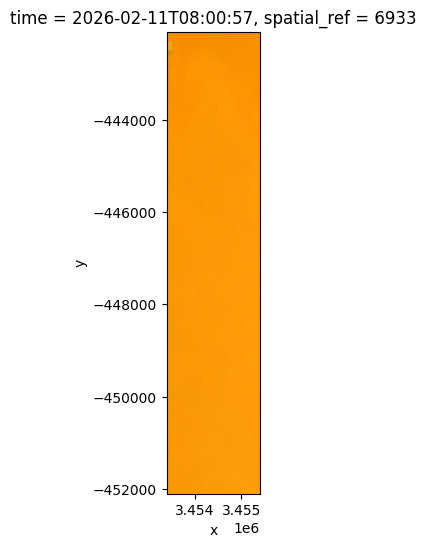

In [191]:
rgb(ds,bands=['msi04','msi03','msi02'],robust=True)

### algorithm 'TC-2' ... NOT supported by geomedian datasets which don't have band1 for MSI :(


In [212]:
# convert remote sensing reflectance tp below water surface reflectance
#depending on other factors, use either 704 or 740 band.
# R704 = ds.msi05 / 10000
R443 = (ds.msi01 / 10000)
R560 = (ds.msi03 / 10000)
R665 = (ds.msi04 / 10000)
R704 = (ds.msi05 / 10000)
R740 = (ds.msi06 / 10000)



In [505]:
#below is as implemented, saved for safety...
#-------------------------------------------------------------------------
# a series of functions to implement the TC2 Chla algorithm for MSI data
def below_water_reflectance(da) :    # (Lui et al 2020)
    # rescale reflectance to a fraction first
    return( (da * 0.0001) / (0.52 + 1.7 * da * 0.0001) )

def mu(da) :     # (Lui et al 2020)
    g0 = -0.089
    g1 =  0.125
    return(
        ( g0 + pow((g0**2 + 4*g1*da),0.5)) / 2*g1
    )

def MCI(R665,R704,R740) : #(gower et al 2005 as in Zhao et al 2024)
    k = (704 - 665)/(740-665)
    return(R704 - R665 - (R740 - R665)*k)

def backscatter_coeffs(L,L0_lambda,L0_part_backscatter,Exponent,clear_water_backscatter) :  # (Lui et al 2020)
    return  (
            L0_part_backscatter * pow(L0_lambda/L,Exponent) + clear_water_backscatter
            )

def non_water_abs(rs_data,
                  backscatter_coefficient,
                  clearwater_absorption_coefficient):  #(Lui et al 2020)
    mL = mu(below_water_reflectance(rs_data))
    return(
        (1 - mL)*backscatter_coefficient / mL - clearwater_absorption_coefficient
        )
def chla_from_nonwater_absorption (anw665,anw560,anw704) :  #(lui et al 2020)
    p_ = 0.17
    aph665 = anw665 - p_ * anw560 - (1 - p_) * anw704
    aChla  = 0.017
    return(aph665 / aChla)
    
def Chla_tc2 (ds,band_443,band_560,band_665,band_704,band_740) :
    # parameters used in the analysis
    p={}
    p['443'] = {'bname': band_443, 'la' : 443, 'bw' : 0.00219, 'aw' : 0.00680, 'aph' : ''}
    p['560'] = {'bname': band_560, 'la' : 560, 'bw' : 0.00081, 'aw' : 0.06215, 'aph' : 0.010}
    p['665'] = {'bname': band_665,'la' : 665, 'bw' : 0.00039, 'aw' : 0.42850, 'aph' : 0.017}
    p['704'] = {'bname': band_704,'la' : 704, 'bw' : 0.00031, 'aw' : 0.71502,}
    p['740'] = {'bname': band_740,'la' : 740, 'bw' : 0.00025, 'aw' : 1.91400,}

    # determine the MCI (gower et al 2005 which is used to choose lambda zero    
    MCI_threshold = 0.0016
    p['MCI'] =  MCI(
        ds[p['665']['bname']]*0.0001,
        ds[p['704']['bname']]*0.0001,
        ds[p['740']['bname']]*0.0001,
        )
    # power-law exponenent for particulate backscatter (pixel-wise)
    Y  = 2.0 * ( 1 - 1.2 * np.exp(-0.9 * \
                  below_water_reflectance(ds[p['443']['bname']]) / 
                  below_water_reflectance(ds[p['560']['bname']])
                                 ))
    
    for option in [704,740]:  #deal with two possibilities regarding the MCI, one turbid water, the other non turbid
        L0 = option
        
        L0m = mu(below_water_reflectance(ds[p[str(L0)]['bname']])
        )
        L0la = p[str(L0)]['la']
        L0aw = p[str(L0)]['aw']
        L0bw = p[str(L0)]['bw']
        # estimate the backscatter from particulates at L0 (pixel-wise)
        L0bp  = (L0m  * L0aw) / (1-L0m) - L0bw
        # calculate backscatter coefficients for each band
        for l in [560,665,704,740] :
            p[str(l)]['backscatter'] = \
                backscatter_coeffs(
                    L = l,
                    L0_lambda = L0la,
                    L0_part_backscatter = L0bp,
                    Exponent = Y,
                    clear_water_backscatter = p[str(l)]['bw'])

        # calculate the non-water absorption for each band
        for l in [560,665,704]:
            l = str(l)
            p[l]['anw'] =  \
                non_water_abs(
                    rs_data                           = ds[p[l]['bname']],
                    backscatter_coefficient           =    p[l]['backscatter'],
                    clearwater_absorption_coefficient =    p[l]['aw'])

        # retreive chla estimates 
        p['chla'+str(option)] = chla_from_nonwater_absorption (
                                anw665= p['665']['anw'],\
                                anw560= p['560']['anw'],\
                                anw704= p['704']['anw']    )

    return(xr.where(p['MCI']<MCI_threshold,p['chla704'],p['chla740']))
# ----------------------------------------------------------        
   

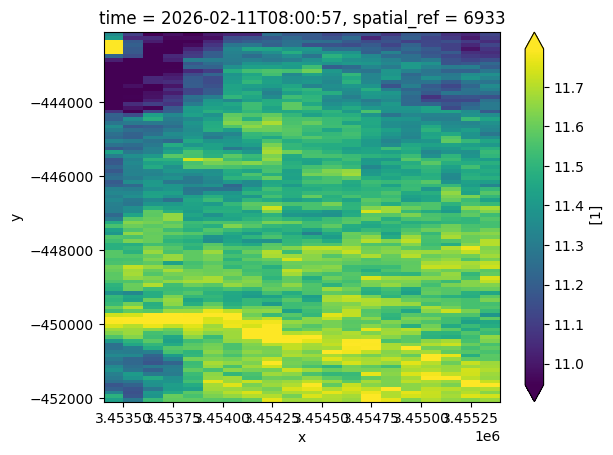

In [507]:
%run /home/jovyan/dev/deafrica_water_quality/WP2.1/_WP21_functions.py                # contains functions to compare pixels to the geomedian
tc2_chla(ds,
        band_443='msi01',
        band_560='msi03',
        band_665='msi04',
        band_704='msi05',
        band_740='msi06',
       ).plot(robust=True)

In [402]:

r443 = R443 / ( 0.52 + 1.7*R443)
r560 = R560 / ( 0.52 + 1.7*R560)
r665 = R665 / ( 0.52 + 1.7*R665)
r704 = R704 / ( 0.52 + 1.7*R704)
r740 = R740 / ( 0.52 + 1.7*R740)

# then solve quadratic ..
g0 = -0.089
g1 =  0.125

m443  = ( g0 + pow((g0**2 + 4*g1*r443),0.5)) / 2*g1

m560  = ( g0 + pow((g0**2 + 4*g1*r560),0.5)) / 2*g1
m665  = ( g0 + pow((g0**2 + 4*g1*r665),0.5)) / 2*g1
m704  = ( g0 + pow((g0**2 + 4*g1*r704),0.5)) / 2*g1
m740  = ( g0 + pow((g0**2 + 4*g1*r740),0.5)) / 2*g1



In [ ]:
# power-law exponenent for particulate backscatter (pixel-wise)
Y  = 2.0 * ( 1 - 1.2 * np.exp(-0.9 * r443 / r560))
Y.plot(robust=True)
plt.show()
Y  = 2.0 * ( 1 - 1.2 * np.exp(-0.9 * below_water_reflectance(ds[p['443']['bname']]) / 
                                     below_water_reflectance(ds[p['560']['bname']])))
Y.plot(robust=True)


Text(0.5, 1.0, 'Lambda-0 m, L0la = 740 L0aw = 1.914 L0bw = 0.00025')

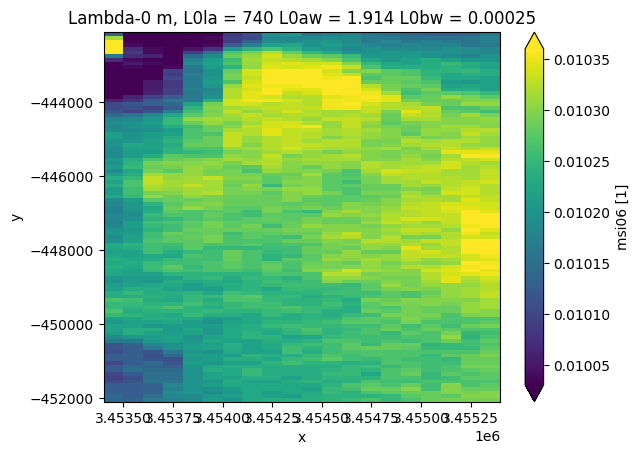

In [403]:
# in turbid waters use 740 as the base
L0m = m704
L0  = 704

L0  = 740
L0m = m740
L0m = mu(
        below_water_reflectance(ds[p[str(L0)]['bname']])
        )
L0la = p[str(L0)]['la']
L0aw = p[str(L0)]['aw']
L0bw = p[str(L0)]['bw']
L0m.plot(robust=True)
plt.title(f'Lambda-0 m, L0la = {L0la} L0aw = {L0aw} L0bw = {L0bw}')

In [404]:
# estimate the bacscatter from particulates at L0 (pixel-wise)
L0bp  = (L0m  * L0aw) / (1-L0m) - L0bw

In [427]:

#coefficients of total backscattering  (pixel-wise)
b560  = L0bp * pow(L0la/p['560']['la'],Y)  + p['560']['bw']
b665  = L0bp * pow(L0la/p['665']['la'],Y) + p['665']['bw']
b704  = L0bp * pow(L0la/p['704']['la'],Y) + p['704']['bw']
b740  = L0bp * pow(L0la/p['740']['la'],Y) + p['740']['bw']

def backscatter_coeffs(L,L0_lambda,L0_part_backscatter,Exponent,clear_water_backscatter) :  # (Lui et al 2020)
    return(
        L0_part_backscatter * pow(L0_lambda/L,Exponent) + clear_water_backscatter
    )

for l in [560,665,704,740] :
    p[str(l)]['backscatter'] = backscatter_coeffs(l,L0la,L0bp,Y,p[str(l)]['bw'])

In [ ]:
pow(L0la/p['704']['la'],Y) + p['704']['bw']

In [ ]:
b665.plot()
plt.show()
p['665']['backscatter'].plot()

In [ ]:
((((1-m704)*b704)/b704)-p['704']['aw']).plot()

In [428]:
# non-water absoption

anw704 = (1 - m704)*b704 / m704 - p['704']['aw']
anw560 = (1 - m560)*b560 / m560 - p['560']['aw']
anw665 = (1 - m665)*b665 / m665 - p['665']['aw']


def non_water_abs(rs_data,
                  backscatter_coefficient,
                  clearwater_absorption_coefficient):  #(Lui et al 2020)
    mL = mu(below_water_reflectance(rs_data))
    return(
    (1 - mL)*backscatter_coefficient / mL - clearwater_absorption_coefficient
        #(1 - mL)*backscatter_coefficient / mL - clearwater_absorption_coefficient
    )

L = '560'
anw560= non_water_abs(
    rs_data                           = ds[p[L]['bname']],
    backscatter_coefficient           =    p[L]['backscatter'],
    clearwater_absorption_coefficient =    p[L]['aw'])
L = '704'
anw704= non_water_abs(
    rs_data                           = ds[p[L]['bname']],
    backscatter_coefficient           =    p[L]['backscatter'],
    clearwater_absorption_coefficient =    p[L]['aw'])

for L in [560,665,704]:
    L = str(L)
    p[L]['anw'] =  \
        non_water_abs(
            rs_data                           = ds[p[L]['bname']],
            backscatter_coefficient           =    p[L]['backscatter'],
            clearwater_absorption_coefficient =    p[L]['aw'])


In [ ]:
for L in [560,665,704]:
    L = str(L)
    p[L]['anw'] =  \
        non_water_abs(
            rs_data                           = ds[p[L]['bname']],
            backscatter_coefficient           =    p[L]['backscatter'],
            clearwater_absorption_coefficient =    p[L]['aw'])

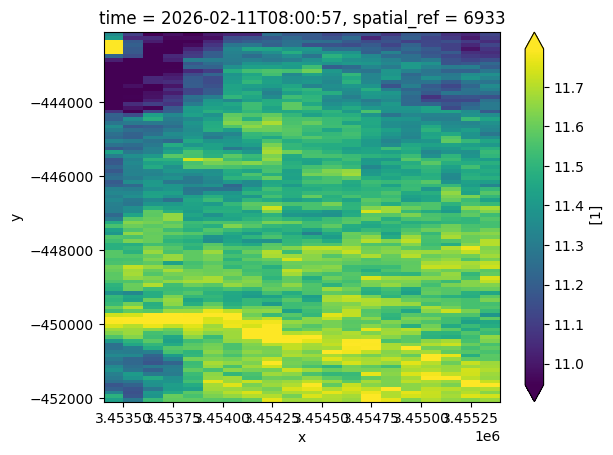

In [432]:
def chla_from_nonwater_absorption (anw665,anw560,anw704) :  #(lui et al 2020)
    p_ = 0.17
    aph665 = anw665 - p_ * anw560 - (1 - p_) * anw704
    aChla  = 0.017
    return(aph665 / aChla)
chla_from_nonwater_absorption (
    anw665= p['665']['anw'],\
    anw560= p['560']['anw'],\
    anw704= p['704']['anw'],
    ).plot(robust=True)

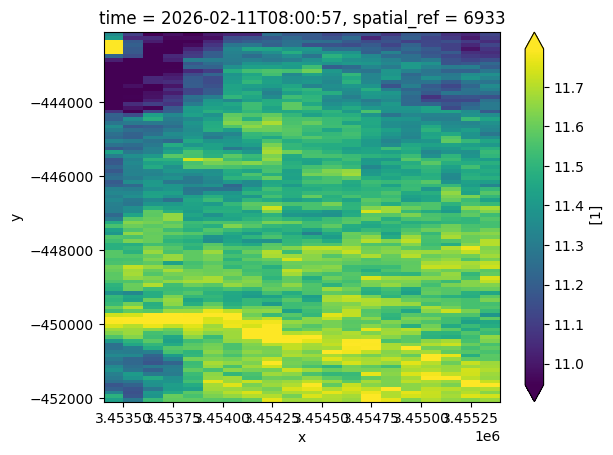

In [422]:
# specific absorption coefficient
p_ = 0.17
aph665 = anw665 - p_ * anw560 - (1 - p_) * anw704
aph665 = p['665']['anw'] - p_ * p['560']['anw'] - (1 - p_) * p['704']['anw']
aChla  = 0.017
chla   = aph665 / aChla
chla.plot(robust=True)

In [178]:
print('R: ',R560,R665,R704,R740)
print('r: ',r560,r665,r704,r740)
print('m: ',m560,m665,m704,m740)
print('b: ',b560,b665,b704,b740)
print('bpl0: ',bpL0)
print('Y: ',Y)
print('m: ',b560,b665,b704,b740)
print('anw: ',anw560,anw665,anw704)
print('aph: ',aph665)
print('Chla: ',chla)

R:  <xarray.DataArray 'msi03' (y: 701, x: 194)> Size: 1MB
array([[0.0539, 0.0523, 0.0539, ..., 0.1314, 0.13  , 0.1383],
       [0.056 , 0.0539, 0.059 , ..., 0.1281, 0.1335, 0.1338],
       [0.0531, 0.0549, 0.0628, ..., 0.13  , 0.1366, 0.1332],
       ...,
       [0.0142, 0.0104, 0.0721, ..., 0.0414, 0.0838, 0.0889],
       [0.0189, 0.0717, 0.0783, ..., 0.0446, 0.0861, 0.0868],
       [0.0119, 0.0739, 0.0801, ..., 0.0725, 0.0835, 0.0774]],
      shape=(701, 194))
Coordinates:
  * y            (y) float64 6kB -4.272e+05 -4.272e+05 ... -4.97e+05 -4.972e+05
  * x            (x) float64 2kB 3.446e+06 3.447e+06 ... 3.466e+06 3.466e+06
    time         datetime64[ns] 8B 2026-02-11T08:00:57
    spatial_ref  int32 4B 6933
Attributes:
    units:         1
    nodata:        0
    crs:           EPSG:6933
    grid_mapping:  spatial_ref <xarray.DataArray 'msi04' (y: 701, x: 194)> Size: 1MB
array([[0.0899, 0.0894, 0.0838, ..., 0.176 , 0.1735, 0.1755],
       [0.0873, 0.0859, 0.0796, ..., 0.1712, 0.

NameError: name 'bpL0' is not defined

### using the ks test with a reconstructed dataset (from quantiles and n).?

In [ ]:
dist_centres = (dist[0:len(dist)-1] + dist[1:len(dist)] ) / 2

delta = 1
dist = np.array([0,1,2,3,4,5]) # values along the 
n = 10 #observations per quantile
syn = (np.ones((dist_centres.size,n)).T*(dist_centres))
syn

ds.tss.clip(0,500).mean()

# this needs work to properly reconstruct the distribution
# saving the quantiles as a tricky way to use the ks test without keeping all the data
# with the cdf and n we can sythesize data to use in the test.
delta  = 0.01
Q = np.arange(0,1+delta,delta)
N=ds.tss_h.count().values
n= int(delta*N)
dist=ds.tss_h.clip(0,1000).quantile(Q,).values
syn = np.ones((dist.size,n)).T*(dist)
#check that the resconstruction is okay
print(
    syn.mean(),
    dist.mean(),
    ds.tss_h.clip(0,1000).mean().values
)
import scipy as sp
a = syn.reshape(syn.size)
b = ds.tss_h.data.reshape(ds.tss_h.size).clip(0,1000)

c = b[~np.isnan(b)]  #nonans works
b = b - 1

print(
    sp.stats.kstest(
        a,
        c,
        nan_policy = 'omit')[1],
    )

plt.plot(np.quantile(syn-1,Q),marker='x')
plt.plot((ds.tss_h.clip(0,1000)).quantile(Q))

### weight objects

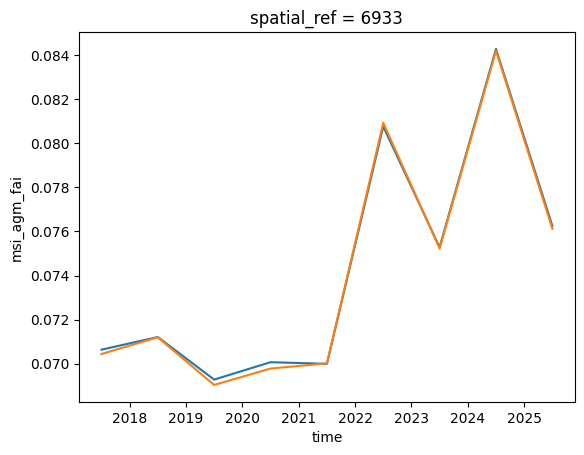

In [120]:
ds_annual_weighted = ds_annual.msi_agm_fai.weighted(ds_annual.msi_agm_count / (ds_annual.msi_agm_count + ds_annual.oli_agm_count)  )
ds_annual_weighted.mean(dim=('x','y')).plot()
ds_annual.msi_agm_fai.mean(dim=('x','y')).plot()


In [76]:
anw704 = (1 - m704)*b704 / m704 - aw704
print((((1 - m704) * b704) / m704))

0.7152


In [130]:
#this analysis is indicative only; the maksing of high FAI values is not included.

scratch_directory = '/home/jovyan/AdamsWork/scratch/'

#ds = read_dataset(scratch_directory+'wp21_ds_Haartbeesport_dam.nc')
ds = read_dataset(scratch_directory+'wp21_ds_Lake_Manyara.nc')

ds = apply_R_correction(ds,['msi','oli','tm'],ds.wofs_ann_freq > 0.5,drop=True,test=False)

# --- dictionaries for the non-geomedian instruments and products ...
instruments_to_use = {
    'oli_agm'  : {'use': False },
    'oli'      : {'use': True},
    'msi_agm'  : {'use': False },
    'msi'      : {'use': True},
    'tm_agm'   : {'use': False },
    'tm'       : {'use': True},
    'tirs'     : {'use': True},  
    'wofs_ann' : {'use': False },
    'wofs_all' : {'use': False },  # wofs_all will be removed as it is better to derive from wofs_ann
    }
instruments_to_use = check_instrument_dates(instruments_to_use,
                                            ds.time[0].dt.year,
                                            ds.time[1].dt.year,
                                            False)
instruments,measurements,rename_dict = instruments_list(instruments_to_use) 

# for the non-geomedian datasets, the build function wants to know the products ... 
products = { 
                'tm_agm'  :["gm_ls5_ls7_annual"],
                'tm'      :["ls5_sr","ls7_sr"],
                'oli_agm' :["gm_ls8_annual","gm_ls8_ls9_annual"],
                'oli'     :["ls8_sr","ls9_sr"],
                'msi_agm' :["gm_s2_annual"],
                'msi'     :["s2_l2a"],
                'tirs'    :["ls5_st","ls7_st","ls8_st","ls9_st"],
                'wofs_ann':["wofs_ls_summary_annual"],
                'wofs_all':["wofs_ls_summary_alltime"],
               }

instruments,measurements,rename_dict = instruments_list(instruments_to_use) 


algorithms_chla,algorithms_tsm = set_wq_algorithms(suffix='')

#calculate the chla variables
ds,chla_vlist = WQ_vars(ds.where(ds.wofs_ann_freq > 0.8),
                        algorithms_chla, 
                        instruments, 
                        new_dimension_name=None, 
                        new_varname=None,
                        verbose=True)

ds['chla'] = ds[chla_vlist].to_array(dim = 'chla_measure')

ChlA_MODIS two-band model


In [131]:
ds

<xarray.Dataset> Size: 720MB
Dimensions:            (time: 30, y: 430, x: 166, chla_measure: 7)
Coordinates:
  * time               (time) datetime64[ns] 240B 2015-12-06T07:50:46.715176 ...
  * y                  (y) float64 3kB -4.862e+05 -4.861e+05 ... -4.347e+05
  * x                  (x) float64 1kB 3.447e+06 3.447e+06 ... 3.467e+06
  * chla_measure       (chla_measure) object 56B 'ndci_tm43' ... 'chla_modis2...
    spatial_ref        int32 4B 6933
Data variables: (12/38)
    oli05              (time, y, x) float64 17MB nan nan nan nan ... nan nan nan
    oli06              (time, y, x) float64 17MB nan nan nan nan ... nan nan nan
    oli07              (time, y, x) float64 17MB nan nan nan nan ... nan nan nan
    oli_pq             (time, y, x) float64 17MB nan nan nan nan ... nan nan nan
    qa_ralb            (time, y, x) float64 17MB nan nan nan nan ... nan nan nan
    qa_alb             (time, y, x) float64 17MB nan nan nan nan ... nan nan nan
    ...                 ...
    chla_3bda_oli      (y, x, time) float64 17MB nan nan nan nan ... nan nan nan
    chla_3bda_tm       (y, x, time) float64 17MB nan nan nan nan ... nan nan nan
    chla_tebbs_oli     (time, y, x) float64 17MB nan nan nan nan ... nan nan nan
    chla_tebbs_tm      (y, x, time) float64 17MB nan nan nan nan ... nan nan nan
    chla_modis2b_tm    (y, x, time) float64 17MB nan nan nan nan ... nan nan nan
    chla               (chla_measure, y, x, time) float64 120MB nan nan ... nan
Attributes:
    crs:           epsg:6933
    grid_mapping:  spatial_ref

In [ ]:
mmt='chla'
vartype = mmt+'_measure'
varname = ds[vartype].values[0]
ds[mmt].loc[{vartype :[varname]}]

In [132]:
ds['chla_h'] = ds['chla'].copy()

In [133]:
np_parameters_filename = 'normalisation_parameters.csv'
lookup        = pd.read_csv(data_directory+lookup_table_filename)
distributions = pd.read_csv(data_directory+'measurement_distributions.csv')
np_data       = pd.read_csv(data_directory+np_parameters_filename)


# Instrument to instrument harmonisation
for mmt in ['chla']:
            ds[mmt+'_h'] = ds[mmt].copy()
            vartype = mmt+'_measure'
            for varname in list(ds[vartype].values):
                ds[mmt+'_h'].loc[{vartype :[varname]}]= \
                    harmonise_for_instrument(
                        ds[mmt].loc[{vartype :[varname]}],
                        varname,
                        lookup,
                        distributions,
                        test=False)


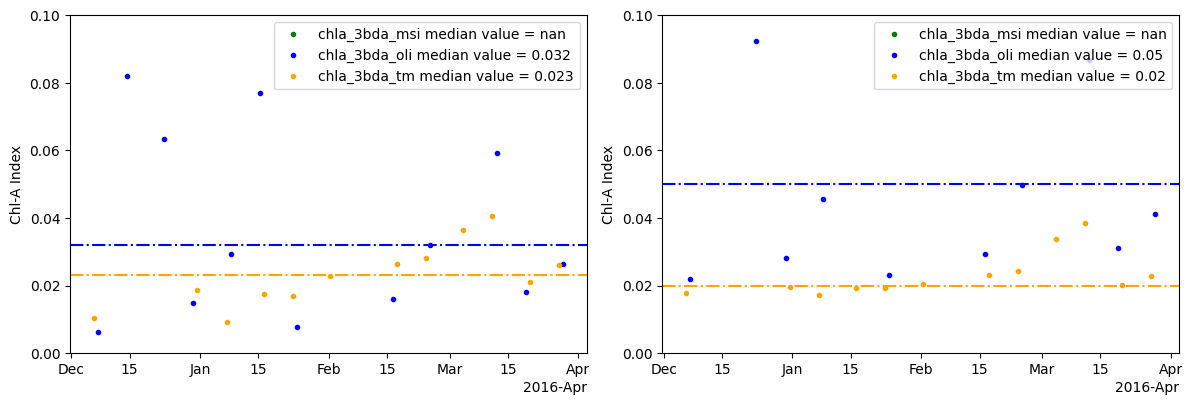

In [134]:
placename  = 'Lake Manyara'
# a plot to illustrate the instrument harmonisation process, I hope

fig, axes = plt.subplots(1,2,sharex=False, sharey=False, layout="constrained")    
cm = 1/2.54
fig.set_size_inches(30*cm,10*cm)

l1 =  [['Chl-A Index',-.75,1],'ndci_msi54', 'ndci_msi64','ndci_msi74', 'ndci_tm43', 'ndci_oli54']
l1 =  [['Chl-A Index',-.75,1],'ndci_msi74', 'ndci_tm43', 'ndci_oli54']
l3 =  [['Chl-A Index',0,0.1], 'chla_3bda_msi', 'chla_3bda_oli', 'chla_3bda_tm']
l4 =  [['Chl-A mg/m3',0,500],'chla_toming_msi','chla_tebbs_msi', 'chla_tebbs_oli','chla_tebbs_tm'] 
l2 =  [['Chl-A mg/m3',0,200],'chla_gurlin2b_msi', 'chla_meris2b_msi', 'chla_modis2b_msi', 'chla_modis2b_tm']
l2 =  [['Chl-A mg/m3',0,200], 'chla_modis2b_msi', 'chla_modis2b_tm']

i = 0
colours = ('b','orange','g')
for var in ['chla','chla_h']:
    l = l3
    axis = axes[i];     i = i + 1
    
    for m in l[1:]:
        j = l[1:].index(m)-1
        colour = colours[j]
        params = l[0]
        median_value = \
            ds[var].\
            where(ds.wofs_ann_freq > 0.9).\
            loc[ds.chla_measure==m].\
            median(dim='chla_measure').\
            median(dim=('x','y')).\
            median(dim=('time')).round(3).item()
        label_string = m+' median value = '+str(median_value)
        ds[var].\
            where(ds.wofs_ann_freq > 0.9).\
            loc[ds.chla_measure==m].\
            median(dim='chla_measure').\
            median(dim=('x','y')).\
            plot(linestyle='',marker='.',c=colour,label =label_string,ax=axis)
        axis.axhline(median_value, 
                     linestyle='-.',
                     marker='',
                     c=colour,
                     #label =str(median_value),
                     )

    #axis.set_yscale()
    axis.set_ylim(params[1],params[2])
    axis.set_xlabel('')
    axis.set_ylabel(params[0])
    axis.set_title(placename+' Chla values '+var)
    axis.set_title('')
    axis.legend(loc='best')
    axis.legend(loc='upper right')
plt.savefig(fname = scratch_directory+'harmonisation for instrument.pdf',
                transparent=True, 
                dpi='figure', 
                format='pdf',
                metadata=None, bbox_inches=None, pad_inches=0.1,
                facecolor='auto', edgecolor='auto', backend=None
               )
plt.show()
    # repeat for normalised data

In [114]:
lookup

,Unnamed: 0,target,reference
0,0,ndci_msi54,ndci_msi74
1,1,ndci_msi64,ndci_msi74
2,2,ndci_msi74,ndci_msi74
3,3,ndci_tm43,ndci_msi74
4,4,ndci_oli54,ndci_msi74
5,5,chla_gurlin2b_msi,chla_gurlin2b_msi
6,6,chla_toming_msi,chla_toming_msi
7,7,chla_3bda_msi,chla_3bda_msi
8,8,chla_3bda_oli,chla_3bda_msi
9,9,chla_3bda_tm,chla_3bda_msi


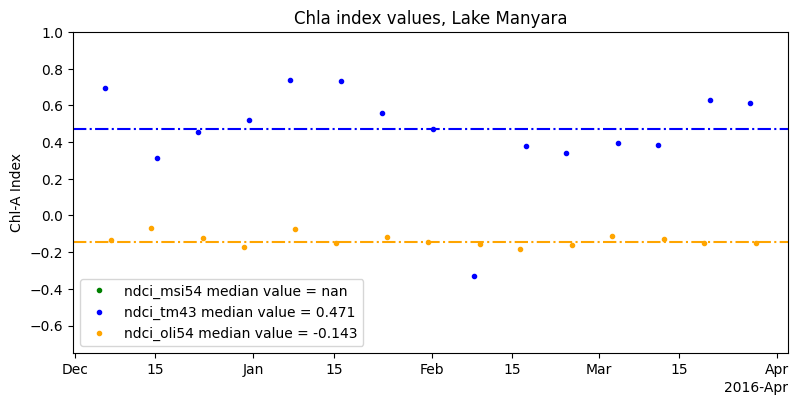

In [135]:
fig, axes = plt.subplots(1,1,sharex=False, sharey=False, layout="constrained")    
cm = 1/2.54
fig.set_size_inches(20*cm,10*cm)

l1 =  [['Chl-A Index',-.75,1],'ndci_msi54', 'ndci_msi64','ndci_msi74', 'ndci_tm43', 'ndci_oli54']
l1 =  [['Chl-A Index',-.75,1],'ndci_msi54', 'ndci_tm43', 'ndci_oli54']
l3 =  [['Chl-A Index',0,0.1], 'chla_3bda_msi', 'chla_3bda_oli', 'chla_3bda_tm']
l4 =  [['Chl-A mg/m3',0,500],'chla_toming_msi','chla_tebbs_msi', 'chla_tebbs_oli','chla_tebbs_tm'] 
l2 =  [['Chl-A mg/m3',0,200],'chla_gurlin2b_msi', 'chla_meris2b_msi', 'chla_modis2b_msi', 'chla_modis2b_tm']

colours = ('b','orange','g')
if True:
    l = l1
    axis = axes 
    for m in l[1:]:
        i = l[1:].index(m)-1
        colour = colours[i]
        params = l[0]
        median_value = \
                ds.chla_h.\
            where(ds.wofs_ann_freq > 0.9).\
            loc[ds.chla_measure==m].\
            median(dim='chla_measure').\
            median(dim=('x','y')).\
            median(dim=('time')).round(3).item()
        label_string = m+' median value = '+str(median_value)
        ds.chla_h.\
            where(ds.wofs_ann_freq > 0.9).\
            loc[ds.chla_measure==m].\
            median(dim='chla_measure').\
            median(dim=('x','y')).\
            plot(linestyle='',marker='.',c=colour,label =label_string,ax=axis)
        axis.axhline(median_value, 
                     linestyle='-.',
                     marker='',
                     c=colour,
                     #label =str(median_value),
                     )

    #axis.set_yscale()
    axis.set_ylim(params[1],params[2])
    axis.set_xlabel('')
    axis.set_ylabel(params[0])
    axis.set_title('Chla index values, '+placename)
    axis.legend(loc='best')
    axis.legend()
    plt.savefig(fname = scratch_directory+'testfig.pdf',
                transparent=True, 
                dpi='figure', 
                format='pdf',
                metadata=None, bbox_inches=None, pad_inches=0.1,
                facecolor='auto', edgecolor='auto', backend=None
               )
    plt.show()

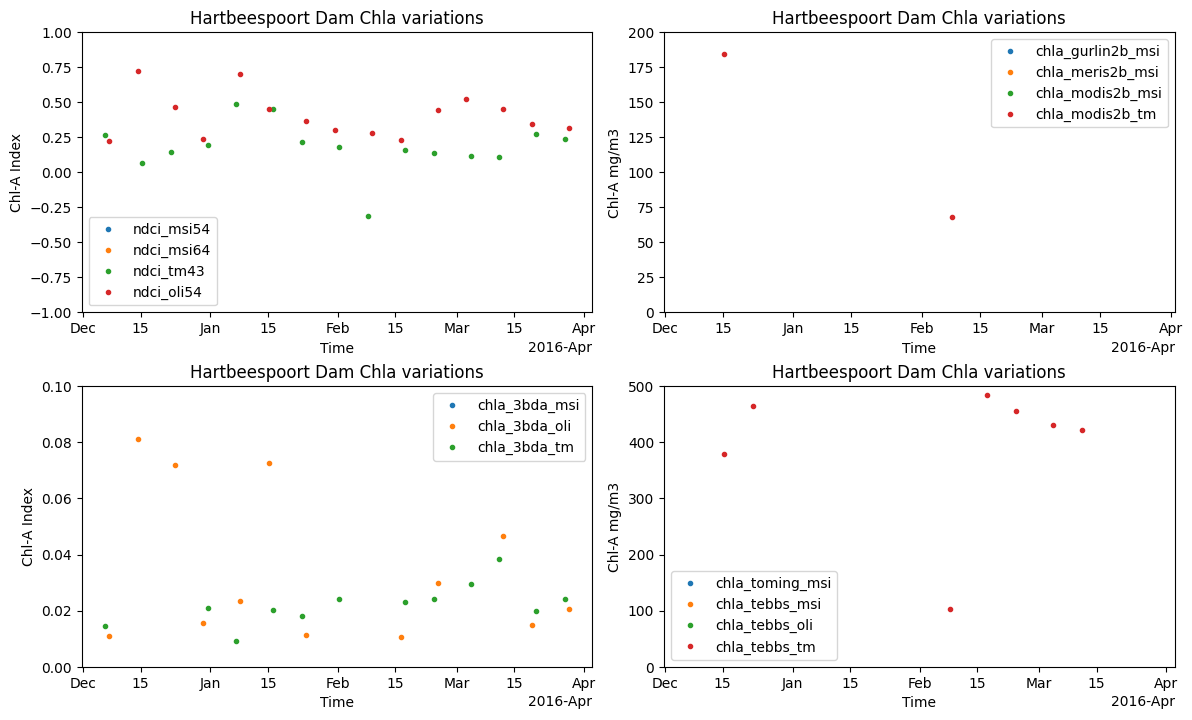

In [136]:

fig, axes = plt.subplots(2,2,sharex=False, sharey=False, layout="constrained")    
cm = 1/2.54
fig.set_size_inches(30*cm,18*cm)

l1 =  [['Chl-A Index',-1,1],'ndci_msi54', 'ndci_msi64', 'ndci_tm43', 'ndci_oli54']
l3 =  [['Chl-A Index',0,0.1], 'chla_3bda_msi', 'chla_3bda_oli', 'chla_3bda_tm']
l4 =  [['Chl-A mg/m3',0,500],'chla_toming_msi','chla_tebbs_msi', 'chla_tebbs_oli','chla_tebbs_tm'] 
l2 =  [['Chl-A mg/m3',0,200],'chla_gurlin2b_msi', 'chla_meris2b_msi', 'chla_modis2b_msi', 'chla_modis2b_tm']

x = y = 0

for l in list([l1,l2,l3,l4]):
        
    axis  = axes[y,x]
    for m in l[1:]:
        params = l[0]
        ds.chla.\
            where(ds.wofs_ann_freq > 0.5).\
            loc[ds.chla_measure==m].\
            median(dim='chla_measure').\
            median(dim=('x','y')).\
            plot(linestyle='',marker='.',label =m,ax=axis)
            
    #axis.set_yscale()
    axis.set_ylim(params[1],params[2])
    axis.set_xlabel('Time')
    axis.set_ylabel(params[0])
    axis.set_title('Hartbeespoort Dam Chla variations')
    axis.legend(loc='best')
    axis.legend()
    y = y + 1 * x
    y = y%2
    x = x + 1 
    x = min(x,x%2)

    


In [26]:
ds.chla_measure

<xarray.DataArray 'chla_measure' (chla_measure: 16)> Size: 128B
array(['ndci_msi54', 'ndci_msi64', 'ndci_msi74', 'ndci_tm43', 'ndci_oli54',
       'chla_toming_msi', 'chla_gurlin2b_msi', 'chla_3bda_msi',
       'chla_3bda_oli', 'chla_3bda_tm', 'chla_tebbs_msi', 'chla_tebbs_oli',
       'chla_tebbs_tm', 'chla_meris2b_msi', 'chla_modis2b_msi',
       'chla_modis2b_tm'], dtype=object)
Coordinates:
  * chla_measure  (chla_measure) object 128B 'ndci_msi54' ... 'chla_modis2b_tm'
    spatial_ref   int32 4B 6933

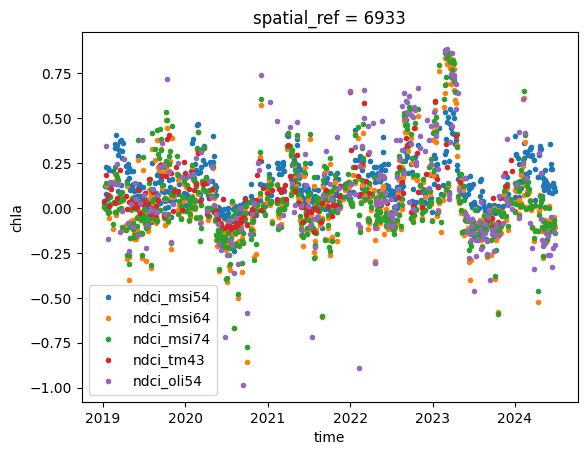

In [28]:
l1 = ['ndci_msi54', 'ndci_msi64', 'ndci_msi74', 'ndci_tm43', 'ndci_oli54']
l3 =  ['chla_gurlin2b_msi', 'chla_3bda_msi', 'chla_3bda_oli', 'chla_3bda_tm']
l4 =  ['chla_tebbs_msi', 'chla_tebbs_oli','chla_tebbs_tm'] 
l2 =  ['chla_toming_msi', 'chla_meris2b_msi', 'chla_modis2b_msi', 'chla_modis2b_tm']
for m in l1:
    ds.chla.\
        loc[ds.chla_measure==m].\
        median(dim='chla_measure').\
        median(dim=('x','y')).plot(linestyle='',marker='.',label =m)
plt.legend()
plt.show()


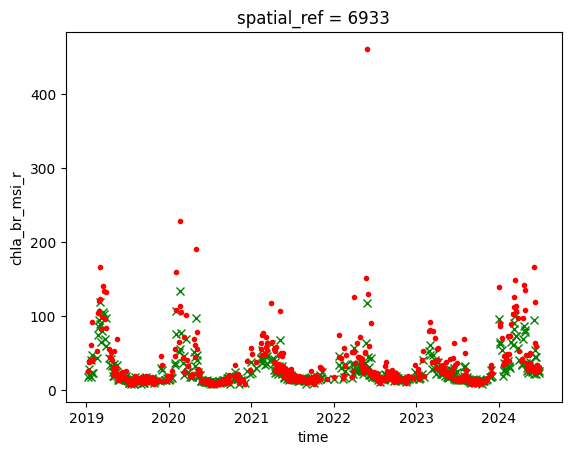

In [36]:

# ------------------------------------------------------------------------
def ChlA_2B(dataset, band_704, band_665, verbose=False):
    # Gurlin et al., 2011
    # as described in Desong Zhao et al, 2024
    a2 = 40.985
    a1 = -46.558
    a0 = 19.246
    R  = (ds[band_704] / ds[band_665])
    return  ( a2*R**2 + a1*R + a0 )



ds['chla_br_msi'  ] = ChlA_2B(ds,'msi05','msi04').where(ds.ndvi<=0)
ds['chla_br_msi_r'] = ChlA_2B(ds,'msi05r','msi04r').where(ds.ndvi<=0)

ds.chla_br_msi.median(dim=('x','y')).plot(linestyle='',marker='x',c='g')
ds.chla_br_msi_r.median(dim=('x','y')).plot(linestyle='',marker='.',c='r')

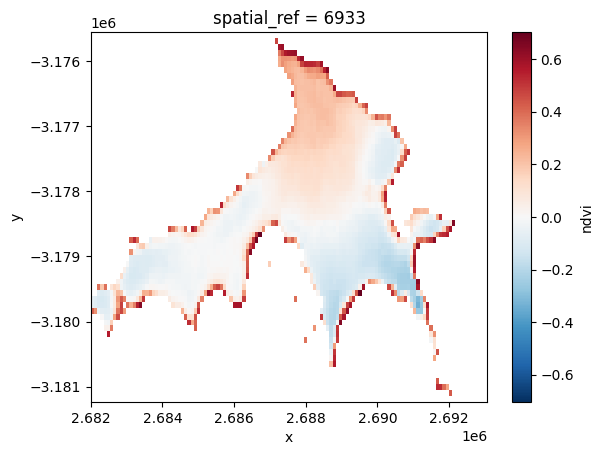

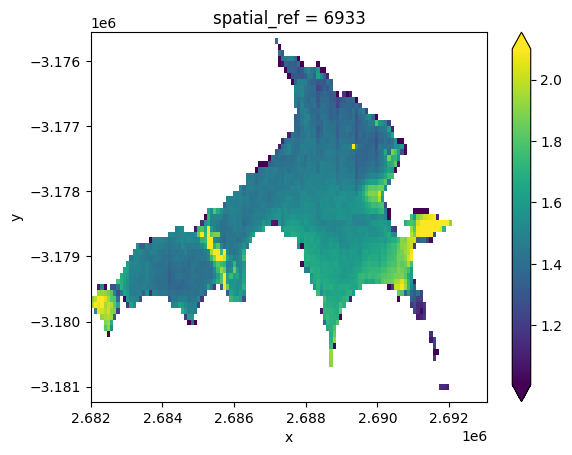

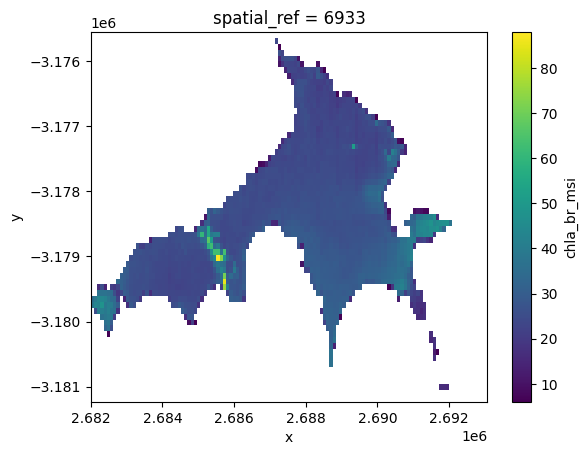

In [21]:
ds.ndvi.mean(dim='time').plot()
plt.show()
(R**2).mean(dim='time').plot(robust=True)
plt.show()
ds.chla_br_msi.mean(dim='time').plot()
plt.show()

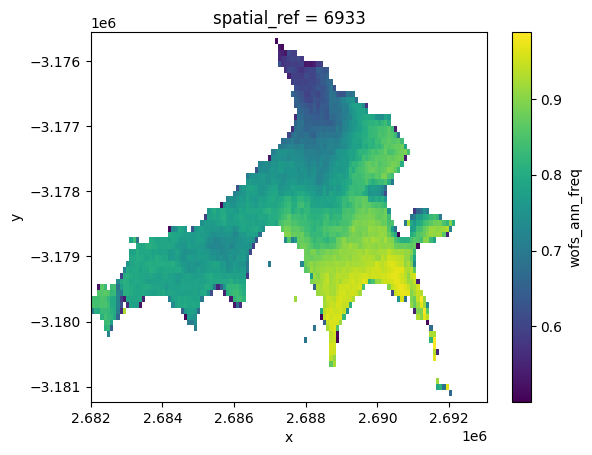

In [7]:
ds.wofs_ann_freq.mean(dim='time').plot()

## sampling a dataset with points

In [561]:
# create some point data at random points:
sample_sites = pd.DataFrame(columns=['x','y'],data=None)
dx = (ds.x.max() - ds.x.min()).values
dy = (ds.y.max() - ds.y.min()).values
n = 40
data_x = np.random.rand(n) * dx + ds.x.min().values
data_y = np.random.rand(n) * dy + ds.y.min().values


In [562]:
# engineer the xy coords to a data frame WITH AN INDEX for the coordinate pairs:
#    I can't see the simple way of doing this, so going into pandas and out again!
sample_sites['x'] = data_x
sample_sites['y'] = data_y

In [563]:
# sample the dataset at the points, converting the pandas coordinates to xarray first to keep the index 
samples = ds['wofs_ann_freq'].median(dim='time').sel(
    x=sample_sites['x'].to_xarray(),
    y=sample_sites['y'].to_xarray(),
    method='nearest')

In [ ]:
# take back into a data frame to have a single list of samples with the index
samples = pd.DataFrame(samples)

# use the index to join this back to the xy data:
pd.merge(xydata,samples,left_index=True,right_index=True)

In [565]:
# get the long-lat coords and generate random points from these
xyt = set_spacetime_domain('Haartbeesport_dam')[0]
x = xyt['x']
y = xyt['y']

sample_sites = pd.DataFrame(columns=['x','y'],data=None)
dx = (x[1] - x[0])
dy = (y[1] - y[0])
n = 40
sample_sites['x'] = (np.random.rand(n) * dx + x[0])
sample_sites['y'] = (np.random.rand(n) * dy + y[0])
sample_sites['stuff'] = '----'


In [ ]:
# convert to a geopandas frame with crs and project to the dataset projection ...

sample_points = gpd.points_from_xy(sample_sites.x,sample_sites.y)
sample_points  = gpd.GeoDataFrame(sample_sites, crs = 'epsg:4326',geometry = sample_points)

geopoints = sample_points.to_crs(ds.crs)

In [610]:
# extract the geometry coordinates as array values
x_coords = geopoints.geometry.x.to_xarray()
y_coords = geopoints.geometry.y.to_xarray()

In [671]:
# sample the dataset at the coordinate points, extract the variable of interest, save as a series and merge with original points...
pd.merge(sample_sites,
        (ds.sel(x=x_coords,y=y_coords,method='nearest').median(dim='time')).wofs_ann_freq.to_series(),
         left_index=True,
         right_index=True).tail()


,x,y,stuff,wofs_ann_freq
35,27.881282,-25.764267,----,NaN
36,27.884770,-25.761576,----,0.947999
37,27.894305,-25.745826,----,NaN
38,27.826766,-25.762700,----,0.779486
39,27.836483,-25.773675,----,NaN


In [692]:
waf = ds.wofs_ann_freq

In [695]:
ds.sel(time=slice(t0,t1),x=slice(x-xdelta,x+xdelta)

<xarray.Dataset> Size: 12MB
Dimensions:            (time: 7, y: 63, x: 123)
Coordinates:
  * time               (time) datetime64[ns] 56B 2021-08-24T08:17:23 ... 2021...
  * y                  (y) float64 504B -3.181e+06 -3.181e+06 ... -3.176e+06
  * x                  (x) float64 984B 2.682e+06 2.682e+06 ... 2.693e+06
    spatial_ref        int32 4B 6933
Data variables: (12/35)
    oli01              (time, y, x) float64 434kB nan nan nan ... nan nan nan
    oli02              (time, y, x) float64 434kB nan nan nan ... nan nan nan
    oli03              (time, y, x) float64 434kB nan nan nan ... nan nan nan
    oli04              (time, y, x) float64 434kB nan nan nan ... nan nan nan
    oli05              (time, y, x) float64 434kB nan nan nan ... nan nan nan
    oli06              (time, y, x) float64 434kB nan nan nan ... nan nan nan
    ...                 ...
    wofs_ann_freq      (y, x, time) float32 217kB nan nan nan ... nan nan nan
    coveragepercent    (time) float64 56B 100.0 100.0 100.0 ... 100.0 100.0
    qapasspercent      (time) float64 56B 44.0 99.0 67.0 95.0 96.0 96.0 99.0
    water_pixel_count  (time) float64 56B 2.139e+03 2.139e+03 ... 2.139e+03
    ndvi               (time, y, x) float64 434kB nan nan nan ... nan nan nan
    ndvi_total_count   (time) float64 56B 962.0 2.139e+03 ... 2.139e+03
Attributes:
    crs:           epsg:6933
    grid_mapping:  spatial_ref

### refinement to select from a space-time range around the point ...

### a single nearest point ...

In [702]:
#if there is just one point selectd in a dimensino, then that dimenson disappears

x,y = geopoints.geometry.x[36],geopoints.geometry.y[36]   # in the water
t = ds.time[500]
ds.sel(x=x,
       y=y,
       time=t,
       method='nearest').\
    wofs_ann_freq


<xarray.DataArray 'wofs_ann_freq' ()> Size: 4B
array(0.947999, dtype=float32)
Coordinates:
    time         datetime64[ns] 8B 2021-08-29T08:17:26
    y            float64 8B -3.18e+06
    x            float64 8B 2.691e+06
    spatial_ref  int32 4B 6933

### points within a distance using 'slice' ...

In [ ]:
# create a time delta 
t = ds.time[501]
a_week = pd.Timedelta(value = 1,unit='W')

t0 = t - a_week
t1 = t + a_week

x = geopoints.geometry.x[36]
y = geopoints.geometry.y[36]
xdelta = 100 # metres
ydelta = xdelta

# x and y deltas are simpler!
x0 = x - xdelta
x1 = x + xdelta
y0 = y - ydelta
y1 = y + ydelta
    

# slice out the data
x,y = geopoints.geometry.x[36],geopoints.geometry.y[36]   # in the water
t = ds.time[500]
ds.sel(x=slice(x0,x1),
       y=slice(y0,y1),
       time=slice(t0,t1)
      ).\
    wofs_ann_freq.\
    median(dim=('time','x','y'))


In [723]:
# can do this with loc using a boolean array as the index:
times = (ds.time >= t0) & (ds.time <= t1)
xrange = (ds.x >= x0) & (ds.x <= x1)
yrange = (ds.y >= y0) & (ds.y <= y1)
ds.loc[{
    'time': times,
    'x'   : xrange,
    'y'   : yrange,
    }]

<xarray.Dataset> Size: 10kB
Dimensions:            (time: 7, y: 2, x: 3)
Coordinates:
  * time               (time) datetime64[ns] 56B 2021-08-24T08:17:23 ... 2021...
  * y                  (y) float64 16B -3.18e+06 -3.179e+06
  * x                  (x) float64 24B 2.69e+06 2.691e+06 2.691e+06
    spatial_ref        int32 4B 6933
Data variables: (12/35)
    oli01              (time, y, x) float64 336B nan nan nan nan ... nan nan nan
    oli02              (time, y, x) float64 336B nan nan nan nan ... nan nan nan
    oli03              (time, y, x) float64 336B nan nan nan nan ... nan nan nan
    oli04              (time, y, x) float64 336B nan nan nan nan ... nan nan nan
    oli05              (time, y, x) float64 336B nan nan nan nan ... nan nan nan
    oli06              (time, y, x) float64 336B nan nan nan nan ... nan nan nan
    ...                 ...
    wofs_ann_freq      (y, x, time) float32 168B 0.605 0.605 ... 0.9704 0.9704
    coveragepercent    (time) float64 56B 100.0 100.0 100.0 ... 100.0 100.0
    qapasspercent      (time) float64 56B 44.0 99.0 67.0 95.0 96.0 96.0 99.0
    water_pixel_count  (time) float64 56B 2.139e+03 2.139e+03 ... 2.139e+03
    ndvi               (time, y, x) float64 336B nan nan nan ... -0.1803 -0.2262
    ndvi_total_count   (time) float64 56B 962.0 2.139e+03 ... 2.139e+03
Attributes:
    crs:           epsg:6933
    grid_mapping:  spatial_ref

### illustrative plots

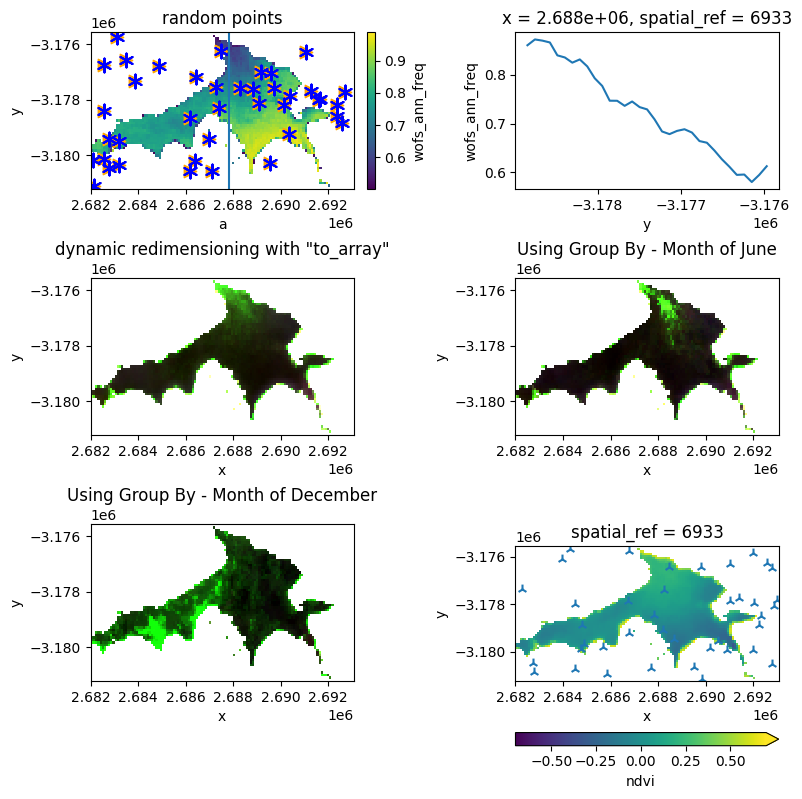

In [670]:

# demonstratnig select to pull out the values nearest to a sequence of x,y, coords (in this case a line)
cm = 1/2.54
fig, axes = plt.subplots(3,2,sharex=False, sharey=False, layout="constrained")    
fig.set_size_inches(20*cm,20*cm)
#plt.subplots(figsize=(20*cm,10*cm))
axis  = axes[0, 0]
ds.wofs_ann_freq.mean(dim='time').plot(ax=axis)
axis.set_xlabel('a')
axis.set_title('random points')

axis.scatter(data_x, data_y, s=80, c='orange', marker=">")
axis.scatter(data_x, data_y, s=8, c='black', marker=".")
axis.scatter(data_x, data_y, s=100, c='blue', marker=(6,2))

axis.axvline(geopoints.geometry.x[25])

axis = axes[0,1]
ds.sel(x=geopoints.geometry.x[25],method='nearest').mean(dim='time')['wofs_ann_freq'].plot(ax=axis)

axis = axes[1,0]
ds[['oli01','oli02','oli03','oli04','oli05']].to_array('oli').median(dim='time').sel(oli=['oli04','oli05','oli02']).plot.imshow(
    #vmin=0,
    #vmax=400,
    robust=True,
    ax=axis
    )
axis.set_title('dynamic redimensioning with "to_array"')
axis.set_axis_on()

axis = axes[1,1]
ds[['oli01','oli02','oli03','oli04','oli05']].to_array('oli').\
    groupby('time.month').\
    median(dim='time').\
    sel(month=6,oli=['oli04','oli05','oli02']).\
    plot.imshow(robust=True,ax=axis)
axis.set_title('Using Group By - Month of June')

axis = axes[2,0]
ds[['oli01','oli02','oli03','oli04','oli05']].to_array('oli').\
    groupby('time.month').\
    median(dim='time').\
    sel(month=12,oli=['oli04','oli05','oli02']).\
    plot.imshow(robust=True,ax=axis)
axis.set_title('Using Group By - Month of December')

axis = axes[2, 1]
ds.ndvi.mean(dim='time').plot(ax=axis,vmin=-0.7,vmax=0.7,cbar_kwargs=cbar_kwargs)
geopoints.plot(ax=axis, markersize=50, marker=('2'))
plt.show()


plt.show()

### Converting variables into a new dimension - use .to_array !! A Single STEP!! 

In [416]:
# -- create a new array which can instatnly be added back into the dataset if there are not ambiguities through naming etc.
ds['oli_reflectance'] = ds[['oli01','oli02','oli03','oli04','oli05']].to_array('oli_var')

### Grouping of months etc.,  - use groupby, but this is useful only if times are taken as recurring, rather than a sequence

### Aggregation on time - use resample. This is ONLY suited to time. 

In [ ]:
#ds.resample(time='1W').mean()['ndvi'].median(dim=('x','y'))
ds.resample({'time':'1W'}).mean()['ndvi'].median(dim=('x','y'))

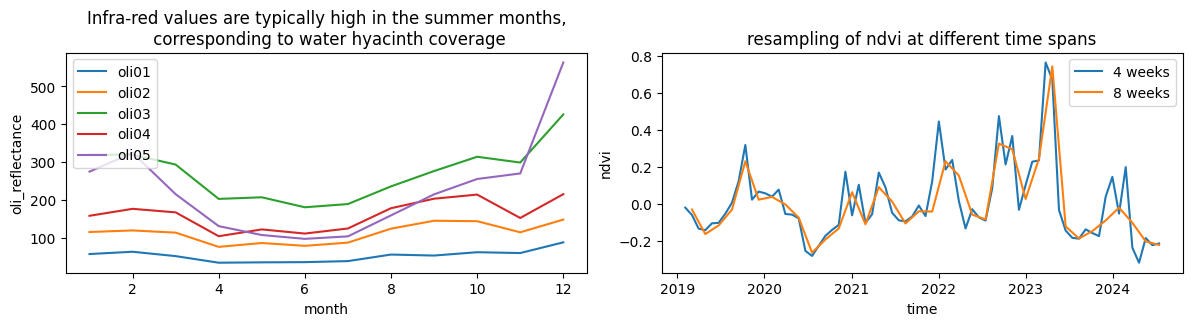

In [445]:
# plots demonstrating the above
fig, axes = plt.subplots(1,2,sharex=False, sharey=False, layout="constrained")    
fig.set_size_inches(30*cm,8*cm)

ds['ndvi_oli'] = (ds.oli05 - ds.oli04) / (ds.oli05 + ds.oli04)
ds_month = ds.groupby('time.month').\
        median().median(dim=('x','y'))

axis  = axes[0]
for band in ds_month.oli_var:
    ds_month.sel(oli_var = band)['oli_reflectance'].plot(label=band.values,ax=axis)
axis.set_title('Infra-red values are typically high in the summer months,\n corresponding to water hyacinth coverage')
axis.legend(loc='upper left')
#axis.set_xlabel('a')

axis = axes[1]
for weeks in [4,8,]:
    ds.resample({'time' : str(weeks)+'W'}).median()['ndvi'].median(dim=('x','y')).plot(label=str(weeks)+' weeks')
axis.set_title('resampling of ndvi at different time spans')
axis.legend(loc='best')
plt.show()

In [429]:
# --- some of the avialable time clumps ...
timealias = \
[
'B',  #business day frequency
'W',  # week
'ME', # month end
'MS', # month start
'SME', #semi=month
'YS', #year start
'YE', #year end
]


### Increasing the spatial resolution
- the order of dimensions is assumed to be 'time','y','x' so may need to transpose these
- not sure how to control the origin, but that is not important right now
- nodata values should be filled with 'a sensible value' to avoid holes (which is another topic)



In [667]:
upscale_factor = 2
resample_method = rio.enums.Resampling.cubic
new_width = ds.rio.width * upscale_factor
new_height = ds.rio.height * upscale_factor
ds_hr = ds.wofs_ann_freq.\
    transpose('time','y','x').\
    rio.\
    reproject(
        ds.rio.crs,
        shape=(new_height,new_width),
        resampling = resample_method,
    )


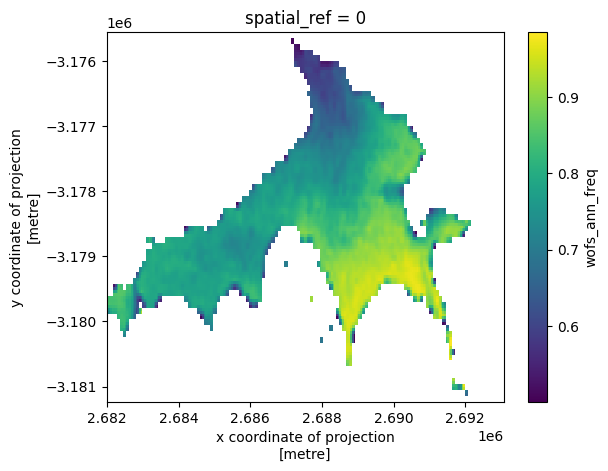

In [669]:
ds_hr.median(dim='time').plot()

### Aggregation on space , use groupby_bins (which doesn't work with time!)

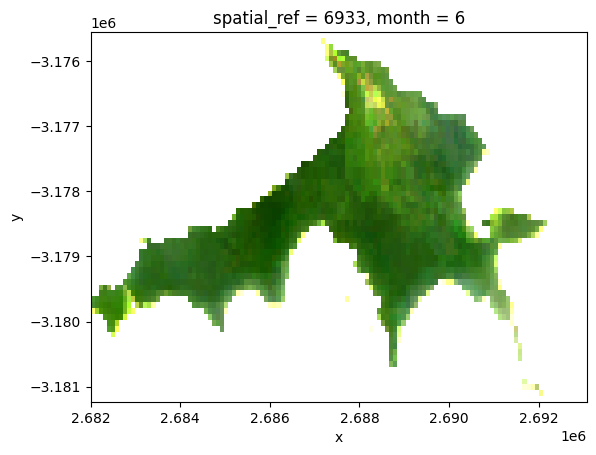

In [657]:
ds[['oli01','oli02','oli03','oli04','oli05']].\
    to_array('oli').groupby('time.month').\
    median(dim='time').\
    sel(month=6,oli=['oli04','oli03','oli02']).plot.imshow(robust=True)

<DatasetGroupBy, grouped over 1 grouper(s), 1023 groups in total:
    'time': UniqueGrouper('time'), 1023/1023 groups with labels 2019-01-06T07:57:23.703137, ...>

These couple of cells explore the relationship between an ndvi calculated on direct values v. values interpolated to the ideal lambda.
The key question is, is the relationship linear?
The numbers here are complete fabrication.
Answer: yes, its linear. No new information is introduced. Should be able to prove this algebraically

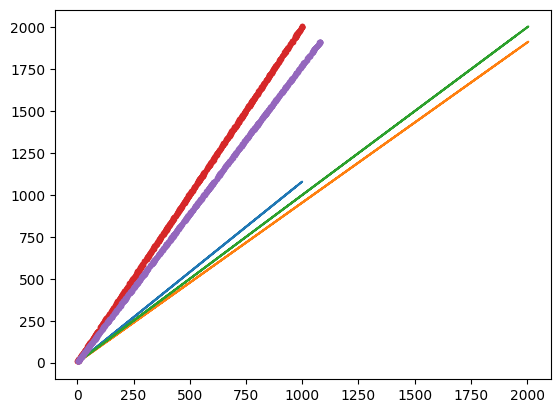

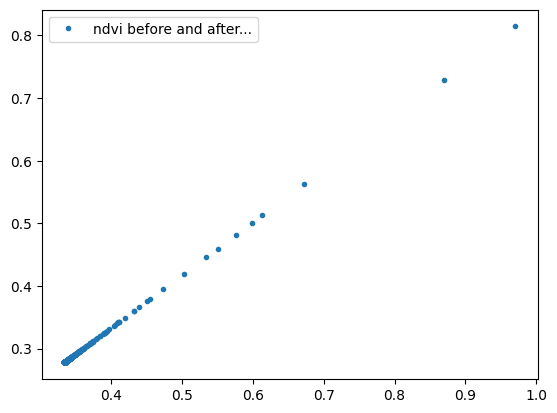

In [82]:
reflectance_l1 = np.random.rand(1000) * 1000
reflectance_l2 = reflectance_l1 * 2 + np.random.rand(1000)*10
l1_avail = 608
l1_ideal  = 630
l2_avail = 885
l2_ideal = 860

a = reflectance_l1[:]
b = reflectance_l2[:]
a1 = a + (b - a) * (l1_ideal - l1_avail) / ( l2_avail - l1_avail)
b1 = b + (b - a) * (l2_ideal - l2_avail) / ( l2_avail - l1_avail)

plt.plot(a,a1)
plt.plot(b,b1)
plt.plot(b,b)
plt.plot(a,b,linestyle='',marker='.')
plt.plot(a1,b1,linestyle='',marker='.')
plt.show()
ndvi = (b - a) / (b + a)
ndvi_new = (b1 - a1) / (b1 + a1)
plt.plot(ndvi,ndvi_new,linestyle='',marker='.',label='ndvi before and after...')
plt.legend()
plt.show()
#plt.plot(ndvi,ndvi,linestyle='',marker='.',label='a = b')




In [3]:
# --- controlling parameters and settings
verbose = True 
test    = False
# --- the number of cells in the spatial domain (x,y) used to analyse the waterbody ; Data are resampled guided by this limit 
max_cells = 100000   
max_cells = 50000   #use this to test memory limits. Memory saving steps are going to be needed...

In [4]:
# --- get the dictionary of all possible places for analysis ---

places_dict     = set_spacetime_domain()   
# --- extract an AOI for a given placename (could iterate through the dictionary keys as an alternative)
year1, year2 = None, None
placename = 'Lake_Sulunga'   
placename = 'Ghana_River'   
placename = 'Lake_Tikpan'   
placename,year1,year2 = 'Lake Chamo','2005-01-01','2005-12-31'
placename,year1,year2 = 'Lake Ziway','2005-01-01','2005-12-31'
placename,year1,year2 = 'Lake Awassa','2005-01-01','2005-12-31'
placename,year1,year2 = 'Lake_Manyara','2015-12-01','2016-03-31'   
placename,year1,year2 = 'SA_smalldam','2020-01-01','2020-12-31' 
placename,year1,year2 = 'Lake_vic_algae','2018-1-01','2018-07-10'
placename,year1,year2 = 'Lake_vic_kisumu','2019-01-01','2019-12-31'
placename,year1,year2 = 'Lake_Manyara','2015-12-01','2016-03-31'   
placename,year1,year2 = 'Haartbeesport_dam','2020-01-01','2021-06-30'   




# a good example for monitoring - (35.7236, 35.9286) (-3.8135, -3.4085), late 2015, to 2016-02-16   
# --- the functions set_spacetime_domain is used here to set a bunch of processing parameters
# --- when operationalising, this must be replaced but an approach that iterates through tiles or waterebodiies

spacetime_domain, grid_resolution, cell_area, resampling_option, year1, year2 \
                           = set_spacetime_domain(
                               placename,
                               #'2015-12-01','2016-03-31',
                               #'2018-1-01','2018-07-10',
                               year1 = year1, year2 = year2,
                               max_cells = max_cells,
                               verbose=verbose,test=False)



Haartbeesport_dam AOI:  {'x': (27.7972, 27.91117), 'y': (-25.7761, -25.7275), 'time': ('2020-01-01', '2021-06-30')} Haartbeesport Dam  -- South Africa
Grid resolution will be: (30, 30)
Rough dimensions (x,y):  10  by  4 kilometres
Total cells is roughly:  55420
Cell area is:  0.0009  km2
Resampling : bilinear
Site name:  Haartbeesport Dam  -- South Africa
Years: 2020-01-01 2021-06-30


In [ ]:
places_dict['SA_smalldam1']

In [479]:
t0 = ds.time[22]
t1 = ds.time[23]
ds.x[30]
#20:23,25:28
ds3by3 = ds.sel(y = slice(ds.y[20],ds.y[22]) , x = slice(ds.x[25],ds.x[27]) , time=t0)
#ds3by3.isel(time=0).msi02_agm.plot()

In [12]:
i =0
i+=1
i

1

In [ ]:
ds.loc[dict(time = ds.time[1:3])]
ds.loc[dict(time = np.array((ds.time[1],ds.time[2])))]

In [134]:
vec = create_OWT_response_models()['oli']
vec

,OWT,oli01,oli02,oli03,oli04,oli08
OWT-1,1,0.028313,0.102819,0.179876,0.076657,0.493393
OWT-2,2,0.063744,0.140070,0.171544,0.039945,0.397916
OWT-3,3,0.015558,0.047517,0.161972,0.050490,0.414282
OWT-4,4,0.019639,0.087564,0.229086,0.072904,0.552650
OWT-5,5,0.053635,0.159666,0.198522,0.048680,0.462887
OWT-6,6,0.018136,0.088019,0.211073,0.089788,0.580378
OWT-7,7,0.016766,0.037770,0.095916,0.100099,0.374459
OWT-8,8,0.030027,0.117584,0.213271,0.072298,0.542845
OWT-9,9,0.010130,0.042495,0.112891,0.031869,0.244615
OWT-10,10,0.079854,0.258508,0.194556,0.019149,0.374083


In [1225]:
# --- get the spectral reflectance functions for the open water types (
OWT_vector_data = create_OWT_response_models()
for instrument in 'msi','oli','tm':
    if instrument in ds.data_vars:
        OWT_vectors = OWT_vector_data[instrument]    # the spectral reflectances specific to this sensor
        OWT_data    = OWT(ds.where(ds.qa_score >0),instrument,OWT_vectors,test=False, verbose=True) 
    if 'owt' in ds.data_vars:
        ds['owt'] = xr.where(~np.isnan(OWT_data),OWT_data,ds['owt'])
    else : 
        ds['owt'] = OWT_data
    del OWT_data
gc.collect()



 calculating optical water type (OWT), sensor =  msi  ....

....done
Prevailng water type is  3.0  :   oligotrophic (clear)

 calculating optical water type (OWT), sensor =  oli  ....

....done
Prevailng water type is  6.0  :   hyper-eutrophic and green-brown

 calculating optical water type (OWT), sensor =  tm  ....

....done
Prevailng water type is  1.0  :   eutrophic and blue-green


0

In [ ]:
ds.owt.median(dim=('x','y')).plot(linestyle='',marker='.')
ds.where(ds['oli']).owt.median(dim=('x','y')).plot(linestyle='',marker='.')
ds.where(ds['tm']).owt.median(dim=('x','y')).plot(linestyle='',marker='.')
ds.where(ds['msi']).owt.median(dim=('x','y')).plot(linestyle='',marker='.')

In [1156]:
md.owt_current

Data variables:
    owt_current     (time, y, x) float64 63MB nan nan nan nan ... nan nan nan
    owt_cos_max     (time, y, x) float64 63MB nan nan nan nan ... nan nan nan
    owt_cos         (time, y, x) float64 63MB nan nan nan nan ... nan nan nan
    owt_closest     (time, y, x) float64 63MB nan nan nan nan ... nan nan nan
    self_product    (time, y, x) float64 63MB nan nan nan nan ... nan nan nan
    vector_product  (time, y, x) float64 63MB nan nan nan nan ... nan nan nan

In [ ]:
i = i  #1004
print(ds.isel(time=i)[['tm','oli','msi']].values)
ds.isel(time=i).owt.plot(robust=True)
plt.show()
ds.isel(time=i).owt.plot(robust=True)
print(i)
i = i + 1

In [ ]:
with open(filename, 'w') as f:
  f.write(str(parameters))
    
# --- annual and daily files are easily saved as csv files
filename = basefilename+'_annual.csv'
results['annual_results'].to_csv(filename)

In [ ]:
# The code below renders a map that can be used to view the region.
display_map(place_and_time['xyt']['x'],place_and_time['xyt']['y'])

In [5]:
dataset_filename                     = '/home/jovyan/AdamsWork/scratch/wp21_ds_'+placename+'.nc'                         #used to save files between steps
dataset_agm_filename                 = '/home/jovyan/AdamsWork/scratch/wp21_ds_'+placename+'_agm.nc'                 #used to save files between steps
wq_normalisation_parameters_filename = '/home/jovyan/dev/deafrica_water_quality/WP1.4/wq_normalisation_parameters.json'   #normalisation parameters


Read the dataset in, and shed time slices that have poor quality

In [11]:
def read_dataset(filename):
    ds   = xr.open_dataset(filename).load(); ds.close()
    return(ds)

In [13]:
qa_threshold = 0      # ---> 20  percent of good data ; 20% threshold already applied in data preparation step
ds           = read_dataset(dataset_filename)   #.where(ds.qapasspercent > qa_threshold,drop=True)
ds_annual    = read_dataset(dataset_agm_filename)

In [47]:
# --- pulling out a 3 by 3 dataset --- notice that slice includes the end coordinates,
#     loc and sel with dict use integer label methods, not good for x,y coordinates or ranges)

ds.isel(time=[1000],x=[61],y=slice(32,34))
t1000 = ds.time[1000]
ds3by3 = ds.sel(y = slice(ds.y[32],ds.y[34]) , x = slice(ds.x[60],ds.x[62]) , time=t1000)

# dict only works on integer coordinates
#ds[dict(time=t1000)]   <--- fails

# loc is more powerful:
#ds.sel(dict(time = t1000))

#ds.loc[dict(time = t1000)]
#ds.isel(time=[1000]).msi03.plot()


In [197]:
ds2 = ds.isel(time=slice(2,10)).isel(x=slice(30,40)).isel(y=slice(15,35))

In [262]:
%run /home/jovyan/dev/deafrica_water_quality/WP1.2/_WQ_functions.py
# --- add a variable for the hue, and calculate the hue values sequentially for each instrument
#     additional handling necssary for the geomedians...

ds['hue'] = ('time','y','x'),np.zeros([ds.time.size,ds.y.size,ds.x.size])*np.nan

for instr in 'msi','oli','tm':
    ds['hue'] = xr.where(ds[instr]==1,
    hue_calculation(ds.where(ds[instr]==1),instr,rayleigh_corrected_data = False),
    ds.hue)
    
#ds2 = xr.where(ds2.where(ds2.msi==1),test(ds2.where(ds2.msi==1),'msi',rayleigh_corrected_data = False),ds2)
#ds2 = xr.where(ds2.where(ds2.oli==1),test(ds2.where(ds2.oli==1),'oli',rayleigh_corrected_data = False),ds2)
#ds2 = xr.where(ds2.where(ds2.msi==1),test(ds2.where(ds2.msi==1),'msi',rayleigh_corrected_data = False),ds2)

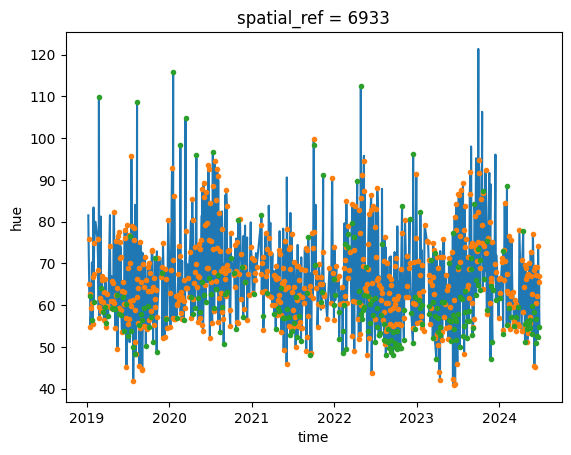

In [263]:
ds.hue.mean(dim=('x','y')).plot()
ds.where(ds['msi']).hue.mean(dim=('x','y')).plot(linestyle='',marker='.',label='msi')
ds.where(ds['oli']).hue.mean(dim=('x','y')).plot(linestyle='',marker='.')
#ds.where(ds['tm']).hue.mean(dim=('x','y')).plot(linestyle='',marker='.')

In [150]:
ds2[['oli','tm','msi']]

<xarray.Dataset> Size: 260B
Dimensions:      (time: 8)
Coordinates:
  * time         (time) datetime64[ns] 64B 2019-01-10T08:27:19 ... 2019-01-22...
    spatial_ref  int32 4B 6933
Data variables:
    oli          (time) float64 64B 0.0 0.0 0.0 1.0 0.0 0.0 1.0 0.0
    tm           (time) float64 64B 0.0 0.0 1.0 0.0 0.0 0.0 0.0 1.0
    msi          (time) float64 64B 1.0 1.0 0.0 0.0 1.0 1.0 0.0 0.0
Attributes:
    crs:           epsg:6933
    grid_mapping:  spatial_ref

### Add boolean variables to the geomedian time series to identify which sensors are avaialable each year


In [9]:
# --- Add boolean variables that indicate which instruments are available in the geomedian data series for a given year. For earlier years tm is available. 
# --- assume that the 'smad' will always be a variable, and use this as an indicator 
def detect_geomedian_instruments (ds_annual):
    for inst in 'oli_agm','tm_agm','msi_agm':
        if inst+'_smad' in ds_annual.data_vars:
            ds_annual[inst] = ('time'), np.zeros(ds_annual.sizes['time'],dtype ='bool')
            ds_annual[inst] = ~np.isnan(ds_annual[inst+'_smad'].mean(dim=('x','y')))
    return ds_annual
    
ds_annual = detect_geomedian_instruments(ds_annual)

684


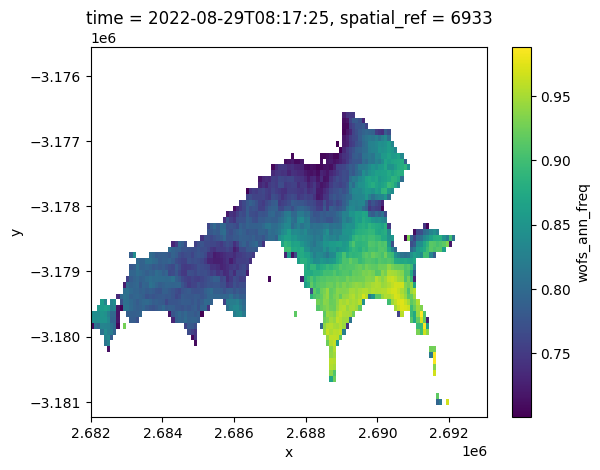

msi


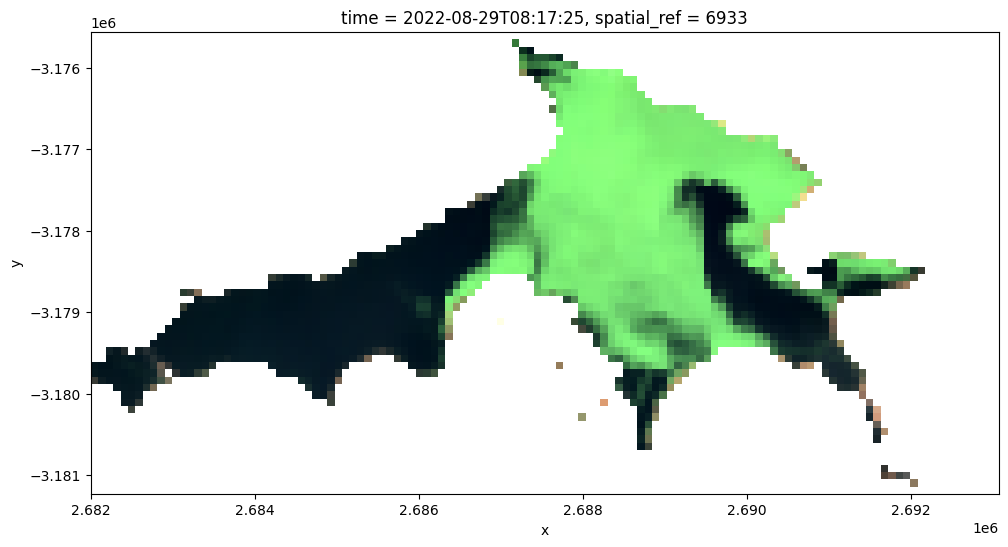

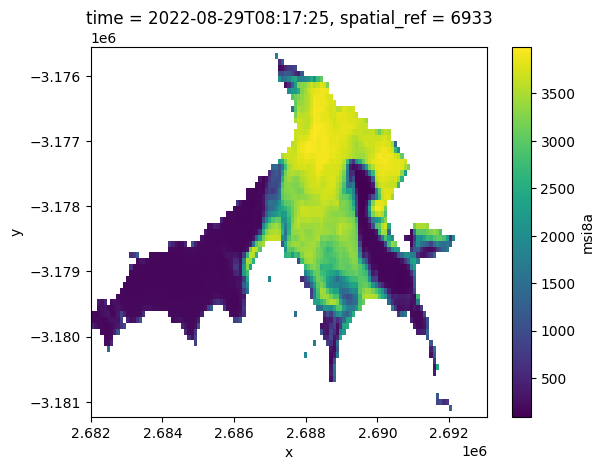

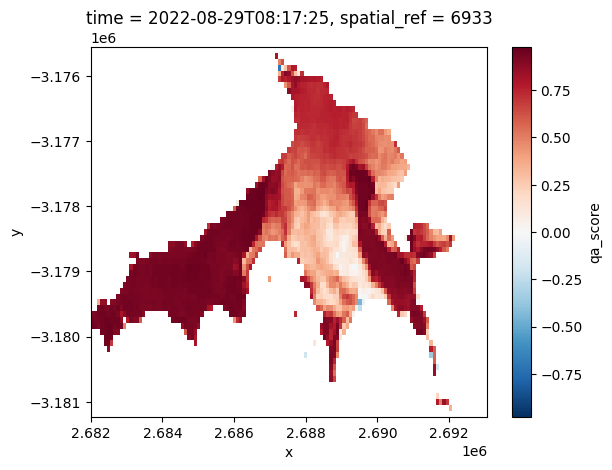

NameError: name 'cutoff' is not defined

In [16]:
#examine results
#i = 36  #example of tm data over estimating fai I think.
i =  684

WAFT = 0.7

ds_plot = ds.isel(time = i)

print(i)
ds_plot.where(ds_plot.wofs_ann_freq  > WAFT).\
        wofs_ann_freq.plot()
plt.show()

if ds_plot.oli: 
    print('oli')
    inst  = 'oli'
    rgb(ds_plot,bands=['oli04','oli03','oli02'],robust = True),plt.show()
    plt.show()
    ds.isel(time=i).oli05.plot()
    plt.show()

if ds_plot.msi: 
    print('msi')
    inst  = 'msi'
    rgb(ds_plot,bands=['msi04','msi03','msi02'],robust = True)
    plt.show()
    ds.isel(time=i).msi8a.plot()
    plt.show()

if ds_plot.tm:  
    print('tm')
    inst  = 'tm'
    rgb(ds_plot,bands=['tm03','tm02','tm01'],robust = True)
    plt.show()
    ds.isel(time=i).tm04.plot()
    plt.show()
    

#ds.isel(time=i).qa_ralb.plot()
#plt.show()

#ds.isel(time=i).qa_rsad.plot()
#plt.show()
ds_plot.qa_score.plot()
plt.show()
ds_plot.where(ds_plot.qa_score > 0).\
        where(ds_plot.wofs_ann_freq  > WAFT).\
        where(ds_plot.fai > cutoff['fai'][inst]).\
        fai.plot()
plt.show()
ds_plot.ndvi.plot(),plt.show()
i = i + 1


In [151]:
# building a dictionary of results, showing each instrument and each measure, mean by month
# later will add the percentage of area with measure above threshold, which requires allowance for the proportion of valid data
# For FAI and NDVI, waters-edge pixels cause elevated results (?)
# to mitigate, apply a wofs threshold > 0.5. 
# This will lose some areas of persistent FAI. Mitigate by taking a longer term average of the wofs frequency - say 5 years. (This suggests that ds_annual should be at lead 5 years in duration.)
# Experience suggests that a 5-year wofs frequency of 0.6 keeps the main waterbody. 0.66 is the upper limit before area is lost. The area that is lost
# will be areas that are frequently high FAI. 

WAFT = wofs_annual_frequency_threhold = 0.5
cutoff = {
    'ndvi' : {'msi': 0.06417626689906246, 'oli' : 0.0575998312383445, 'tm': 0.08210079534199263},
    'fai'  : {'msi': 0.02794809173030531, 'oli' : 0.0370059408963587, 'tm': 0.05294067859852353},
    }
cutoff = {
    'ndvi' : {'msi': 0.08, 'oli' : 0.06, 'tm': 0.08},
    'fai'  : {'msi': 0.05, 'oli' : 0.03, 'tm': 0.02},
    }
cutoff = {
    'ndvi' : {'msi': 0.08, 'oli' : 0.06, 'tm': 0.08},
    'fai'  : {'msi': 0.10, 'oli' : 0.06, 'tm': 0.04},
    }
reference_mean = {
    'ndvi' : {'msi': 0.3268506413577676,  'oli' : 0.3304715643505414,  'tm': 0.2788954907387175},
    'fai'  : {'msi': 0.09706884994492773, 'oli' : 0.10152865645460406, 'tm': 0.09626936881950525},
    }
results = {
    'reference_mean': reference_mean, 
    'cutoff': cutoff, 
    'time':ds.time, 
    'fai_mean' : {},
    'fai_count' : {},
    'ndvi_mean': {},
    'ndvi_count': {},
    'coverage' : ds.qapasspercent / 100. ,
    'total_pixels' : ds.where(ds.wofs_ann_freq > WAFT).isel(time=0).wofs_ann_freq.count().item(),
    'pixel_area'   : (ds.x[1] - ds.x[0]) * (ds.y[1] - ds.y[0]) / 10000
    }
results['total_area'] = results['total_pixels'] * results['pixel_area']

cutoff_factor = 1  # experiment with this if necessary
reference_mean = {
    'ndvi' : {'msi': 0.3268506413577676,  'oli' : 0.3304715643505414,  'tm': 0.2788954907387175},
    'fai'  : {'msi': 0.09706884994492773, 'oli' : 0.10152865645460406, 'tm': 0.09626936881950525},
    }
for var in 'ndvi','fai':        
    first = True
    for inst in 'tm','oli','msi':
        t = cutoff[var][inst] * cutoff_factor
        # --- calculate results for the instrument, considering only values which pass qa and are above the relevant cut-off
        #     AND excluding places that don't meet the wofs threshold
        result_array       = (ds.where(ds.qa_score>0).
                              where(ds.wofs_ann_freq > WAFT).
                              where(ds[inst]).
                              where(ds[var] > t)[var].mean(dim=('x','y'))) * (reference_mean[var]['msi'] / reference_mean[var][inst])

        # --- resolve cases where no data are above the cut-off, these should be zero rather than nan values.
        result_array       = np.where(~np.isnan(result_array),result_array,np.where(ds[inst],0,np.nan))
        results[var+'_mean'][inst] = result_array

        # --- now calculate the area above the threshold value, scaling up to allow for limited coverage 
        #     AND excluding places with low wofs threshold
        result_array       =  (ds.where(ds.qa_score>0).
                               where(ds.wofs_ann_freq > WAFT).
                               where(ds[inst]).
                               where(ds[var] > t)[var].count(dim=('x','y')) / results['coverage']).astype('int')
        result_array                = result_array.where(ds[inst])  # <--- return nans where this sensor is not applicable
        results[var+'_count'][inst] = result_array

        if first:
            first = False
            inst_all_mean  = results[var+'_mean'][inst]
            inst_all_count = results[var+'_count'][inst]
        else:
            inst_all_mean  = np.where(~np.isnan(inst_all_mean), inst_all_mean, results[var+'_mean'][inst])
            inst_all_count = np.where(~np.isnan(inst_all_count),inst_all_count,results[var+'_count'][inst])
        results[var+'_mean']['all']  = inst_all_mean
        results[var+'_count']['all'] = inst_all_count
        


In [262]:
# building a dictionary of results for the annual geomedian dataset. This is a simplified version of the previous process,
#    modified also because in the geomedian time series the observations for all instruments are assumed to be conincident ... 

# these variables should have been set in the previous cell, keeping them consistent
WAFT = wofs_annual_frequency_threhold
cutoff = cutoff
reference_mean = reference_mean
#cutoffs need to be different for the geomedian .... reverting to the statistically determined cut-offs which may be more approprite for a mean value..

cutoff = {
    'ndvi' : {'msi': 0.08, 'oli' : 0.06, 'tm': 0.08},
    'fai'  : {'msi': 0.10, 'oli' : 0.06, 'tm': 0.04},
    }

cutoff = {
    'ndvi' : {'msi': 0.06417626689906246, 'oli' : 0.0575998312383445, 'tm': 0.08210079534199263},
    'fai'  : {'msi': 0.02794809173030531, 'oli' : 0.0370059408963587, 'tm': 0.05294067859852353},
    }
cutoff = {
    'ndvi' : {'msi': 0.06417626689906246, 'oli' : 0.0575998312383445, 'tm': 0.08210079534199263},
    'fai'  : {'msi': 0.02794809173030531, 'oli' : 0.050059408963587, 'tm': 0.05294067859852353},
    }


results_agm = {
    'reference_mean': reference_mean, 
    'cutoff': cutoff, 
    'time':ds_annual.time, 
    'fai_mean' : {},
    'fai_count' : {},
    'ndvi_mean': {},
    'ndvi_count': {},
    'coverage' : 1. , #geomedian datasets are assumed to be complete
    'total_pixels' : ds_annual.where(ds_annual.wofs_all_freq > WAFT).wofs_all_freq.count().item(),
    'pixel_area'   : (ds_annual.x[1] - ds_annual.x[0]) * (ds_annual.y[1] - ds_annual.y[0]) / 10000
    }
results_agm['total_area'] = results_agm['total_pixels'] * results_agm['pixel_area']

cutoff_factor = 0.25  # experimentnot used

 # used to scale the mean values of the index to match those of msi
reference_mean = {
    'ndvi' : {'msi': 0.3268506413577676,  'oli' : 0.3304715643505414,  'tm': 0.2788954907387175},
    'fai'  : {'msi': 0.09706884994492773, 'oli' : 0.10152865645460406, 'tm': 0.09626936881950525},
    }


for var in list(['fai']):        
    first = True
    for inst in 'oli','msi':   
        agm_inst = inst+'_agm'
        agm_var  = agm_inst+'_'+var
        t = cutoff[var][inst] * cutoff_factor
        # --- calculate average results for the instrument, considering only values which pass qa and are above the relevant cut-off
        #     AND excluding places that don't meet the wofs threshold
        result_array       = (ds_annual.
                              where(ds_annual[agm_inst]).
                              where(ds_annual.wofs_all_freq > WAFT).
                              where(ds_annual[agm_var] > t)[agm_var].mean(dim=('x','y'))) * (reference_mean[var]['msi'] / reference_mean[var][inst])

        # --- resolve cases where no data are above the cut-off, these should be zero rather than nan values.
        # --- this will come into play with geomedians if the time series goes beyond msi, oli etc.
                
        result_array       = np.where(~np.isnan(result_array),result_array,np.where(ds_annual[agm_inst],0,np.nan))
        results_agm[var+'_mean'][agm_inst] = result_array

        # --- now (more relevant) calculate the area above the threshold value, scaling up to allow for limited coverage 
        #     AND excluding places with low wofs threshold
        result_array       =  (ds_annual.
            where(ds_annual[agm_inst]).
            where(ds_annual.wofs_all_freq > WAFT).
            where(ds_annual[agm_var] * (reference_mean[var]['msi'] / reference_mean[var][inst]) > t)[agm_var].
                               count(dim=('x','y')) / results_agm['coverage']).astype('int')
        
        result_array       = result_array.where(ds_annual[agm_inst])  # <--- return nans where this sensor is not applicable
        results_agm[var+'_count'][agm_inst] = result_array

        if first:
            first = False
            count = 1
            inst_all_mean  = results_agm[var+'_mean'] [agm_inst]
            inst_all_count = results_agm[var+'_count'][agm_inst]
        else:
            count = count + 1
            inst_all_mean  = np.where(~np.isnan(inst_all_mean), inst_all_mean, results_agm[var+'_mean'][agm_inst])
            inst_all_count = inst_all_count + results_agm[var+'_count'][agm_inst]
        results_agm[var+'_mean']['all']  = inst_all_mean
        results_agm[var+'_count']['all'] = inst_all_count/count
        


In [225]:
#moving average function with the added option to reflect data at the ends to retain a full set of data points 
def moving_average(a, n=3, reflect = True):
    if reflect :
        N = int(n/2)
        s = a.size
        a = np.hstack((a[N:0:-1],a,a[s-2:s-N-2:-1]))
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

In [226]:
%run /home/jovyan/AdamsWork/_AL_functions.ipynb  

Loading AL_functions


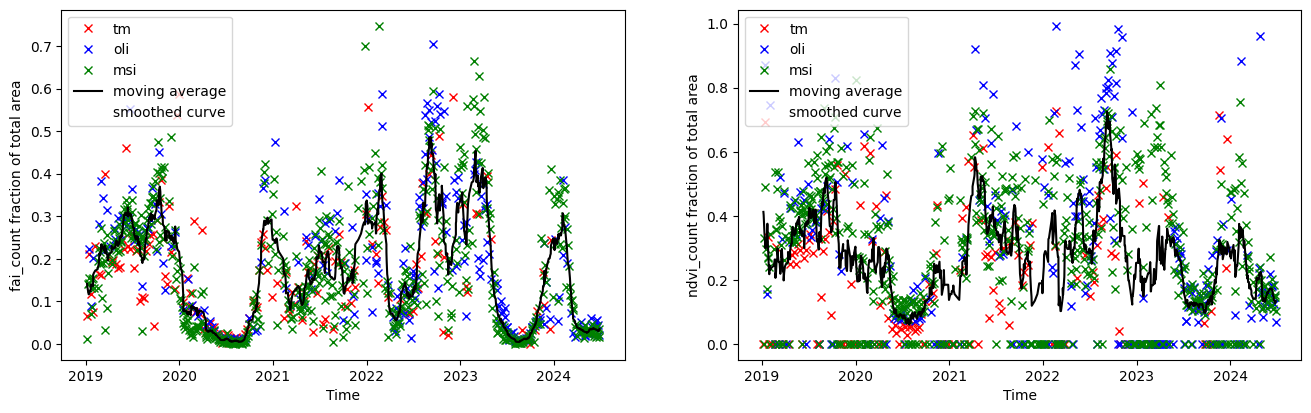

In [85]:
# pull out into a simple array, smooth a couple of times and fit a quadratic spline
#slym = piecewise_linreg(ds.time.astype('float'),lym,keepnans=True,test=False)[0][1]
#sslym = piecewise_linreg(ds.time.astype('float'),slym,keepnans=True,test=False)[0][1]

#smoothed = sp.interpolate.interp1d(ds.time,sslym,kind='cubic',fill_value='extrapolate')
#t_new    = pd.date_range(ds.time.min().values, ds.time.max().values, freq='1D')

smoothing_window = 13   #needs to be an odd number or my function will break!
plt.figure(figsize=[16,10])

plt.subplot(2,2,1)

var = 'fai_count'
plt.xlabel('Time')
plt.ylabel(var+' mean')
plt.ylabel(var+' fraction of total area')


# smoothing steps are needed to make a nice graph of these data!
# --- take a moving average window of 5, retain ends
# --- fit a linear piecewise model to take out local peaks and troughs
# --- fit a smooth interpolation, various choices...




data = results[var]['all']/results['total_pixels']
data = np.vstack((data,
                  moving_average(data,smoothing_window),
                                ))
#data = np.vstack((results[var]['all']/results['total_pixels'],moving_average(results[var]['all'],5)))
s1   = piecewise_linreg(ds.time.astype('float'),data[1,:],keepnans=True,test=False)[0][1]
data = np.vstack((data,s1,
                  results[var]['tm']/results['total_pixels'],
                  results[var]['oli']/results['total_pixels'],
                  results[var]['msi']/results['total_pixels']))


smoothed = sp.interpolate.interp1d(results['time'],data[2,:],kind='cubic',fill_value='extrapolate')
smoothed = sp.interpolate.Akima1DInterpolator(results['time'],data[2,:],extrapolate=True)
t_days    = pd.date_range(results['time'].min().values, results['time'].max().values, freq='1D')


plt.plot(results['time'],data[3,:],'r',linestyle="", marker="x",label='tm')  
plt.plot(results['time'],data[4,:],'b',linestyle="", marker="x",label='oli')  
plt.plot(results['time'],data[5,:],'g',linestyle="", marker="x",label='msi')  
plt.plot(results['time'],data[1,:],'k',linestyle="-", marker="",label='Moving Average')  
plt.plot(results['time'],data[2,:],'g',linestyle="", marker="",label='')  
#plt.plot(t_days         ,smoothed(t_days).clip(0),'k',linestyle="-.", marker="",label='Smoothed line')  
#plt.plot(results['time'],data[1,:]/results['coverage'],'r',linestyle="", marker="o",label='Moving Average')  
#plt.plot(t_new,smoothed(t_new),'g',linestyle="--", marker="",label='LYM TSI excess')  

plt.legend(['tm','oli','msi','moving average','smoothed curve'])

# ---------------------------------------------------------------------

plt.subplot(2,2,2)

var = 'ndvi_count'
plt.xlabel('Time')
plt.ylabel(var+' fraction of total area')

data = results[var]['all']/results['total_pixels']
data = np.vstack((data,moving_average(data,smoothing_window)))
#data = np.vstack((results[var]['all']/results['total_pixels'],moving_average(results[var]['all'],5)))
s1   = piecewise_linreg(ds.time.astype('float'),data[1,:],keepnans=True,test=False)[0][1]
data = np.vstack((data,s1,
                  results[var]['tm']/results['total_pixels'],
                  results[var]['oli']/results['total_pixels'],
                  results[var]['msi']/results['total_pixels']))
smoothed = sp.interpolate.interp1d(results['time'],data[2,:],kind='cubic',fill_value='extrapolate')
smoothed = sp.interpolate.Akima1DInterpolator(results['time'],data[2,:],extrapolate=True)
t_days    = pd.date_range(results['time'].min().values, results['time'].max().values, freq='1D')


plt.plot(results['time'],data[3,:],'r',linestyle="", marker="x",label='tm')  
plt.plot(results['time'],data[4,:],'b',linestyle="", marker="x",label='oli')  
plt.plot(results['time'],data[5,:],'g',linestyle="", marker="x",label='msi')  
plt.plot(results['time'],data[1,:],'k',linestyle="-", marker="",label='Moving Average')  
plt.plot(results['time'],data[2,:],'g',linestyle="", marker="",label='')  
#plt.plot(t_days         ,smoothed(t_days).clip(0),'k',linestyle="-.", marker="",label='Smoothed line')  
#plt.plot(results['time'],data[1,:]/results['coverage'],'r',linestyle="", marker="o",label='Moving Average')  
#plt.plot(t_new,smoothed(t_new),'g',linestyle="--", marker="",label='LYM TSI excess')  

plt.legend(['tm','oli','msi','moving average','smoothed curve'])
plt.show()
#-------------------------------------------------------------------

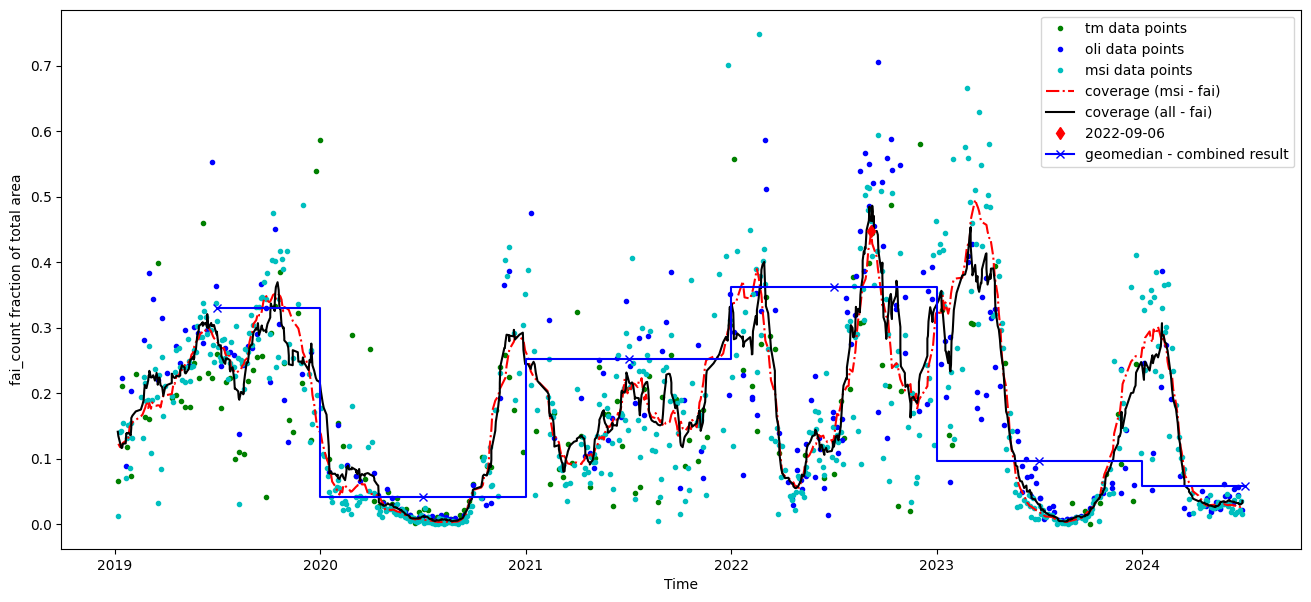

In [264]:

plt.figure(figsize=[16,7])
plt.subplot(1,1,1)
var = 'fai_count'
inst = 'msi'
plt.xlabel('Time')
plt.ylabel(var+' fraction of total area')

inst_data     = results[var][inst]/results['total_pixels']
inst_times    = ds.time     [~np.isnan(inst_data)]
inst_data     = inst_data   [~np.isnan(inst_data)]

inst_data     = np.vstack((
                           inst_data,
                           moving_average(inst_data,smoothing_window),
                           piecewise_linreg(inst_times.astype('float'),inst_data,keepnans=True,test=False)[0][1]))

smoothed = sp.interpolate.interp1d(inst_times,inst_data[2,:],kind='cubic',fill_value='extrapolate')

smoothed = sp.interpolate.Akima1DInterpolator(inst_times,inst_data[2,:],extrapolate=True)
t_days    = pd.date_range(results['time'].min().values, results['time'].max().values, freq='1D')

plt.plot(results['time'],results[var]['tm' ]/results['total_pixels'],'g',linestyle="", marker=".",label='tm')  

plt.plot(results['time'],results[var]['oli']/results['total_pixels'],'b',linestyle="", marker=".",label='oli')  

plt.plot(results['time'],results[var]['msi']/results['total_pixels'],'c',linestyle="", marker=".",label='msi')  
'''
'''
plt.plot(inst_times     ,inst_data[1,:],'r',linestyle="-.", marker="",label='Moving Average') 
plt.plot(results['time'],moving_average(results[var]['all'],smoothing_window)/results['total_pixels'],'k',linestyle="-", marker="",label='Moving Average')  


#plt.plot(t_days         ,smoothed(t_days).clip(0),'k',linestyle="--", marker="",label='Smoothed line')  
i = 414
plt.plot(inst_times[i],inst_data[1,i],'r',marker="d",linestyle = '')

#plt.step(results_agm['time'],results_agm['fai_count']['msi_agm']/ results_agm['total_pixels'],'g',where='mid',marker="x",linestyle = '-')
#plt.step(results_agm['time'],results_agm['fai_count']['oli_agm']/ results_agm['total_pixels'],'r',where='mid',marker="x",linestyle = '-')
plt.step(results_agm['time'],results_agm['fai_count']['all']/ results_agm['total_pixels'],'b',where='mid',marker="x",linestyle = '-')

#plt.legend(['tm','oli','msi','moving average',np.datetime_as_string(inst_times[414])[0:10]])
plt.legend([
            'tm data points',
            'oli data points',
            'msi data points',
            'coverage (msi - fai)',
            'coverage (all - fai)',
            np.datetime_as_string(inst_times[414])[0:10],
 #           'geomedian - msi',
 #           'geomedian - oli',
            'geomedian - combined result',
            ])



plt.show()

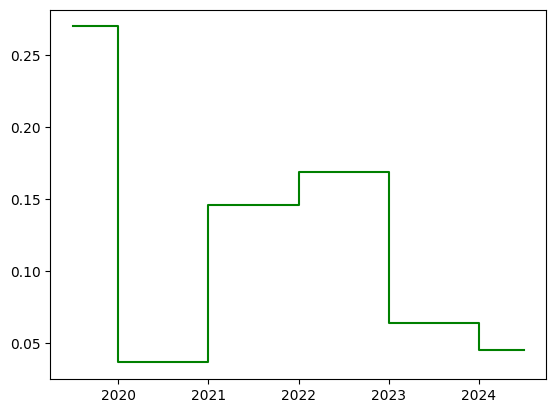

In [249]:
plt.step(results_agm['time'],results_agm['fai_count']['msi_agm']/ results_agm['total_pixels'],
                  'g',where='mid',linestyle = '-')

### Inter-sensor comparison / adjustment
- To be comfortable about using the FAI data from multiple sensors, we might want to look at the statistics. 
- If necessary we can standardise the results from TM and OLI to those of MSI. 
- Over water, MSI tends to give higher FAI values than OLI. Since both instruments are sampling from the same population, we expect them to have the same probability distribution. We can adjust the OLI data values to match the pd of data from the MSI instrument.
- However, in practice we find that adjusting the FAI from OLI sensor is **not** a good idea, because it leads to a clear DIFFERENCE in results from the sensors at the next step, where we use a threshold to identify areas that are affected.  

In [705]:
# --- a function to match probability distributions --- 'cpd' = cumulative probability distribution
#     this seems to work well;
#     notice that have to use the xr.quantile method, rather than the np.quantile() function which does not manage the nans!
#     Replicating values bring this unstuck. (The cpf must be strictly postive increasing). Not a problem with large datasets? Work around is fewer bins.
#    

def cpd_match(source_data,target_data,bins=11,method='quadratic') :
    Q = np.linspace(0,1,bins)         # --- array of quantiles, call it Q. Exclude extreme tails which can be out of range if there are data problems

    # --- calculate the quantiles (CPDs) for the source data and target data
    X = source_data.quantile(Q,skipna= True)
    Y = target_data.quantile(Q,skipna= True)

    # --- fit a model to X; ie Q = f(x)
    f = sp.interpolate.interp1d(X,Q,kind=method,fill_value='extrapolate')
    # --- fit an inverse model to Y; ie Y = g(Q)
    g = sp.interpolate.interp1d(Q,Y,kind=method,fill_value='extrapolate')
    # --- new values are given by g(f(x)), which is very cool 
    
    return xr.DataArray(g(f(source_data)),dims=source_data.dims)
    

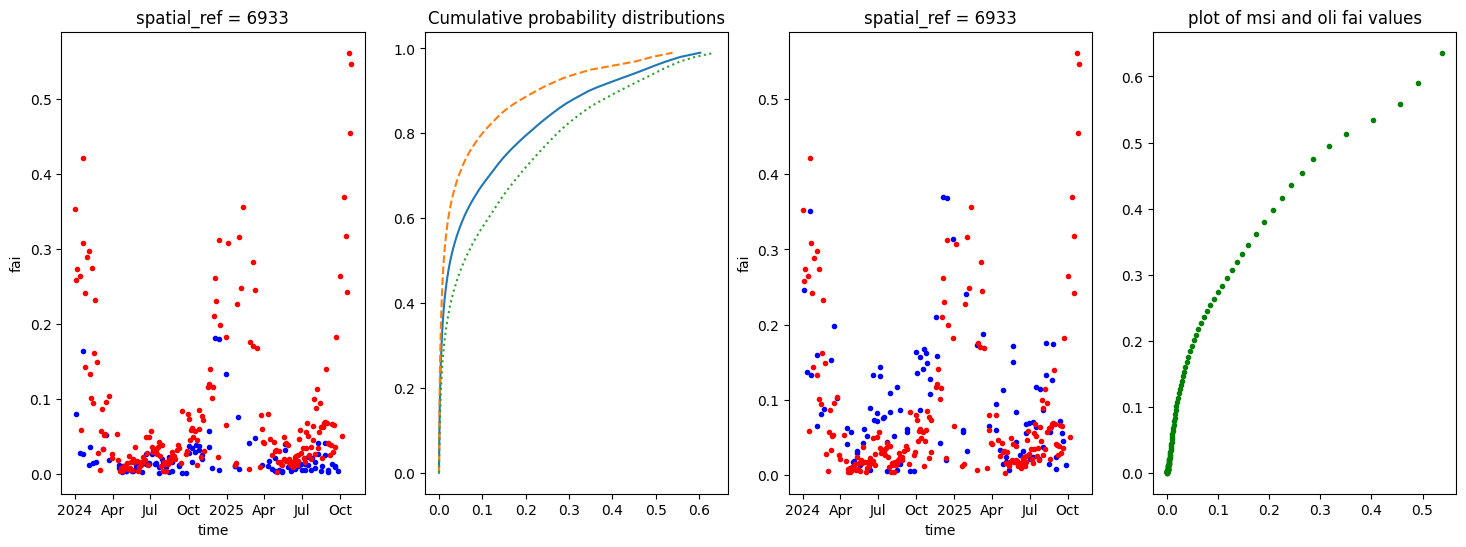

In [708]:
# display comparison of probability distributions

fig, ax = plt.subplots(1, 4, figsize=(18, 6))

#ax[2].set_ylim(0,100)

# --- first graph is the median fai for each observation date, by sensor
axisnumber = 0
ax[axisnumber].set_title("Median FAI from MSI and OLI sensors"), \
                        ax[axisnumber].xaxis.set_visible(True), \
                        ax[axisnumber].yaxis.set_visible(True)

ds.fai.loc[ds.oli==True].median(dim=('x','y')).plot(linestyle='',color='b',marker='.',ax=ax[axisnumber])
ds.fai.loc[ds.msi==True].median(dim=('x','y')).plot(linestyle='',color='r',marker='.',ax=ax[axisnumber])

# --- second graph is the cpd, overall and per sensor
plt.subplot(1,4,2)
axisnumber = 1
ax[axisnumber].set_title("Cumulative probability distributions"),\
                        ax[axisnumber].xaxis.set_visible(True), \
                        ax[axisnumber].yaxis.set_visible(True)

t = -5   # -- threshold
q0,q1= 0.,1
delta = 0.01
quantiles = np.arange(q0,q1,delta)

all = ds.fai.where(ds.fai>t).quantile(quantiles)
oli = ds.fai.loc[ds.oli==True].where(ds.fai>t).quantile(quantiles)
msi = ds.fai.loc[ds.msi==True].where(ds.fai>t).quantile(quantiles)
plt.plot(all,quantiles,linestyle='-')
plt.plot(oli,quantiles,linestyle='--')
plt.plot(msi,quantiles,linestyle=':')

    # --- fit a simple model to these data  

#cpf = sp.interpolate.interp1d(all,quantiles,kind='quadratic',fill_value='extrapolate')
#plt.plot(all,cpf(all),marker='.',color='k',linestyle='')

#ds.fai.loc[ds.msi==True].quantile(np.arange(0,1,1/q)).plot(linestyle='',color='r',marker='.',ax=ax[1])

# --- third graph is the median fai for each sensor after cpd matching

axisnumber = 2
ax[axisnumber].set_title("Median FAI from MSI and OLI after adjustment"), \
                        ax[axisnumber].xaxis.set_visible(True), \
                        ax[axisnumber].yaxis.set_visible(True)

oli_fai_new = cpd_match(
    ds.fai.loc[ds.oli==True].where(ds.fai>t),
    ds.fai.loc[ds.msi==True].where(ds.fai>t),100)

ds['oli_fai_new'] = ('time','y','x'),np.ones([ds.fai.sizes['time'],ds.fai.sizes['y'],ds.fai.sizes['x']])*np.nan
ds['oli_fai_new'].loc[ds.oli==True] = oli_fai_new

ds.oli_fai_new.           median(dim=('x','y')).plot(linestyle='',color='b',marker='.',ax=ax[axisnumber])
ds.fai.loc[ds.msi==True] .median(dim=('x','y')).plot(linestyle='',color='r',marker='.',ax=ax[axisnumber])

# --- fourth graph is to show proportions above threshold 
plt.subplot(1,4,4)
axisnumber = 3
ax[axisnumber].set_title("plot of msi and oli fai values"),\
                        ax[axisnumber].xaxis.set_visible(True), \
                        ax[axisnumber].yaxis.set_visible(True)

oli_new_cpd = ds.oli_fai_new.loc[ds.oli==True].quantile(quantiles)
plt.plot(oli,msi,linestyle='',marker='.',color='g')


In [ ]:
# --- apply the correction to the OLI data 
if False:
    ds['fai'].loc[ds.oli==True] = cpd_match(
        ds.fai.loc[ds.oli==True].where(ds.fai>t),
        ds.fai.loc[ds.msi==True].where(ds.fai>t),100)


In [235]:
results_agm['time']

<xarray.DataArray 'time' (time: 6)> Size: 48B
array(['2019-07-02T11:59:59.999999000', '2020-07-01T23:59:59.999999000',
       '2021-07-02T11:59:59.999999000', '2022-07-02T11:59:59.999999000',
       '2023-07-02T11:59:59.999999000', '2024-07-01T23:59:59.999999000'],
      dtype='datetime64[ns]')
Coordinates:
  * time         (time) datetime64[ns] 48B 2019-07-02T11:59:59.999999 ... 202...
    spatial_ref  int32 4B 6933

In [79]:
np.datetime_as_string(inst_times[414])[0:10]

'2022-09-06'

In [176]:
ds.time

<xarray.DataArray 'time' (time: 271)> Size: 2kB
array(['2020-01-02T08:17:20.000000000', '2020-01-05T08:27:15.000000000',
       '2020-01-07T08:17:19.000000000', ..., '2021-06-28T08:02:12.925995000',
       '2021-06-28T08:27:21.000000000', '2021-06-30T08:17:26.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time         (time) datetime64[ns] 2kB 2020-01-02T08:17:20 ... 2021-06-30...
    spatial_ref  int32 4B 6933

In [187]:
i = 205
print(results['fai_count']['msi'][i].item()/results['total_pixels'],'\n ',results['time'][i])

0.1205377839592026 
  <xarray.DataArray 'time' ()> Size: 8B
array('2021-03-05T08:27:20.000000000', dtype='datetime64[ns]')
Coordinates:
    time         datetime64[ns] 8B 2021-03-05T08:27:20
    spatial_ref  int32 4B 6933


In [302]:
var = 'ndvi'
inst = 'tm'
cutoff = {
    'ndvi' : {'msi': 0.06417626689906246, 'oli' : 0.0575998312383445, 'tm': 0.08210079534199263},
    'fai'  : {'msi': 0.02794809173030531, 'oli' : 0.0370059408963587, 'tm': 0.05294067859852353}
    }

for var in 'ndvi','fai':
    for inst in 'msi','tm','oli':
        t = cutoff[var][inst]
            
        print(
            '\n overall       : ',var,inst, np.nanmean(np.nanmean(ds.where(ds.qa_score>0).where(ds[inst]).where(ds[var]>t)[var])),
            '\n overall       : ',var,inst, ds.where(ds.qa_score>0).where(ds[inst]).where(ds[var]>t)[var].mean().item(),
            )


 overall       :  ndvi msi 0.32685064135776737 
 overall       :  ndvi msi 0.32685064135777686

 overall       :  ndvi tm 0.27889549073871744 
 overall       :  ndvi tm 0.2788954907387165

 overall       :  ndvi oli 0.3304715643505414 
 overall       :  ndvi oli 0.3304715643505416

 overall       :  fai msi 0.09706884994492773 
 overall       :  fai msi 0.09706884994492758

 overall       :  fai tm 0.09626936881950526 
 overall       :  fai tm 0.0962693688195053

 overall       :  fai oli 0.10152865645460407 
 overall       :  fai oli 0.10152865645460392


In [296]:
var     = 'ndvi'
inst    = 'tm' 
cutoff   = 0.082100
print(ds.where(ds[inst]).where(ds.qa_score > 0).where(ds[var]>cutoff)[var].mean().item())



0.2788954907387165


In [48]:
#from : https://github.com/kelemenr/otsu-threshold/blob/main/otsu_threshold.py
# a really elegant implementation, seems to give same results as the scipy version
# the input must not contain nans 

def otsu(gray,n=256):   
    
    hist, bin_edges = np.histogram(gray, bins=n)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

    w1 = np.cumsum(hist)
    w2 = np.cumsum(hist[::-1])[::-1]

    mu1 = np.cumsum(hist * bin_centers) / w1
    mu2 = (np.cumsum((hist * bin_centers)[::-1]) / w2[::-1])[::-1]

    sigma_total = w1[:-1] * w2[1:] * (mu1[:-1] - mu2[1:]) ** 2

    max_val_index = np.argmax(sigma_total)
    t = bin_centers[:-1][max_val_index]

    return t

In [ ]:
### Analysis using otsu's method.
Over a couple of months at haartbeesport, 30m dataset, we see that msi, oli and tm have different otsu thresholds for ndvi and fai:
In brackets are the implied scaling to match to the msi values.
       NDVI          ,FAI  
Otsu threshold:
- msi: 0.345 (1    ), 0.0788 (1     )
- oli: 0.331 (.9594), 0.0600 (0.7614)
- tm : 0.295 (.8551), 0.0552 (0.7005)
- all together: 0.335, 0.0718
Mean values:
- msi:  0.2701 (1     ), 0.0386 (1    )
- oli:  0.2933 (1.0855), 0.0348 (0.9016)
- tm :  0.2386 (0.8834), 0.0304 (0.7876)

#### This is all curious ... but not sure how to use it yet. Matching of the cumulatve probability functions still seems superior - a step beyond these
#### ALSO, these need to be repeated filtering to qa_score > 0 

In [143]:
print(np.array([.0788,.0600,.0552])/.0788,
      np.array([.0386 ,.0348, .0304])/.0386)
a = True
print(not a)

[1.         0.76142132 0.70050761] [1.         0.9015544  0.78756477]
False


ndvi otsu and mean:  0.285940168260074 0.21821218001647322
fai  otsu and mean:  0.06048137207031252 0.026892533904715812
dataset mean for ndvi, fai:  0.21760942177953993 0.026892533904715587
0.23322874304124047 5.702590174639648e-18 0.41948636506771214


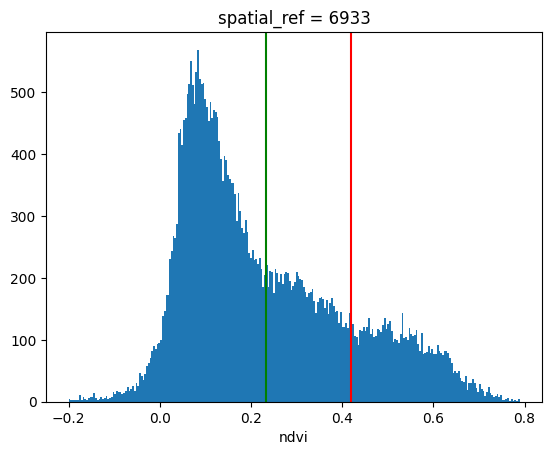

In [183]:
#check that the algorithm is not sensitive to offset and scale - all good!
inst = 'tm'
lower_cut_fai = -0.1
lower_cut_ndvi = -0.2
fai = False
ndvi = not fai
ndvidata = np.asarray(ds.where(ds.qa_score > 0).where(ds.ndvi> lower_cut_ndvi).where(ds[inst]).ndvi).reshape(ds.x.size * ds.y.size * ds.time.size)
faidata  = np.asarray(ds.where(ds.qa_score > 0).where(ds.fai > lower_cut_fai).where(ds[inst]).fai ).reshape(ds.x.size * ds.y.size * ds.time.size)
ndvidata = ndvidata[~np.isnan(ndvidata)]
faidata  = faidata[~np.isnan(faidata)]
print('ndvi otsu and mean: ',otsu(ndvidata,512),np.mean(ndvidata))
print('fai  otsu and mean: ',otsu(faidata,512), np.mean(faidata))
print('dataset mean for ndvi, fai: ',
      (ds.where(ds.qa_score>0).where(ds.ndvi>-1).where(ds[inst])).ndvi.mean().item(),
      (ds.where(ds.qa_score>0).where(ds.fai>-1) .where(ds[inst])).fai .mean().item()
     )

#np.histogram(data)
#plt.hist(data,bins=500)
#xr.plot.hist(ds.where(ds.ndvi>-1  ).where(ds[inst]).ndvi,bins=256)
if fai:
    xr.plot.hist(ds.where(ds.fai > lower_cut_fai).where(ds[inst]).fai,bins=256)
    #plt.axvline(otsu(np.asarray(faidata),512),color='r')
    left = faidata[faidata<np.mean(faidata)]
if ndvi:
    xr.plot.hist(ds.where(ds.ndvi > lower_cut_ndvi).where(ds[inst]).ndvi,bins=256)
    #plt.axvline(otsu(np.asarray(ndvidata),512),color='r')
    left = ndvidata[ndvidata<np.mean(ndvidata)]
right = left * -1
both  = np.array([left,right]).reshape(2 * np.size(left))
cutoff = np.var(both)**0.5 * 2
print(cutoff,np.mean(both),np.mean(ndvidata[ndvidata>cutoff])) 
plt.axvline(cutoff,color='g')
plt.axvline(np.mean(ndvidata[ndvidata>cutoff]),color='r')

plt.show()

#### Finding a natural threshold to cut the FAI and NDVI. 
1. assume that there is noise around the mean (~zero value) and that the noise is symmetric about the mean
2. reflect the left half of that distribution through the mean and model as gaussian, i.e, take the variance.
3. set a threshold at 2sigma above the mean; discard values below that threshold as not significant.
4. the threshold will differ for each sensor

**Then:**

5.  use the overall mean values (per sensor) to adjust tm and msi to the oli values (or some other way)
initial experimentation finds :

**FAI:**

 `instrument threshold        mean overall value above threshold (observed)`
- `msi  0.027948091730305314  0.09706884994492773 `
- `oli  0.03700594089635879   0.10152865645460406`
- `tm   0.05294067859852353   0.09626936881950525`

**NDVI:**

- `msi 0.06417626689906246 0.3268506413577676`                      -- this corresponds best to the observed local minimum.
- `oli 0.0575998312383445  0.3304715643505414`                      -- this cutoff looked natural to me when working with the data, perhaps a bit inclusive
- `tm  0.08210079534199263 0.2788954907387175`                       -- this may need some further experimentation`


In [27]:
# Analysis
for measure in ('fai','ndvi'):
    for inst in ('msi','oli','tm'):
        print(inst,measure,'overall mean : ',ds.where(ds.qa_score>0).where(ds[measure]>-1).where(ds[inst])[measure].mean().item())
        print('inst, msr, lower bound, mean (truncated), cutoff, residual mean : ',ds.where(ds.qa_score>0).where(ds[measure]>-1).where(ds[inst])[measure].mean().item())
        for lower_cut  in (-0.05,-0.1,-0.2,-0.3,-0.4):
            data    = np.asarray(ds.where(ds.qa_score > 0).where(ds[measure]> lower_cut).where(ds[inst])[measure]).reshape(ds.x.size * ds.y.size * ds.time.size)
            data   = data[~np.isnan(data)]
            overallmean = ds.where(ds.qa_score>0).where(ds[measure]>-1).where(ds[inst])[measure].mean().item(),
            if measure == 'fai' :
                left   = data[data < np.mean(data)]
                right  = left * -1
                both   = np.array([left,right]).reshape(2 * np.size(left))
                cutoff = np.mean(data) + np.var(both)**0.5 * 2 
                print(inst,measure,lower_cut,np.mean(data),cutoff,np.mean(data[data>cutoff]))
            if measure == 'ndvi':
                left   = data[data <             0]
                right  = left * -1
                both   = np.array([left,right]).reshape(2 * np.size(left))
                cutoff = 0             + np.var(both)**0.5 * 2 
                print(inst,measure,lower_cut,np.mean(data),cutoff,np.mean(data[data>cutoff])) 

msi fai overall mean :  0.01708810761009577
inst, msr, lower bound, mean (truncated), cutoff, residual mean :  0.01708810761009577
msi fai -0.05 0.017139699814545346 0.0302164777978427 0.1503635821188992
msi fai -0.1 0.01709225751469287 0.03061899029294317 0.15119131836792302
msi fai -0.2 0.017088107610095916 0.03068442115345965 0.15129032123489503
msi fai -0.3 0.017088107610095916 0.03068442115345965 0.15129032123489503
msi fai -0.4 0.017088107610095916 0.03068442115345965 0.15129032123489503
oli fai overall mean :  0.015074766892407103
inst, msr, lower bound, mean (truncated), cutoff, residual mean :  0.015074766892407103
oli fai -0.05 0.015074766892407101 0.02354365675204221 0.14012432113689993
oli fai -0.1 0.015074766892407101 0.02354365675204221 0.14012432113689993
oli fai -0.2 0.015074766892407101 0.02354365675204221 0.14012432113689993
oli fai -0.3 0.015074766892407101 0.02354365675204221 0.14012432113689993
oli fai -0.4 0.015074766892407101 0.02354365675204221 0.140124321136899

ndvi otsu and mean:  0.285940168260074 0.21821218001647322
fai  otsu and mean:  0.06048137207031252 0.026892533904715812
dataset mean for ndvi, fai:  0.21760942177953993 0.026892533904715587
0.23322874304124047 5.702590174639648e-18 nan


/opt/venv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_197922/3617554379.py:34: RuntimeWarning: Mean of empty slice
  plt.axvline(np.nanmean(all[all>cutoff]),color='r')


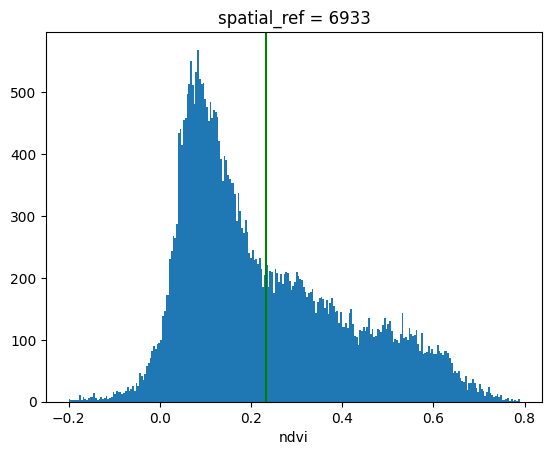

In [ ]:
#RESULTS:
# this is preliminary; might need to re-work if the input data change, e.g., using R corrected data (which should not be necessary)

# full results below. The method for FAI is slightly different. For NDVI I assume zero. For FSI I work from the dataset mean (after truncating which has no effect) because there is a slight positive value.

msi fai overall mean :  0.012105979369991178
inst, msr, lower bound, mean (truncated), cutoff, residual mean :  0.012105979369991178
msi fai -0.05 0.012191860521907991 0.027948091730305314 0.09706884994492773                    --- all negative values are included by here.
msi fai -0.1 0.012105979369991278 0.028523931937998855 0.09795234574064664
msi fai -0.2 0.012105979369991278 0.028523931937998855 0.09795234574064664
msi fai -0.3 0.012105979369991278 0.028523931937998855 0.09795234574064664
msi fai -0.4 0.012105979369991278 0.028523931937998855 0.09795234574064664
oli fai overall mean :  0.020816970702784304
inst, msr, lower bound, mean (truncated), cutoff, residual mean :  0.020816970702784304
oli fai -0.05 0.02081697070278446 0.03700594089635879 0.10152865645460406
oli fai -0.1 0.02081697070278446 0.03700594089635879 0.10152865645460406
oli fai -0.2 0.02081697070278446 0.03700594089635879 0.10152865645460406
oli fai -0.3 0.02081697070278446 0.03700594089635879 0.10152865645460406
oli fai -0.4 0.02081697070278446 0.03700594089635879 0.10152865645460406
tm fai overall mean :  0.026892533904715587
inst, msr, lower bound, mean (truncated), cutoff, residual mean :  0.026892533904715587
tm fai -0.05 0.026892533904715812 0.05294067859852353 0.09626936881950525
tm fai -0.1 0.026892533904715812 0.05294067859852353 0.09626936881950525
tm fai -0.2 0.026892533904715812 0.05294067859852353 0.09626936881950525
tm fai -0.3 0.026892533904715812 0.05294067859852353 0.09626936881950525
tm fai -0.4 0.026892533904715812 0.05294067859852353 0.09626936881950525
msi ndvi overall mean :  0.006248832028445583
inst, msr, lower bound, mean (truncated), cutoff, residual mean :  0.006248832028445583
msi ndvi -0.05 0.21237697423180132 0.06417626689906246 0.3268506413577676                      -- this corresponds best to the observed local minimum.
msi ndvi -0.1 0.16046036199075606 0.11697407248653276 0.3789620347748565
msi ndvi -0.2 0.09869348385160025 0.2130007037574934 0.46747070429835896
msi ndvi -0.3 0.05966392588342217 0.2947467336276085 0.5229066114245087
msi ndvi -0.4 0.03957855904489346 0.34852097725951814 0.5562223095754881
oli ndvi overall mean :  0.1927344933438642
inst, msr, lower bound, mean (truncated), cutoff, residual mean :  0.1927344933438642
oli ndvi -0.05 0.23886144593181127 0.0575998312383445 0.3304715643505414                      -- this cutoff looked natural to me when working with the data, perhaps a bit inclusive
oli ndvi -0.1 0.21286675042189687 0.10316426034290946 0.37075946679865424                      
oli ndvi -0.2 0.1929953523832525 0.15103861113211836 0.40953488424436996
oli ndvi -0.3 0.19273449334386428 0.152398555858341 0.4107678767292981
oli ndvi -0.4 0.19273449334386428 0.152398555858341 0.4107678767292981
tm ndvi overall mean :  0.21760942177953993
inst, msr, lower bound, mean (truncated), cutoff, residual mean :  0.21760942177953993
tm ndvi -0.05 0.2219779725077434 0.048456123089290426 0.2484267419441686
tm ndvi -0.1 0.21985495943937142 0.08210079534199263 0.2788954907387175                       -- perhaps there is rationale for a higher cutoff with TM data  - higher variance
tm ndvi -0.2 0.21821218001647322 0.1278757164834588 0.327210511769253
tm ndvi -0.3 0.2176094217795405 0.15273590881775892 0.3521414505357127
tm ndvi -0.4 0.2176094217795405 0.15273590881775892 0.3521414505357127

In [105]:
left = faidata[faidata<0]
right = left * -1
all = np.array([left,right]).reshape(2 * np.size(left))
np.var(all)**0.5 * 2

0.025191741283764117

In [ ]:
#plot fai and ndvi through time
from  skimage import filters
for t in ds.time:
    fai = np.asarray(ds.sel(time=t).fai).reshape(ds.x.size*ds.y.size)
    print(filters.threshold_otsu(fai[~np.isnan(fai)]))

In [96]:
for t in ds.time:
    fai_array = ds.sel(time=t)
    test = test[~np.isnan(test)]
    print(filters.threshold_otsu(test))

IndexError: 2-dimensional boolean indexing is not supported. 

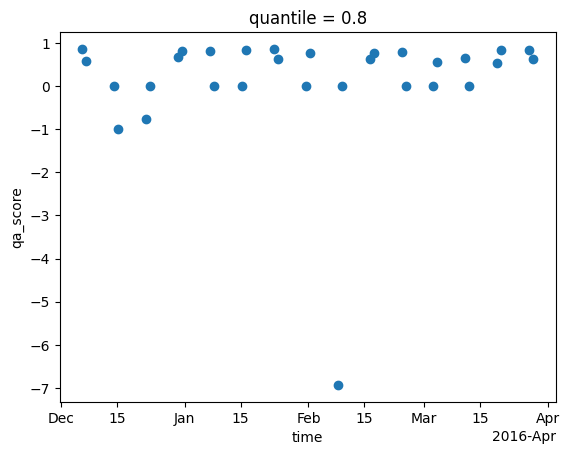

In [140]:
ds.qa_score.quantile(0.8,dim=('x','y')).plot(linestyle  = '',marker='o')

In [ ]:
ds.data_vars


#### Histogram match NDVI values and filter outliers

In [82]:
# --- a function to match histograms --- 'cpf' = cumulative probability function
#     this seems to work well;
#     notice that have to use the xr.qantile method, rather than the np.quantile() function which does not manage the nans!

#     To avoid replicating values it can be necessary for the number of bins to be only 5. A robust work-arond is needed
#    

def cpf_match(source_data,target_data,bins=11,method='quadratic') :
    Q = np.linspace(0,1,bins)         # --- array of quantiles, call it Q. Exclude extreme tails which can be out of range if there are data problems

    # --- calculate the quantiles (CPDs) for the source data and target data
    X = source_data.quantile(Q,skipna= True)
    Y = target_data.quantile(Q,skipna= True)

    # --- fit a model to X; ie Q = f(x)
    f = sp.interpolate.interp1d(X,Q,kind=method,fill_value='extrapolate')
    # --- fit an inverse model to Y; ie Y = g(Q)
    g = sp.interpolate.interp1d(Q,Y,kind=method,fill_value='extrapolate')
    # --- new values are given by g(f(x)), which is very cool 
    
    return xr.DataArray(g(f(source_data)),dims=source_data.dims)
    

In [141]:
# --- Carry out a two-step process of histogram matching over the dataset area.
#     Note that simple regression methods from Francesca Trevisiol et al IEEE TRANSACTIONS ON GEOSCIENCE AND REMOTE SENSING, VOL. 62, 2024
#      don't seem to work here. 
#     Histogram matching methods are inherently local; its only valid to match if the samples have observed the same domain.
#     Modifications are needed to check that there are resonable numbers of observations from each sensor before matching. 

# --- Two step process to leverage the temporal overlaps, first adjust oli to msi, then tm to oli and msi :
# --- further, run the process twice; the first removes extreme values and the second time matches only the positive values
for i in [1,2]:
 
    if 'msi' in ds.data_vars and 'oli' in ds.data_vars : 
    
        # --- first step, harmonise oli to msi, if the latter are available --- 
        ds['ndvi'] = xr.where(ds.oli,
                          cpf_match(ds.ndvi.where(ds.oli,),ds.ndvi.where(ds.msi)),
                          ds.ndvi)

    # --- repeat the process to harmonise the tm data to the adjusted oli data --- 
    if 'tm' in ds.data_vars and 'oli' in ds.data_vars :
        ds['ndvi'] = xr.where(ds.tm,
                          cpf_match(ds.ndvi.where(ds.tm),ds.ndvi.where(ds.oli)),
                          ds.ndvi)

    #--- deal with artefacts of ndvi > 1 ---
    ds['ndvi'] = xr.where(ds.ndvi>1,np.nan,
                      xr.where(ds.ndvi<-1,np.nan,
                               ds.ndvi))

    # --- limit the newly adjusted ndvi data to values above zero ---
    ds['ndvi'] = xr.where(ds.ndvi > 0,ds.ndvi,np.nan)
    

In [ ]:

# --- extract the proporion of the area with ndvi > threshold, indicative of floating photosynthetic material, fpm ---
fpm_threshold = 0.05   # results are not very sensitive to this parameter.... 
fpm_threshold = 0.1   # results are not very sensitive to this parameter.... 

ds['fpm_percent'] = 100 * ds.ndvi.where(ds.ndvi > fpm_threshold,np.nan).count(dim=('x','y')) / ds.ndvi_total_count
# done

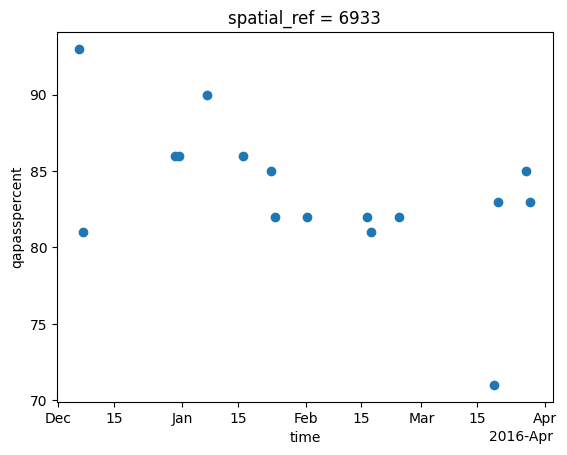

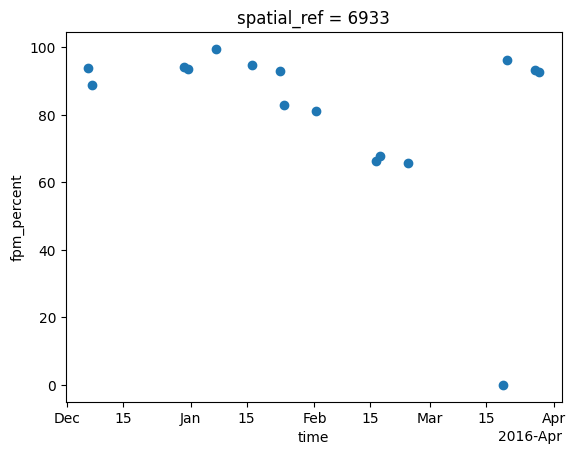

In [137]:
ds.where(ds.qapasspercent>60).qapasspercent.plot(linestyle='',marker='o')
plt.show()
ds.where(ds.qapasspercent>60).fpm_percent.plot(linestyle='',marker='o')
plt.show()
#ds.time.values

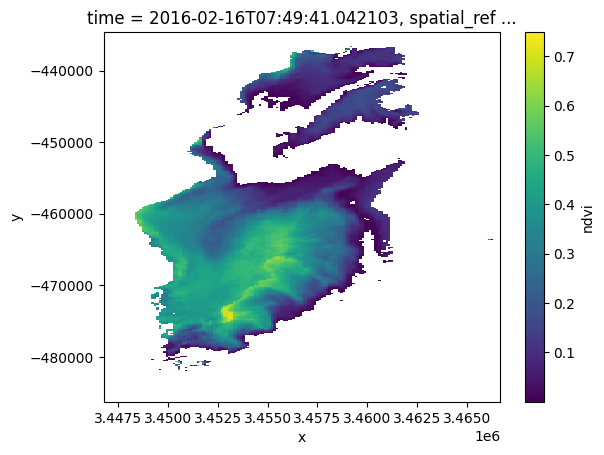

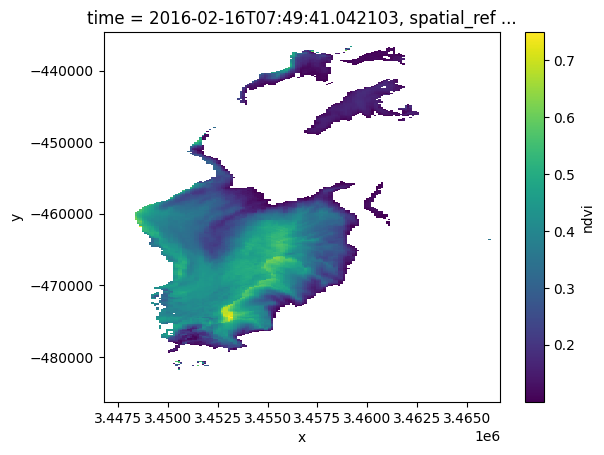

In [143]:
i = i + 1
i = 18
ds.where(ds.ndvi > -1).isel(time=i).ndvi.plot()
plt.show()
ds.where(ds.ndvi > .1).isel(time=i).ndvi.plot()




In [ ]:
ds_annual

#### Run the algorithms - This time for the geomedian dataset

In [118]:
# ---- Apply the WQ algorithms to water areas, adding variables to the dataset and building a list of water quality variable nanmes
# -- this can be run either keeping the wq variables as separate variables on the dataset, or by moving them into new dimensions, 'tss' and 'chla'
# -- If the arguments 'new_dimension_name' or 'new_varname' are None (or empty), then the outputs will be retained as separate variables in a 3d dataset

if True: #put the data into a new dimension, call the variable 'tss' or 'chla'
    ds_annual,tsm_vlist  = WQ_vars(ds_annual.where(ds_annual.wofs_ann_freq >= water_frequency_threshold_low),
                        algorithms_tsm,  
                        instruments_agm, 
                        new_dimension_name='tss_measure', 
                        new_varname='tss', 
                        verbose=verbose)
    
    ds_annual,chla_vlist = WQ_vars(ds_annual.where(ds_annual.wofs_ann_freq >= water_frequency_threshold_low),
                        algorithms_chla, 
                        instruments_agm, 
                        new_dimension_name='chla_measure', 
                        new_varname='chla',
                        verbose=verbose)

else:  #keep it simple, just add new data as new variables in a 3-D dataset  --- this might need debugging!
    ds_annual,tsm_vlist  = WQ_vars(ds_annual.where(ds_annual.wofs_ann_freq >= water_frequency_threshold_low),
                        algorithms_tsm,  
                        instruments_agm, 
                        new_dimension_name=None, 
                        new_varname=None, 
                        verbose=verbose)
    ds_annual,chla_vlist = WQ_vars(ds_annual.where(ds_annual.wofs_ann_freq >= water_frequency_threshold_low),
                        algorithms_chla, 
                        instruments_agm, 
                        new_dimension_name=None, 
                        new_varname=None,
                        verbose=verbose)

wq_varlist = np.append(tsm_vlist,chla_vlist)


In [ ]:
ds_annual

#### Patch up the time-domain variables that were inadvertently expanded to x,y at some point

In [121]:
# ---- percentiles are calculated relative to the number of valid pixels which differes with time because the number of pixels considered valid changes.
ds['ndvi_total_count'] = ds.qa_score.where(np.logical_or(ds['qa_score']>0,~np.isnan(ds['ndvi']))).count(dim=('x','y'))   
ds['qa_percent']       = ((xr.where(ds.qa_score>0,1,np.nan).count(dim=('x','y')) * 100) / water_pixel_count).astype('int')
ds['fpm_percent']      = ds['ndvi'].where(ds.ndvi > fpm_threshold).count(dim=('x','y')) / ds['ndvi_total_count']


### Save the dataset to a file

In [122]:
#export the dataset as an input for the next step:
ds.to_netcdf(dataset_filename)
ds_annual.to_netcdf(dataset_agm_filename)

In [7]:
t = 0

In [9]:
t = t + 1
print(t)
plt.figure(figsize=(4,5))
if ds.isel(time=t).oli:
    inst = 'oli'
if ds.isel(time=t).tm:
    inst = 'tm'
if inst == 'tm' : 
    list = ['ndssi_rg_tm' ,'ti_yu_tm' ,'tsm_lym_tm' ,'spm_qiu_tm' ,'ndci_tm43' ,'chla_modis2b_tm','ndvi']
if inst == 'oli': 
    list = ['ndssi_rg_oli','ti_yu_oli','tsm_lym_oli','spm_qiu_oli','ndci_oli54','ndssi_bnir_oli','tss_zhang_oli','ndvi']
i = 1
for varname in list:
    ds.isel(time=t)[varname].plot(robust=False)
    plt.show()

2


NameError: name 'ds' is not defined

<Figure size 400x500 with 0 Axes>


### Normalise the WQ measures


#### Read in the dataset and parameters

In [10]:
def read_dataset_and_parameters(filename,wq_normalisation_parameters_filename):
    ds   = xr.open_dataset(filename).load(); ds.close()
    with open(wq_normalisation_parameters_filename) as f:
      np_data_dict = json.load(f)
    return(ds,np_data_dict)

In [11]:
# --- A Function to normalise the WQ measures ---

def normalise_water_quality_measures(ds0,np_data_dict,water_frequency_threshold=0,verbose=True,test=False):
    if test or verbose : print('Applying scale and offset to wq variables..')

    ds = ds0.copy(deep=True)   #without this the ds values do change outside of the function

    #run through all the wq measures; ds should have a dimension called 'tss_measure' and another called 'chla_measure'. 
    for mmt_type in ['tss','chla'] :
        for mmt in list(ds[mmt_type+'_measure']) :
            measurement = str(mmt.values)
            scale  = np_data_dict[measurement]['scale']
            offset = np_data_dict[measurement]['offset']
            ds[mmt_type].loc[:,:,:,measurement] = ds[mmt_type].loc[:,:,:,measurement] * scale + offset
    
    #take the median of the tss and chla measurements from now on:
    water_frequency_threshold=0
    tss_index_list  = ds.tss_measure   # --- which tss measures to include; in practice this include them all  ----
    ds['tss_agm_med' ] = xr.where(ds.wofs_ann_freq>water_frequency_threshold,
                                  ds.tss.loc[:,:,:,tss_index_list].median(dim=('tss_measure')),np.nan)

    chla_index_list = ds.chla_measure  # --- which chla measures to include; by default, include them all ----
    ds['chla_agm_med'] = xr.where(ds.wofs_ann_freq>water_frequency_threshold,
                                  ds.chla.loc[:,:,:,chla_index_list].median(dim=('chla_measure')),np.nan)

    #drop excess material
    if False:
        ds = ds.drop_vars(('tss','chla'))
    return ds

In [12]:
# --- Run for the geomedian - important to run these together; don't want to run the normalisation process twice on the same data! ---

ds_annual,np_data_dict = read_dataset_and_parameters(dataset_agm_filename,wq_normalisation_parameters_filename)
ds_annual = normalise_water_quality_measures(ds_annual,np_data_dict,water_frequency_threshold = 0.5,verbose=verbose,test=test)


Applying scale and offset to wq variables..


In [13]:
# --- important to run these together; don't want to run the normalisation process twice on the same data! ---

ds,np_data_dict_sansagm = read_dataset_and_parameters(dataset_filename,wq_normalisation_parameters_filename)

p_data_dict_sansagm = {}
for alg in np_data_dict.keys():
    alg_short = alg[:alg.find('_agm')]
    np_data_dict_sansagm[alg_short] = np_data_dict[alg]     
    
ds = normalise_water_quality_measures(ds,np_data_dict_sansagm,water_frequency_threshold = 0.5,verbose=verbose,test=test)


Applying scale and offset to wq variables..


#### bring in a water test - but this is not effective for some reason (large areas <0), so don't use it.


In [16]:
ds['ndwi_oli'] = (ds.oli04-ds.oli05)/(ds.oli04 + ds.oli05)
ds['ndwi_tm' ] = (ds.tm02 - ds.tm04 )/(ds.tm02  + ds.tm04 )
ds['ndwi']     = xr.where(~np.isnan(ds.ndwi_oli),ds.ndwi_oli,ds.ndwi_tm)
#ds['ndwi_msi'] = (ds.msi03 - ds.msi8a) / (ds.msi03 + ds.msi8a)

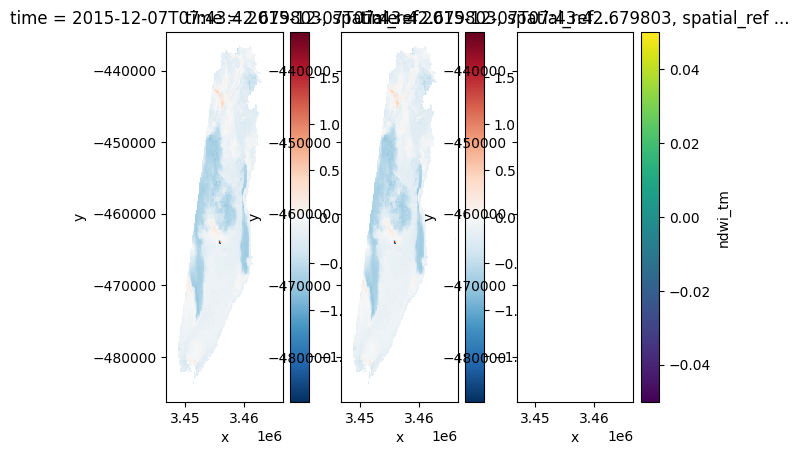

In [17]:
t = 0
t = t + 1
plt.subplot(1,3,1)
ds.isel(time=t).ndwi.plot()
plt.subplot(1,3,2)
ds.isel(time=t).ndwi_oli.plot()
plt.subplot(1,3,3)
ds.isel(time=t).ndwi_tm.plot()

    

In [12]:
ds.tss_measure

<xarray.DataArray 'tss_measure' (tss_measure: 10)> Size: 560B
array(['ndssi_rg_oli', 'ndssi_rg_tm', 'ndssi_bnir_oli', 'ti_yu_oli',
       'ti_yu_tm', 'tsm_lym_oli', 'tsm_lym_tm', 'tss_zhang_oli', 'spm_qiu_oli',
       'spm_qiu_tm'], dtype='<U14')
Coordinates:
    spatial_ref  int32 4B 6933
  * tss_measure  (tss_measure) <U14 560B 'ndssi_rg_oli' ... 'spm_qiu_tm'

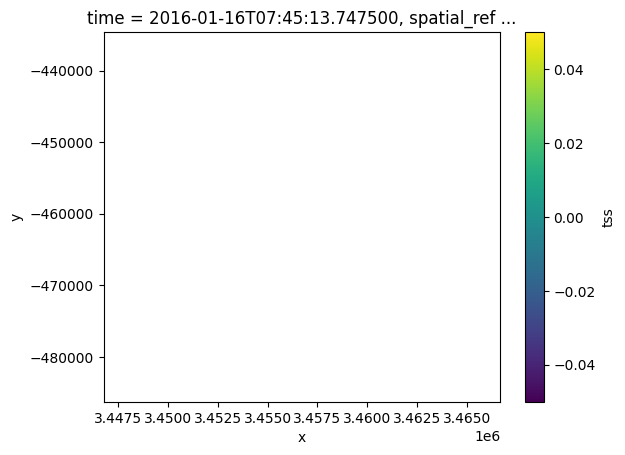

In [202]:
ds.where(ds.qa_score>0).tss.loc[{'tss_measure' : 'tsm_lym_oli'}].isel(time=t).plot()

#### Some derived variables to simplify the plotting process 

In [21]:
# going one step further here; pull out each tss variable, calibrate it to the lymburner distribution, take the median
ds['refvar'] = ds.where(ds.qa_score > 0).tss.loc[{'tss_measure' : 'tsm_lym_oli'}]
i = 0
Q = .8
for tssvar in ds.tss_measure[:] :
    
    # pull out values as a new variable
    ds['tempvar'] = ds.where(ds.qa_score > 0).tss.loc[{'tss_measure' : tssvar}]
    # match that variable to the target (lymburner) distribution
    ds['tempvar'] = cpf_match(ds.tempvar,ds.refvar,5)
    # push it back to the source variable space
    if not tssvar == 'tsm_lym_oli':
        ds.tss.loc[{'tss_measure' : tssvar}] = ds.tempvar
        print('updating ',tssvar.item())




updating  ndssi_rg_oli
updating  ndssi_rg_tm
updating  ndssi_bnir_oli
updating  ti_yu_oli
updating  ti_yu_tm
updating  tsm_lym_tm
updating  tss_zhang_oli


/opt/venv/lib/python3.12/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


updating  spm_qiu_oli
updating  spm_qiu_tm


/opt/venv/lib/python3.12/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


0 ndssi_rg_oli


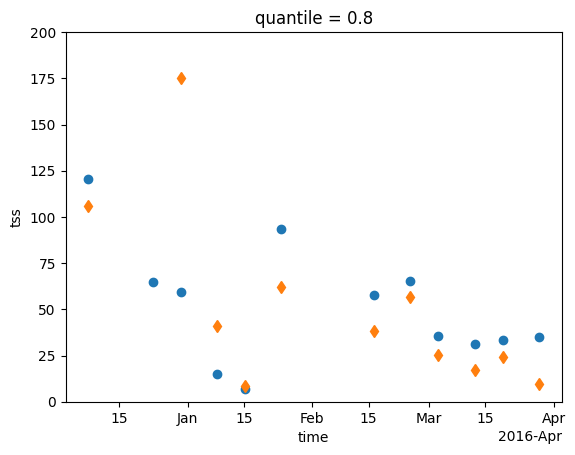

In [65]:
i = -1
i = i +1 

if i < ds.tss_measure.size:
    tssvar  = ds.tss_measure[i].item()
    print(i,tssvar)
    
    ds.where(ds.qa_score>0).tss.loc[{'tss_measure' : 'tsm_lym_oli'}].quantile(Q,dim=('x','y')).plot(marker = 'o',linestyle = '',ylim=(0,200))
#    ds['tss_lym_oli'].quantile(Q,dim=('x','y')).plot(marker = 'x',linestyle = '',color = 'k',ylim=(0,200))
    ds.where(ds.qa_score>0).tss.loc[{'tss_measure' : tssvar}].quantile(Q,dim=('x','y')).plot(marker = 'd',linestyle = '',ylim=(0,200))
    

In [ ]:
ds.tempvar.quantile(Q,dim=('x','y')).plot(marker = 'o',linestyle = '',ylim=(0,200))
ds.refvar.quantile(Q,dim=('x','y')).plot(marker = 'x',linestyle = '',color = 'k',ylim=(0,200))
ds.where(ds.qa_score>0).tss.loc[{'tss_measure' : tssvar}].quantile(Q,dim=('x','y')).plot(marker = 'd',linestyle = '',ylim=(0,200))
i = i + 1
print(tssvar.item(),'tsm_lym_oli',tssvar.item())

In [ ]:
# capture the median value of tss as a variable to simplify future work...
ds['tss_median']            = ds.where(ds.qa_score>0)       .tss.median(dim=('tss_measure'))
ds_annual['tss_agm_median'] = ds_annual.tss.median(dim=('tss_measure')).isel(time=1)

ds['tss_excess'] = ds.tss_median.where(ds.tss_median > ds_annual.tss_agm_median) - ds_annual.tss_agm_median

In [176]:
(ds.lym + 35.1 - ds_annual.tss_agm_median).quantile(.5,dim=('x','y'))

<xarray.DataArray (time: 24)> Size: 192B
array([ 0.26103407, 10.75413415, -0.63003275,  3.00717317, -1.41420258,
       -6.67835658, -5.63744713, -7.778738  , -4.04144488,  0.49081356,
        1.12350316,  6.99861018,  3.28926277,  0.87057734,  2.90172865,
        1.62408231, -1.99528972, -1.09788183,  4.06287482, -2.90542132,
        0.09298646, -2.49635864, 10.75755893,  4.05491538])
Coordinates:
  * time      (time) datetime64[ns] 192B 2015-12-06T07:50:46.715176 ... 2016-...
    quantile  float64 8B 0.5

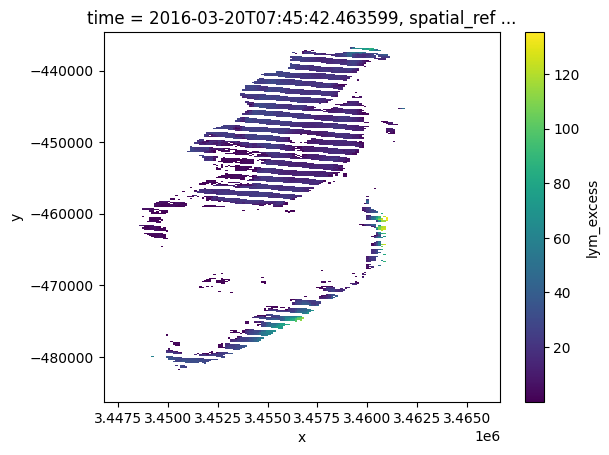

In [201]:
#t = 0
t = t + 1
ds.lym_excess.isel(time=t).plot()

In [97]:
%run /home/jovyan/AdamsWork/_AL_functions.ipynb

Loading AL_functions


In [99]:
ds.time.astype('float')

<xarray.DataArray 'time' (time: 24)> Size: 192B
array([1.44938825e+18, 1.44947422e+18, 1.45085662e+18, 1.45146179e+18,
       1.45154790e+18, 1.45215308e+18, 1.45223902e+18, 1.45284419e+18,
       1.45293031e+18, 1.45353549e+18, 1.45362142e+18, 1.45431272e+18,
       1.45560898e+18, 1.45569513e+18, 1.45630030e+18, 1.45638621e+18,
       1.45699138e+18, 1.45707753e+18, 1.45768271e+18, 1.45776861e+18,
       1.45837377e+18, 1.45845994e+18, 1.45906511e+18, 1.45915100e+18])
Coordinates:
  * time         (time) datetime64[ns] 192B 2015-12-06T07:50:46.715176 ... 20...
    spatial_ref  int32 4B 6933

In [104]:
piecewise_linreg(ds.time.astype('float'),means,keepnans=True,test=False)[0][1]

array([108.073, 108.08 , 127.734, 116.118,  98.282, 117.437, 146.435,
       134.781,  95.285,  71.041,  64.827,  57.821,  50.883,  44.283,
        39.332,  56.348,  71.043,  52.794,  50.876,  85.195,  85.64 ,
        38.864,  18.179,  18.18 ])

In [126]:
means.mean()

<xarray.DataArray 'tss_excess' ()> Size: 8B
array(77.17546667)
Coordinates:
    spatial_ref  int32 4B 6933

In [250]:
for i in np.arange(0,ds.time.size):
    print(i, ds.time[i].values,lym[i].values,ds.lym_excess.mean(dim=('x','y'))[i].values)

0 2015-12-06T07:50:46.715176000 54.41800148459096 54.41800148459096
1 2015-12-07T07:43:42.679803000 77.3319821553746 77.3319821553746
2 2015-12-23T07:43:43.494509000 58.32205309198826 58.32205309198826
3 2015-12-30T07:49:52.823376000 46.767687227911104 46.767687227911104
4 2015-12-31T07:44:58.398838000 48.747003674383215 48.747003674383215
5 2016-01-07T07:51:16.617310000 45.37818146883876 45.37818146883876
6 2016-01-08T07:43:38.668061000 33.54633450937599 33.54633450937599
7 2016-01-15T07:49:50.839894000 26.369649195794878 26.369649195794878
8 2016-01-16T07:45:13.747500000 22.893534868214935 22.893534868214935
9 2016-01-23T07:51:29.503810000 41.955714710490476 41.955714710490476
10 2016-01-24T07:43:39.921891000 59.744399750792546 59.744399750792546
11 2016-02-01T07:45:23.506272000 52.01385777413965 52.01385777413965
12 2016-02-16T07:49:41.042103000 42.04853071354155 42.04853071354155
13 2016-02-17T07:45:27.599780000 44.93310111478829 44.93310111478829
14 2016-02-24T07:51:38.430596000 3

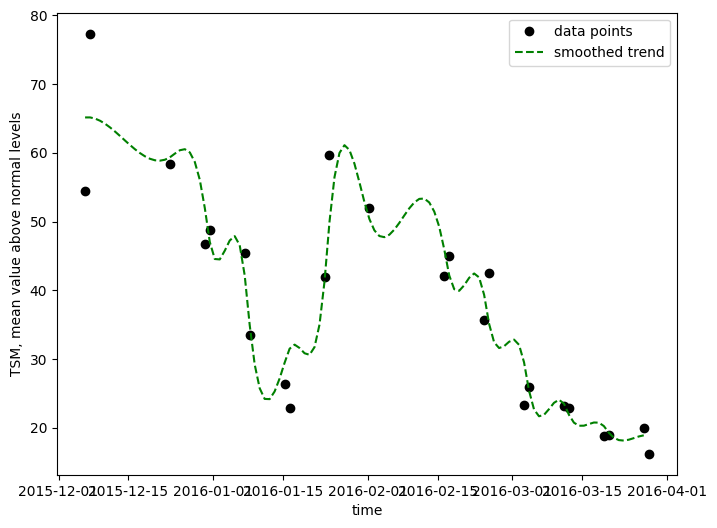

In [236]:
# use the lymburner TSI algorithm for now because it produces consistent results. 

ds['lym']        = ds.where(ds.qa_score>0).tss.loc[{'tss_measure' : ['tsm_lym_oli','tsm_lym_tm']}].median(dim=('tss_measure'))

# 35.1 is the bias between the annual geomedian values and the median values observed here using the lymburner model
ds['lym_excess'] = ds.where(ds.qa_score>0).where(ds.lym + 35.1 > ds_annual.tss_agm_median).lym - ds_annual.tss_agm_median + 35.1

# pull out into a simple array, smooth a couple of times and fit a quadratic spline
lym = ds.where(ds.qa_score>0).lym_excess.mean(dim=('x','y'))
slym = piecewise_linreg(ds.time.astype('float'),lym,keepnans=True,test=False)[0][1]
sslym = piecewise_linreg(ds.time.astype('float'),slym,keepnans=True,test=False)[0][1]

smoothed = sp.interpolate.interp1d(ds.time,sslym,kind='cubic',fill_value='extrapolate')
t_new    = pd.date_range(ds.time.min().values, ds.time.max().values, freq='1D')

plt.figure(figsize=[8,6])
plt.subplot(1,1,1)

plt.xlabel('time')
plt.ylabel('TSM, mean value above normal levels')

plt.plot(ds.time,lym,'k',linestyle="", marker="o",label='Data Points')  
#plt.plot(ds.time,slym,'b',linestyle="", marker="o",label='LYM TSI excess')  
plt.plot(t_new,smoothed(t_new),'g',linestyle="--", marker="",label='LYM TSI excess')  




plt.legend(['data points','smoothed trend'])

#plt.plot(ts_ndvi_tm.time,ts_ndvi_tm,)  



plt.show()

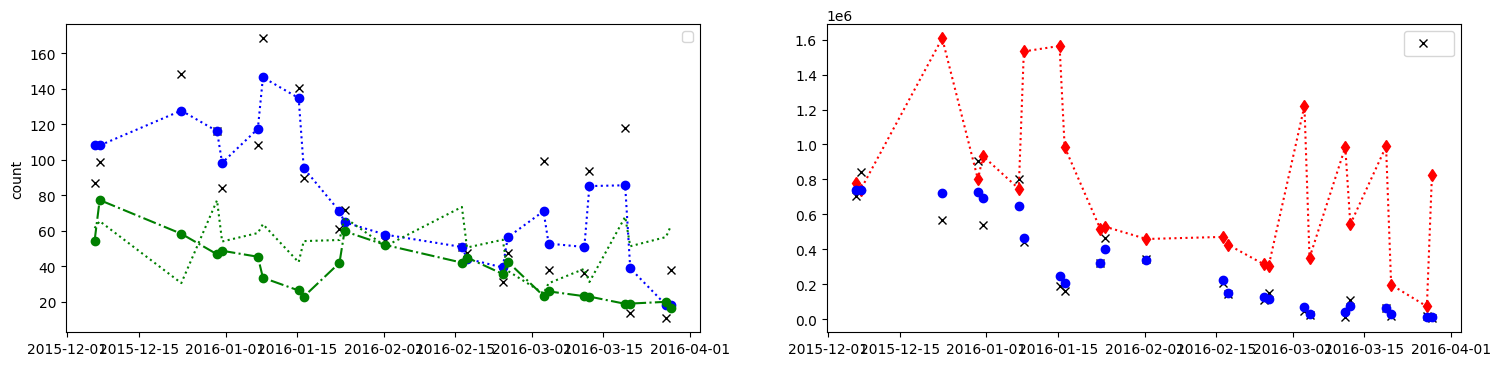

In [202]:
excess_counts  = ds.where(ds.qa_score>0).where(ds.tss_median > ds_annual.tss_agm_median).tss_median.count(dim=('x','y'))
clear_counts   = ds.where(ds.qa_score>0).tss_median.count(dim=('x','y'))
maxclearcounts = clear_counts.max()
area_excess    = excess_counts/clear_counts  * maxclearcounts
confidence     = clear_counts / maxclearcounts

means  = ds.tss_excess.mean(dim=('x','y'))
totals = ds.tss_excess.sum(dim=('x','y'))
smeans = piecewise_linreg(ds.time.astype('float'),means,keepnans=True,test=False)[0][1]
swmeans = piecewise_linreg(ds.time.astype('float'),means*confidence,keepnans=True,test=False)[0][1] / confidence
maxcount = counts.max()

#confidence = ds.where(ds.qa_score>0).where(ds.tss_median > ds_annual.tss_agm_median).tss_median.count(dim=('x','y'))

stotals = piecewise_linreg(ds.time.astype('float'),totals,keepnans=True,test=False)[0][1]
nstotals = piecewise_linreg(ds.time.astype('float'),totals,keepnans=True,test=False)[0][1]/counts * maxcount



plt.figure(figsize=[18,4])
plt.subplot(1,2,1)

plt.xlabel('')
plt.ylabel('count')
plt.legend(['number of pixels contributing to the estimate'])

plt.plot(ds.time,means,'k',linestyle="", marker="x",label='Means')  
plt.plot(ds.time,smeans,'b',linestyle=":", marker="o",label='Smoothed Means')  
plt.plot(ds.time,ds.lym_excess.mean(dim=('x','y')),'g',linestyle="-.", marker="o",label='LYM TSI excess')  
#plt.plot(ds.time,swmeans,'r',linestyle=":", marker="d",label='Smoothed Means')  
#plt.plot(ds.time,smoothfunction(ds.fpm_percent,5)(ds.time),'k',linestyle="--", marker="",label='Smoothed NDVI')  
#plt.legend(['mean excess mg/l','smoothed means','smoothed weighted means'])
plt.plot(ds.time,confidence * means.mean(),'g',linestyle =':')

plt.subplot(1,2,2)
plt.plot(ds.time,totals,'k',linestyle="", marker="x",label='total observed excess')  
plt.plot(ds.time,nstotals,'r',linestyle=":", marker="d",label='smoothed total excess normalised by count')  
plt.plot(ds.time,stotals,'b',linestyle="", marker="o",label='confidence')  



plt.legend([''])

#plt.plot(ts_ndvi_tm.time,ts_ndvi_tm,)  



plt.show()

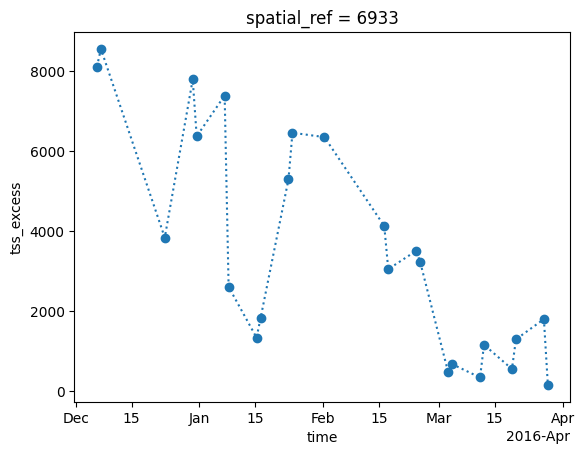

In [86]:
ds.tss_excess.count(dim=('x','y')).plot(marker = 'o',linestyle=':')

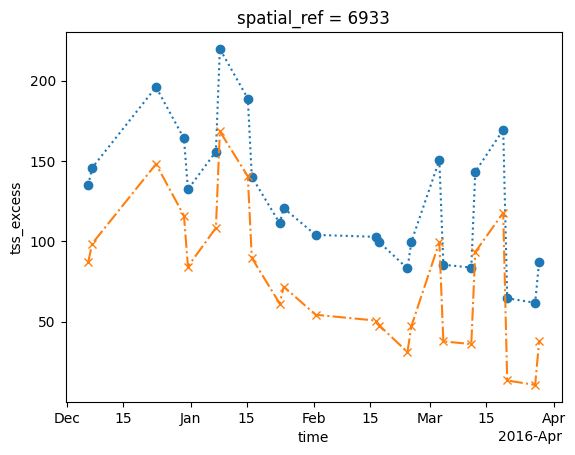

In [81]:
ds.where(ds.qa_score>0).where(ds.tss_median > ds_annual.tss_agm_median).tss_median .mean(dim=('x','y')).plot(linestyle=':',marker='o')
ds.where(ds.qa_score>0).tss_excess .mean(dim=('x','y')).plot(linestyle='-.',marker='x')



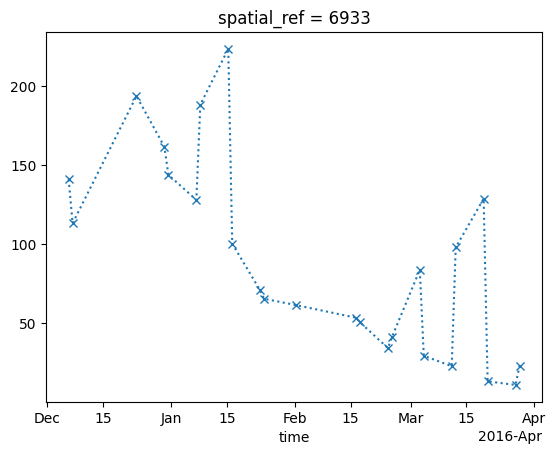

In [72]:
# restricting to the northern half of the lake gives a better response
plt.title=('tss excedences in the northern half of the lake')
(ds.where(ds.qa_score>0).tss_excess[:,300:,:] - ds_annual['tss_agm_median']).mean(dim=('x','y')) \
     .plot(linestyle=':',marker='x')

plt.show()


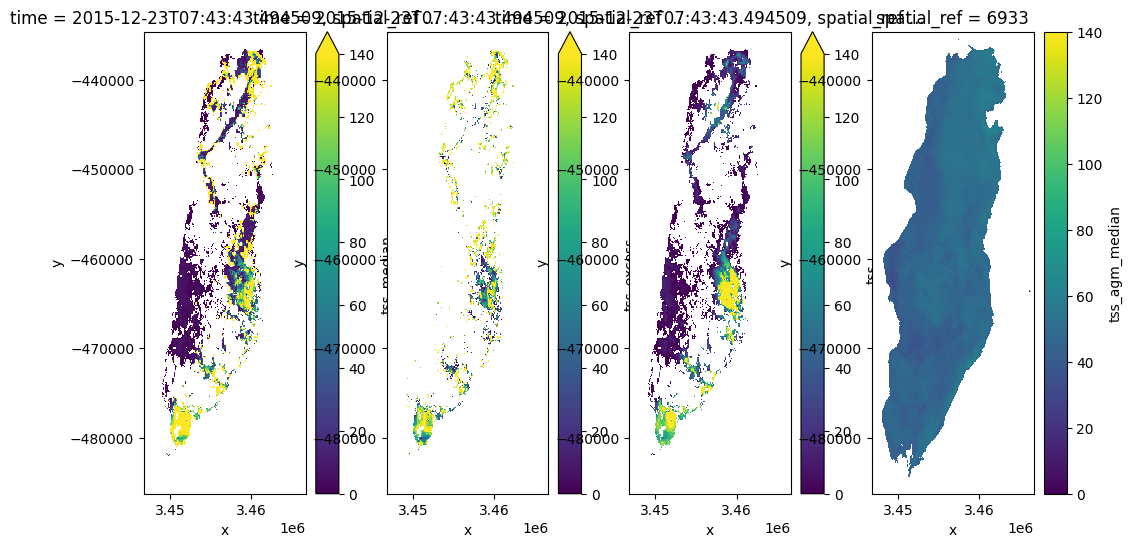

In [90]:
t = t +1
#t = 0
plt.figure(figsize=(12,6))
plt.subplot(1,4,1)
#ds.where(ds.qa_score>0).isel(time=t).tss.median(dim=('tss_measure')).plot(vmin=0,vmax = 140,robust=True)
ds.where(ds.qa_score>0).isel(time=t).tss_median.plot(vmin=0,vmax = 140,robust=True)
plt.subplot(1,4,2)
#ds.where(ds.qa_score>0).where(ds.tss_median > ds_annual.tss_agm_median).isel(time=t).tss_median.plot(vmin=0,vmax = 140,robust=True)
ds.where(ds.qa_score>0).isel(time=t).tss_excess.plot(vmin=0,vmax = 140,robust=True)
plt.subplot(1,4,3)
ds.where(ds.qa_score>0).tss.loc[{'tss_measure' : 'tsm_lym_oli'}].isel(time=t).plot(vmin=0,vmax = 140,robust=True)
plt.subplot(1,4,4)
#ds_annual.tss.median(dim=('time','tss_measure')).plot(vmin=0,vmax=140)
ds_annual.tss_agm_median.plot(vmin=0,vmax=140)


In [244]:
%run /home/jovyan/AdamsWork/_AL_functions.ipynb

Loading AL_functions


In [245]:
# --- a function to produce a smoothed timeseries graph ---
#     the data should be a single-dimenson dataarray with times

def smoothfunction(data,iterations=2):
    xy = piecewise_linreg(\
        data.time.astype('float'),\
        data,\
        keepnans=True)[0]
     
    for i in np.arange(0,iterations):
        xy = piecewise_linreg(\
            data.time.astype('float'),\
            xy[1],\
            keepnans=True)[0]

    # --- extract the valid values and fit a quadratic to them
    xlist = [] ; ylist = []
    for i in range(0,data.time.size):
        if ~np.isnan(xy[1][i]) :
             xlist.append(data.time[i].values)
             ylist.append(xy[1][i])

    xlist = np.asarray(xlist)
    ylist = np.asarray(ylist)
 
    q_interp   = sp.interpolate.interp1d(xlist,ylist,kind='quadratic',fill_value='extrapolate')
    #re-process through the smoother..
    xy = piecewise_linreg(\
        np.arange(0,data.time.size),\
        q_interp(data.time),\
        keepnans=True)[0]
    
    xlist = [] ; ylist = []
    for i in range(0,data.time.size):
        if ~np.isnan(xy[1][i]) :
             xlist.append(data.time[i].values)
             ylist.append(xy[1][i])
    xlist = np.asarray(xlist)
    ylist = np.asarray(ylist)
    return sp.interpolate.interp1d(xlist,ylist,kind='slinear',fill_value='extrapolate')

In [173]:
# make a time-series summary for the water area:
ts_ndvi_tm = ds.where(ds.tm).ndvi.mean(dim=('x','y'))
ts_ndvi_oli = ds.where(ds.oli).ndvi.mean(dim=('x','y'))
#ts_ndvi_msi = ds.where(ds.msi).ndvi.mean(dim=('x','y'))
ts_ndvi     = ds.ndvi.mean(dim=('x','y'))

In [234]:
tss_data = ds.where(ds.qa_score>0).tss.median(dim=('tss_measure','x','y'))

<xarray.DataArray 'tss' (time: 24)> Size: 192B
array([73.13248964, 47.90248981, 38.64781265, 48.16363038, 71.47167219,
       72.56756283, 38.10253846, 11.33066666, 36.82881214, 65.70080135,
       37.60550318, 75.77363794, 38.12856539, 45.46132685, 44.09911217,
       37.61302072, 24.87930519, 28.68209091, 43.23499118, 30.77161373,
       37.02688195, 48.87970975, 58.78127379, 37.78580939])
Coordinates:
  * time         (time) datetime64[ns] 192B 2015-12-06T07:50:46.715176 ... 20...
    spatial_ref  int32 4B 6933

In [268]:
ds_annual

<xarray.Dataset> Size: 31MB
Dimensions:              (time: 2, y: 430, x: 166, tss_measure: 6,
                          chla_measure: 1)
Coordinates:
  * time                 (time) datetime64[ns] 16B 2015-07-02T11:59:59.999999...
  * y                    (y) float64 3kB -4.862e+05 -4.861e+05 ... -4.347e+05
  * x                    (x) float64 1kB 3.447e+06 3.447e+06 ... 3.467e+06
    spatial_ref          int32 4B 6933
  * tss_measure          (tss_measure) <U18 432B 'ndssi_rg_oli_agm' ... 'spm_...
  * chla_measure         (chla_measure) <U14 56B 'ndci_oli54_agm'
Data variables: (12/26)
    oli02_agm            (time, y, x) float64 1MB nan nan nan ... nan nan nan
    oli03_agm            (time, y, x) float64 1MB nan nan nan ... nan nan nan
    oli04_agm            (time, y, x) float64 1MB nan nan nan ... nan nan nan
    oli05_agm            (time, y, x) float64 1MB nan nan nan ... nan nan nan
    oli06_agm            (time, y, x) float64 1MB nan nan nan ... nan nan nan
    oli07_agm            (time, y, x) float64 1MB nan nan nan ... nan nan nan
    ...                   ...
    oli03_agmr           (time, y, x) float64 1MB nan nan nan ... nan nan nan
    oli02_agmr           (time, y, x) float64 1MB nan nan nan ... nan nan nan
    tss                  (time, y, x, tss_measure) float64 7MB nan nan ... nan
    chla                 (time, y, x, chla_measure) float64 1MB nan nan ... nan
    tss_agm_med          (time, y, x) float64 1MB nan nan nan ... nan nan nan
    chla_agm_med         (time, y, x) float64 1MB nan nan nan ... nan nan nan
Attributes:
    crs:           epsg:6933
    grid_mapping:  spatial_ref

In [278]:
ds['lym'] = ds.where(ds.qa_score>0).tss.loc[{'tss_measure' : 'tsm_lym_oli'}]
ds['lym_delta'] = ds.lym - ds_annual.tss.loc[{'tss_measure' : 'tsm_lym_oli_agm'}].mean(dim='time')

In [280]:
ds.lym_delta.mean(dim=('x','y'))

<xarray.DataArray 'lym_delta' (time: 24)> Size: 192B
array([         nan,  18.05933895,  -4.57568718,  -2.45712517,
                nan,          nan, -25.97221573, -33.71519756,
                nan,          nan,   1.96146237,          nan,
        -3.12984779,          nan,          nan,  -8.10640689,
       -23.06861342,          nan,          nan, -23.52105842,
       -20.59099846,          nan,          nan, -19.07834044])
Coordinates:
  * time         (time) datetime64[ns] 192B 2015-12-06T07:50:46.715176 ... 20...
    spatial_ref  int32 4B 6933

In [276]:
ds_annual.tss.loc[{'tss_measure' : 'tsm_lym_oli_agm'}].mean(dim='time')

<xarray.DataArray 'tss' (y: 430, x: 166)> Size: 571kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * y            (y) float64 3kB -4.862e+05 -4.861e+05 ... -4.348e+05 -4.347e+05
  * x            (x) float64 1kB 3.447e+06 3.447e+06 ... 3.466e+06 3.467e+06
    spatial_ref  int32 4B 6933
    tss_measure  <U18 72B 'tsm_lym_oli_agm'

(-100.0, 200.0)

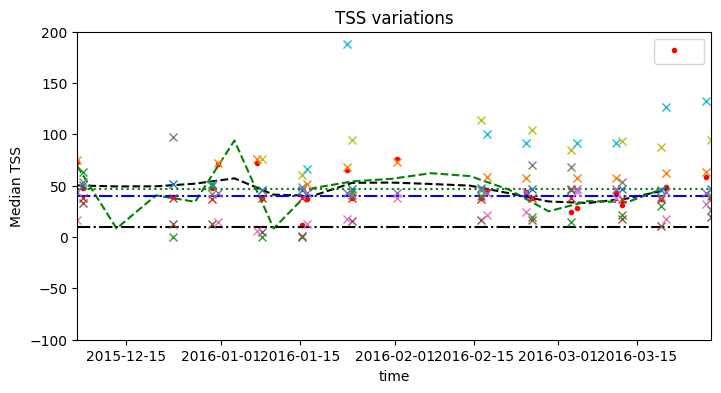

In [267]:
plt.figure(figsize=[18,4])
plt.subplot(1,2,1)
ds['lym'] = ds.where(ds.qa_score>0).tss.loc[{'tss_measure' : 'tsm_lym_oli'}]
ds['lym_delta'] = ds.lym - ds_annual.tss.loc[{'tss_measure' : 'tsm_lym_oli_agm'}]




tssdata        = ds.where(ds.qa_score>0).tss.median(dim=('tss_measure','x','y'))
tsslym         = ds.where(ds.qa_score>0).tss.loc[{'tss_measure' : 'tsm_lym_oli'}].median(dim=('x','y'))
tssdata        = ds.where(ds.qa_score>0).tss.median(dim=('tss_measure','x','y'))


t              = tssdata.time
t_new          = pd.date_range(t.time.min().values, t.max().values, freq='W')  
tss_interp     = sp.interpolate.interp1d(t,(piecewise_linreg(np.arange(0,t.size),tssdata)[0][1]),kind='quadratic',fill_value='extrapolate')
tss_intlym     = sp.interpolate.interp1d(t,(piecewise_linreg(np.arange(0,t.size),tsslym)[0][1]),kind='quadratic',fill_value='extrapolate')



plt.plot(t,tssdata,'r',linestyle="", marker=".",label='')  
plt.plot(t_new,smoothfunction(tssdata,1)(t_new),'k',linestyle="--", marker="",label='Smoothed NDVI')  
plt.plot(t_new,tss_interp(t_new),'g',linestyle="--", marker="",label='Smoothed NDVI')  
plt.plot(t_new,tss_intlym(t_new),'g',linestyle="--", marker="",label='Smoothed NDVI')  

plt.axhline(y=ds_annual.tss.median(),color='g',linestyle=':')
plt.axhline(y=ds_annual.tss.loc[{'tss_measure' : 'tsm_lym_oli_agm'}].median(),color='b',linestyle='-.')
plt.axhline(y=ds       .where(ds.qa_score>0).tss.loc[{'tss_measure' : 'tsm_lym_oli'    }].median(),color='k',linestyle='-.')

set_hue = ds.tss_measure
plt.plot(t,ds.tss.median(dim=('x','y')),linestyle='',marker='x')
#set_hue=wq_summary.tss_measure
#ax1.plot(wq_summary.time,wq_summary['tss']
#         .loc[placename,:],linestyle='dotted')
#ax1.plot(wq_summary.time,wq_summary['tss']
#         .loc[placename,:].
#         median(dim='tss_measure'),linestyle='solid')

plt.title('TSS variations')
                 
plt.xlabel('time')
plt.ylabel('Median TSS')
plt.legend([''])

# --- parameters for the range of the plot --- 
ymin  = -100;
ymax  = 200
xmin,xmax   = np.min(t),np.max(t)

plt.xlim(xmin,xmax)
plt.ylim(ymin,ymax)

In [ ]:
plt.figure(figsize=[18,4])
plt.subplot(1,2,1)

data = ts_ndvi
t    = ts_ndvi.time
plt.plot(ts_ndvi_tm.time,ts_ndvi_tm,'r',linestyle="", marker=".",label='Mean NDVI - TM')  
plt.plot(ts_ndvi_oli.time,ts_ndvi_oli,'g',linestyle="", marker=".",label='Mean NDVI')  
#plt.plot(ts_ndvi_msi.time,ts_ndvi_msi,'b',linestyle="", marker=".",label='Mean NDVI')  
#plt.plot(ts_ndvi.time,smoothfunction(ts_ndvi_tm)(ts_ndvi.time),'r',linestyle=":", marker="",label='Smoothed NDVI')  
#plt.plot(ts_ndvi.time,smoothfunction(ts_ndvi_oli)(ts_ndvi.time),'g',linestyle=":", marker="",label='Smoothed NDVI')  
#plt.plot(ts_ndvi.time,smoothfunction(ts_ndvi_msi,4)(ts_ndvi.time),'b',linestyle=":", marker="",label='Smoothed NDVI')  
plt.plot(ts_ndvi.time,smoothfunction(ts_ndvi,5)(ts_ndvi.time),'k',linestyle="--", marker="",label='Smoothed NDVI')  
#plt.plot(ts_ndvi.time,xy[1],'r',linestyle="--", marker="",label='Smoothed NDVI')  

plt.title('NDVI variations')
                 
plt.xlabel('time')
plt.ylabel('NDVI')
plt.legend(['TM','OLI','MSI'])

# --- parameters for the range of the plot --- 
ymin  = 0;
ymax  = 1
xmin,xmax   = np.min(t),np.max(t)

plt.xlim(xmin,xmax)
plt.ylim(ymin,ymax)

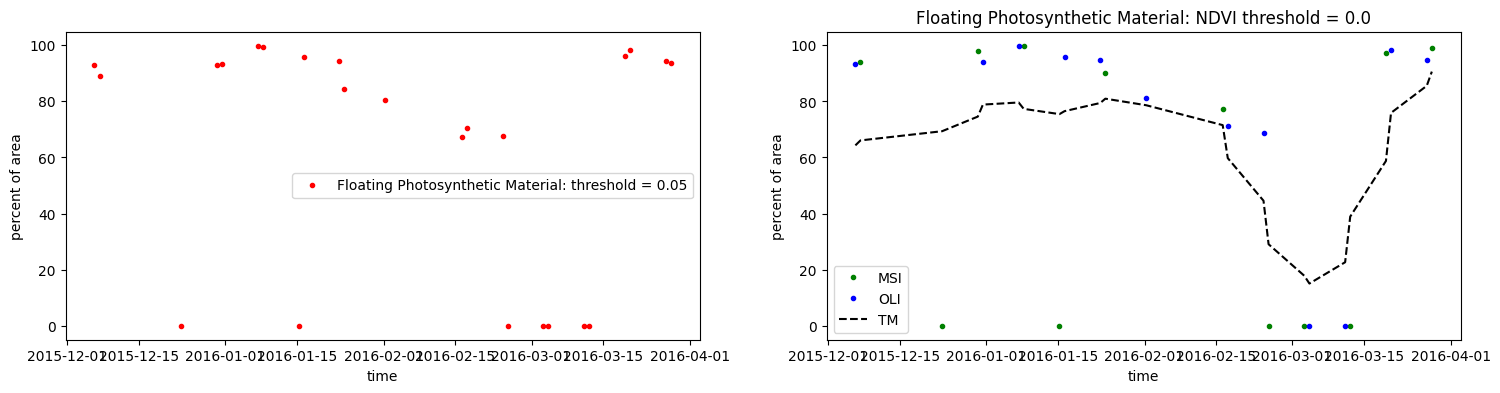

In [175]:
plt.figure(figsize=[18,4])
plt.subplot(1,2,1)

# --- extract the proporion of the area with ndvi > threshold, indicative of floating photosynthetic material, fpm ---
fpm_threshold = 0.05
ds['fpm_percent'] = 100 * ds.ndvi.where(ds.ndvi > fpm_threshold,np.nan).count(dim=('x','y')) / ds.ndvi_total_count

plt.plot(ds.where(~np.isnan(ds.fpm_percent)).time,ds.where(~np.isnan(ds.fpm_percent)).fpm_percent,
#plt.plot(ds.time,ds.ndvi_total_count,
        'r',
         linestyle="", 
         marker=".",
         label='count'
        )
plt.xlabel('time')
plt.ylabel('percent of area')
plt.legend(['Floating Photosynthetic Material: threshold = '+str(fpm_threshold)])

# --- extract the proporion of the area with ndvi > threshold, indicative of floating photosynthetic material, fpm ---
fpm_threshold = 0.0
ds['fpm_percent'] = 100 * ds.ndvi.where(ds.ndvi > fpm_threshold,np.nan).count(dim=('x','y')) / ds.ndvi_total_count

plt.subplot(1,2,2)
#plt.plot(ds.time,ds.fpm_percent              ,'k',linestyle="",marker=".",label='FPM percent')

if 'msi' in ds.data_vars:
    plt.plot(ds.time,ds.fpm_percent.where(ds.msi),'r',linestyle="",marker=".",label='FPM percent')
if 'oli' in ds.data_vars:
    plt.plot(ds.time,ds.fpm_percent.where(ds.oli),'g',linestyle="",marker=".",label='FPM percent')
if 'tm' in ds.data_vars:
    plt.plot(ds.time,ds.fpm_percent.where(ds.tm ),'b',linestyle="",marker=".",label='FPM percent')
plt.plot(ds.time,smoothfunction(ds.fpm_percent,5)(ds.time),'k',linestyle="--", marker="",label='Smoothed NDVI')  

plt.xlabel('time')
plt.ylabel('percent of area')

plt.title('Floating Photosynthetic Material: NDVI threshold = '+str(fpm_threshold))
plt.legend(['MSI','OLI','TM'])

#plt.plot(ts_ndvi_tm.time,ts_ndvi_tm,)  



plt.show()

In [149]:
# --- A Function to normalise the WQ measures ---

def normalise_water_quality_measures(ds0,np_data_dict,water_frequency_threshold=0,verbose=True,test=False):
    if test or verbose : print('Applying scale and offset to wq variables..')

    ds = ds0.copy(deep=True)   #without this the ds values do change outside of the function

    #run through all the wq measures; ds should have a dimension called 'tss_measure' and another called 'chla_measure'. 
    for mmt_type in ['tss','chla'] :
        for mmt in list(ds[mmt_type+'_measure']) :
            measurement = str(mmt.values)+'_agm'       # add the suffix - legacy of the annual geomedians used to develop the normalisation parameters
            scale  = np_data_dict[measurement]['scale']
            offset = np_data_dict[measurement]['offset']
            measurement = measurement[:measurement.find('_agm')] # removes the '_agm' suffix again!
            ds[mmt_type].loc[:,:,:,measurement] = ds[mmt_type].loc[:,:,:,measurement] * scale + offset
    
    #take the median of the tss and chla measurements from now on:
    water_frequency_threshold=0
    tss_index_list  = ds.tss_measure   # --- which tss measures to include; in practice this include them all  ----
    ds['tss_agm_med' ] = xr.where(ds.wofs_ann_pwater>water_frequency_threshold,
                                  ds.tss.loc[:,:,:,tss_index_list].median(dim=('tss_measure')),np.nan)

    chla_index_list = ds.chla_measure  # --- which chla measures to include; by default, include them all ----
    ds['chla_agm_med'] = xr.where(ds.wofs_ann_pwater>water_frequency_threshold,
                                  ds.chla.loc[:,:,:,chla_index_list].median(dim=('chla_measure')),np.nan)

    #drop excess material
    if not test:
        ds = ds.drop_vars('tss','chla')
    return ds

#### Exploring QA scores and parameters 
- I take 1.4 as a base, and use multiples of that; (2 for msi and oli, 3 for tm) 
- to bring back floating algal blooms, which will otherwise be removed, accept pixels that have an ndvi > 0.5 and ralb < 2.8
- test this on the lake victoria 'turbid' data area, for the first half of 2018
- Selection rule for ralb > -1.4 is needed with MSI to pull out cloud shadow

In [163]:
i = 0

In [164]:
#i = 15   #lake vic 2015-05-03

t = ds.time[i]
print(i)

# figure out if we are using an oli or a tm image;

oli_slice = [False,'qa_score','qa_ralb','qa_rsad','ci_score']
tm_slice  = [False,'qa_score','qa_ralb','qa_rsad','ci_score']
msi_slice = [False,'qa_score','qa_ralb','qa_rsad','ci_score']


oli_score_upper      = 1.4 * 2   # this seems best ...
msi_score_upper      = 1.4 * 2   # this seems best ...
tm_score_upper       = 1.4 * 3   # should need higher threshold for tm v oli ... not a nice step to take ..

upper_albedo = 2.0
upper_albedo = 3.0  # default filter cuts in a 2.8 so no point in going over that ... 
upper_albedo = 2.8  #lake vic 2018-04-27 benefits from relaxing to 2.8
lower_albedo = -1.4
lower_albedo = -2.
lower_albedo = -1.9 #this cuts out most cloud shadow, but can't go lower 
#lower_albedo = -1.8 starts to cut out real data in msi

upper_rsad   = 7
upper_rsad   = 6
upper_rsad   = 3
upper_rsad   = 4
upper_rsad   = 4.5
#upper_rsad   = 5 
rsad_factor = 0.4
ci_score_lower = 0
ci_cut     = 1   #one does not pick up key features


if t in list(ds_oli.time):
    oli_slice[0]        = True
    oli_timeindex       = list(ds_oli.time).index(t)
    prefix = 'qa'
    score_upper = oli_score_upper
    print('OLI')

else :
    if t in list(ds_tm.time):
        tm_slice[0]  = True
        tm_timeindex = list(ds_tm.time).index(t)
        prefix = 'qa'
        score_upper = tm_score_upper
        print('TM')
    else :
        if t in list (ds_msi.time):
            msi_slice[0]  = True
            msi_timeindex = list(ds_msi.time).index(t)
            prefix = 'qa'
            score_upper = msi_score_upper
            print('MSI')
            

# cumulative distribution stats:
start = 0;step=.05;stop=1+step

x    = np.arange(start,stop,step)
size = x.size
data = np.zeros([4,x.size])
data[0] = x
j = 0

for percent in x:
    k = 1
    string = 'Quantile = '+str(percent)+'  '
    for var in list(('ralb','rsad','score')):
        string = string + '  '+var+str(' : ')
        v      =  ds[prefix+'_'+var].sel(time=t).quantile(percent,).round(3).item()
        string = string+str(v)
        data[k,j] = v
        k = k + 1
    j = j+1
    print(string)


plt.figure(figsize=[12, 6])
plt.subplot(1,2,1)

plt.plot(data[1],data[0],'b',linestyle="--", marker=".",label='rsalb')  #ralb
plt.plot(data[2],data[0],'g',linestyle="-.", marker="X")  #rsad
plt.plot(data[3],data[0],'r',linestyle="-", marker="X")  #score
plt.axvline(x=0 ,linestyle=':',color='k')
plt.axvline(x=1.4 * 4,linestyle=':',color='r')
plt.axvline(x=1.4 * 3,linestyle=':',color='b')
plt.axvline(x=1.4 * 2,linestyle=':',color='g')

plt.title('distributions')
                 
plt.xlabel('value')
plt.ylabel('percentile')
plt.legend(['ralb','rsad','score'])

# --- parameters for the range of the plot --- 
ymin  = 0;
xmin   = np.max([np.min(data[1:,:]) * 1.5,-100])

xmax   = np.min([np.max(data[1:,:]) * 1.5,100])

plt.xlim(xmin,xmax)

plt.subplot(1,2,2)

i = i
print(i)
time = ds.time[i]
print(time.dt.year.item(),'-',time.dt.month.item(),'-',time.dt.day.item(),i,oli_slice[0],tm_slice[0])



#plt.figure(figsize=[12, 6])
if oli_slice[0]:
    print('plotting OLI points')
    plt.scatter(ds.sel(time=time).qa_rsad,ds.sel(time=time).qa_ralb,marker='.',color='c')
    plt.scatter(ds.where(ds.qa_score>0).sel(time=time).qa_rsad,
                ds.where(ds.qa_score>0).sel(time=time).qa_ralb,marker='.',color = 'b')
    plt.scatter(ds.where(ds.ci_score>ci_score_lower+upper_rsad*rsad_factor).sel(time=time).qa_rsad,
                ds.where(ds.ci_score>ci_score_lower+upper_rsad*rsad_factor).sel(time=time).qa_ralb,marker='.',color = 'r')
if tm_slice[0]: 
    print('plotting TM points')
    plt.scatter(ds.sel(time=time).qa_rsad,ds.sel(time=time).qa_ralb,marker='.',color = 'c')
    plt.scatter(ds.where(ds.qa_score>0).sel(time=time).qa_rsad,
                ds.where(ds.qa_score>0).sel(time=time).qa_ralb,marker='.',color = 'b')
    plt.scatter(ds.where(ds.ci_score>ci_score_lower+upper_rsad*rsad_factor).sel(time=time).qa_rsad,
                ds.where(ds.ci_score>ci_score_lower+upper_rsad*rsad_factor).sel(time=time).qa_ralb,marker='.',color = 'r')
if msi_slice[0]: 
    print('plotting MSI points')
    plt.scatter(ds.sel(time=time).qa_rsad,ds.sel(time=time).qa_ralb,marker='.',color = 'c')
    plt.scatter(ds.where(ds.qa_score>0).sel(time=time).qa_rsad,
                ds.where(ds.qa_score>0).sel(time=time).qa_ralb,marker='.',color = 'b')
    plt.scatter(ds.where(ds.ci_score>ci_score_lower+upper_rsad*rsad_factor).sel(time=time).qa_rsad,
                ds.where(ds.ci_score>ci_score_lower+upper_rsad*rsad_factor).sel(time=time).qa_ralb,marker='.',color = 'r')


plt.plot(0,0,marker='d',color='r')
t = np.linspace(0,2*np.pi,100)
r0 = 1.4 

x,y = np.cos(t)/rsad_factor,np.sin(t)
#plt.plot(x*1*r1,y*r0,linestyle='-.',color='g')
#plt.plot(x*2*r1,y*2*r0,linestyle='--',color='b')
#plt.plot(x*score_upper*r1,y*score_upper*r0,linestyle='--',color='r')
plt.plot(score_upper*x,score_upper*y,linestyle='dotted',color='r')
plt.plot(2*r0*x,2*r0*y,linestyle='dotted',color='g')
#plot the nominal change index = 0 curve
y = np.linspace(-5,5,30)
plt.plot(y**2,y,linestyle='dotted',color='k')

plt.axvline(x=0,color='r',linestyle=':')
plt.axvline(x=0+2*r0/rsad_factor,color='g',linestyle=':')
plt.axvline(x=upper_rsad,color='k',linestyle='-')
plt.axhline(y=0-2*r0,color='g',linestyle=':')
plt.axhline(y=0+2*r0,color='g',linestyle=':')
plt.axhline(y=lower_albedo,color='k',linestyle='-')
plt.axhline(y=upper_albedo,color='k',linestyle='-')

plt.xlim([0,40])
plt.ylim([-20,20])

plt.show()

print('original data')    

if oli_slice[0] == True :
    rgb(ds_oli,
        #    col='time',
        #    col_wrap = 4,
        bands=['oli04','oli03','oli02'],
        index =oli_timeindex,
        index_dim='time',
        #aspect = .8,
        #percentile_stretch = (.1,.65)
        robust = True
       )

if tm_slice[0] == True:
    rgb(ds_tm,
        #    col='time',
        #    col_wrap = 4,
        bands=['tm03','tm02','tm01'],
        index =tm_timeindex,
        index_dim='time',
        #aspect = .8,
        #percentile_stretch = (.1,.65)
        robust = True
       )
if msi_slice[0] == True:
    rgb(ds_msi,
        #    col='time',
        #    col_wrap = 4,
        bands=['msi04','msi03','msi02'],
        index =msi_timeindex,
        index_dim='time',
        #aspect = .8,
        #percentile_stretch = (.1,.65)
        robust = True
       )


if oli_slice[0]: 
    qa_var = oli_slice[1]
    qa_ralb = oli_slice[2]
    qa_rsad = oli_slice[3]
    qa_ci   = oli_slice[4]
    rgbbands=['oli04','oli03','oli01']
    ndvibands=['oli05','oli04']
    cutoff = score_upper
    
if tm_slice[0] : 
    qa_var = tm_slice[1]
    qa_ralb = tm_slice[2]
    qa_rsad = tm_slice[3]
    qa_ci   = tm_slice[4]
    rgbbands=['tm03','tm02','tm01']
    ndvibands=['tm04','tm03']
    cutoff = tm_score_upper

if msi_slice[0] : 
    qa_var = msi_slice[1]
    qa_ralb = msi_slice[2]
    qa_rsad = msi_slice[3]
    qa_ci   = msi_slice[4]
    rgbbands=['msi04','msi03','msi02']
    ndvibands=['msi8a','msi04']
    cutoff = msi_score_upper
    
print('QA var:  ',qa_var, rgbbands)


# --- just the qa variable ---
plt.show()
print('default filter')    

rgb(ds.where(ds[qa_var]>0,np.nan),
#rgb(ds.where(np.logical_and(np.logical_and(ds[qa_var]<cutoff,ds[qa_ralb]>lower_albedo),ds[qa_ralb]<upper_albedo),np.nan),
#rgb(ds.where(np.logical_and(np.logical_and(ds[qa_ralb]>lower_albedo,ds[qa_ralb]<upper_albedo),ds[qa_rsad]>upper_rsad),np.nan),
#rgb(ds.where(np.logical_and(np.logical_and(ds[qa_ci]>0,ds[qa_var]>cutoff),ds[qa_rsad]>0),np.nan),
#    col='time',
#    col_wrap = 4,
    bands=rgbbands,
    index =i,
    index_dim='time',
    robust=True,
    #aspect = .8,
    #percentile_stretch = (0.1,.99)
    )
plt.show()

# --- qa variable with additional overlays to fine-tune.. ---
print('default filter further constrained by albedo and spectral angle deviation ')    

rgb(ds.where(np.logical_and
             (
             np.logical_and(ds[qa_var]>0,ds[qa_rsad]<upper_rsad),
             np.logical_and(ds[qa_ralb]>lower_albedo,ds[qa_ralb]<upper_albedo)
             )
             ,np.nan),
#rgb(ds.where(np.logical_and(np.logical_and(ds[qa_ralb]>lower_albedo,ds[qa_ralb]<upper_albedo),ds[qa_rsad]>upper_rsad),np.nan),
#rgb(ds.where(np.logical_and(np.logical_and(ds[qa_ci]>0,ds[qa_var]>cutoff),ds[qa_rsad]>0),np.nan),
#    col='time',
#    col_wrap = 4,
    bands=rgbbands,
    index =i,
    index_dim='time',
    robust=True,
    #aspect = .8,
    #percentile_stretch = (0.1,.99)
    )

plt.show()

# --- no qa variable; additional overlays replace... ---

print('simple filter constrained independently by albedo and spectral angle deviation ')    

rgb(ds.where(np.logical_and
             (
             np.logical_and(True,ds[qa_rsad]<upper_rsad),
             np.logical_and(ds[qa_ralb]>lower_albedo,ds[qa_ralb]<upper_albedo)
             )
             ,np.nan),
#rgb(ds.where(np.logical_and(np.logical_and(ds[qa_ralb]>lower_albedo,ds[qa_ralb]<upper_albedo),ds[qa_rsad]>upper_rsad),np.nan),
#rgb(ds.where(np.logical_and(np.logical_and(ds[qa_ci]>0,ds[qa_var]>cutoff),ds[qa_rsad]>0),np.nan),
#    col='time',
#    col_wrap = 4,
    bands=rgbbands,
    index =i,
    index_dim='time',
    robust=True,
    #aspect = .8,
    #percentile_stretch = (0.1,.99)
    )

plt.show()
print('default further constrained by albedo')    

rgb(ds.where(np.logical_and
             (
                 np.logical_and(ds[qa_ralb]>lower_albedo,ds[qa_ralb]<upper_albedo),
                 ds[qa_var]>0
             )
             ,np.nan),
#rgb(ds.where(np.logical_and(np.logical_and(ds[qa_ralb]>lower_albedo,ds[qa_ralb]<upper_albedo),ds[qa_rsad]>upper_rsad),np.nan),
#rgb(ds.where(np.logical_and(np.logical_and(ds[qa_ci]>0,ds[qa_var]>cutoff),ds[qa_rsad]>0),np.nan),
#    col='time',
#    col_wrap = 4,
    bands=rgbbands,
    index =i,
    index_dim='time',
    robust=True,
    #aspect = .8,
    #percentile_stretch = (0.1,.99)
    )

plt.show()
print('default filter further constrained by rsad')    

rgb(ds.where(np.logical_and(ds[qa_rsad]<upper_rsad,ds[qa_var]>0),np.nan),
#rgb(ds.where(np.logical_and(np.logical_and(ds[qa_ralb]>lower_albedo,ds[qa_ralb]<upper_albedo),ds[qa_rsad]>upper_rsad),np.nan),
#rgb(ds.where(np.logical_and(np.logical_and(ds[qa_ci]>0,ds[qa_var]>cutoff),ds[qa_rsad]>0),np.nan),
#    col='time',
#    col_wrap = 4,
    bands=rgbbands,
    index =i,
    index_dim='time',
    robust=True,
    #aspect = .8,
    #percentile_stretch = (0.1,.99)
    )


plt.show()

print('change indicator; high rsad, low ralb')    
# --- change indicator ---
#rgb(ds.where(np.logical_and(ds[qa_var]<cutoff,ds[qa_ralb]>lower_albedo),np.nan),
#rgb(ds.where(np.logical_and(np.logical_and(ds[qa_ralb]>lower_albedo,ds[qa_ralb]<upper_albedo),ds[qa_rsad]>upper_rsad),np.nan),
ci_cut = 0
#ds['change_inidicated'] = ds.where(np.logical_and
#                               (
#                                np.logical_and(ds[qa_rsad]>upper_rsad,ds[qa_var]>cutoff),
#                                ds[qa_ralb]<upper_albedo
#                               ),
#                               np.nan)

rgb(ds.where(np.logical_and(
                            ds.ci_score>ci_score_lower+upper_rsad*rsad_factor,
                            ds[qa_var]<=0
                            ),np.nan),
#    col='time',
#    col_wrap = 4,
    bands=rgbbands,
    index =i,
    index_dim='time',
    robust=True,
    #aspect = .8,
    #percentile_stretch = (0.1,.99)
    )

plt.show()
print('ndvi')    

ndvi_threshold = 0.1
ndvi = (ds[ndvibands[0]]-ds[ndvibands[1]])/(ds[ndvibands[0]]+ds[ndvibands[1]])
xr.where(ndvi>ndvi_threshold,ndvi,np.nan).isel(time=i).plot(robust=True)

# --- photosynthetic surface material --- 
#ds['psm'] = ds.where(np.logical_and(ndvi > ndvi_threshold,ds['change_indicated'] == True),True,False)
                                    

i = i + 1
#i = 



0


AttributeError: 'str' object has no attribute 'time'